# Прогнозирование годовых медицинских расходов пациента на основе табличных данных

# Дополнительное исследование на расширенном датасете

В этом ноутбуке проводится дополнительный эксперимент на расширенном датасете с 100 000 пациентов.  
Цель — проверить, сохраняются ли выводы исходного исследования на более крупном и сложном наборе данных, а также оценить, дают ли ансамблевые методы выигрыш по сравнению с одиночными моделями.

Ссылка: https://www.kaggle.com/datasets/mohankrishnathalla/medical-insurance-cost-prediction/data

## 1. Подготовка данных

В этом эксперименте используется более полный набор доступных признаков нового датасета.  
В отличие от предыдущих версий исследования, здесь мы не ограничиваемся только признаками, пересекающимися с исходным синтетическим датасетом, и не исключаем policy- и claims-признаки.

Целевая переменная — `annual_medical_cost`.

Из моделирования исключаются только признаки с размером годовой и месячной премии (`annual_premium`, `monthly_premium`) как явные leakage-переменные и технический идентификатор `person_id`.

В модели используются все остальные группы признаков:

- демографические признаки;
- социально-экономические признаки;
- клинические показатели;
- хронические заболевания;
- поведенческие признаки;
- признаки медицинской нагрузки;
- признаки процедур;
- policy-признаки;
- claims-признаки.

## 2. Разведочный анализ данных

В EDA анализируются:

- распределения числовых признаков;
- выбросы и асимметрия;
- распределения бинарных и категориальных признаков;
- распределение целевой переменной;
- связи признаков с таргетом через `phi_k`, корреляции и визуализации.

## 3. Базовые модели

Данные делятся на train/test в пропорции 80/20.  
Test set откладывается до финального этапа и не используется для подбора моделей или весов ансамблей.

На train обучаются несколько моделей разных классов:

- `ElasticNet` как лучшая линейная модель;
- `RandomForestRegressor`;
- `ExtraTreesRegressor`;
- `HistGradientBoostingRegressor`;
- `CatBoostRegressor`.

Для линейных моделей используется отдельный preprocessing pipeline с масштабированием числовых признаков и one-hot encoding категориальных признаков.
Для деревянных моделей масштабирование не применяется.  
Для CatBoost категориальные признаки передаются в модель нативно.

## 4. Подбор гиперпараметров

Гиперпараметры подбираются только внутри train:

- для простых моделей используется GridSearchCV / RandomizedSearchCV;
- для бустингов используется Optuna;
- качество оценивается через 5-fold cross-validation.

Основная метрика — `MAE`, так как она показывает среднюю ошибку прогноза в денежных единицах. Дополнительно считаются `RMSE`, `R²` и `MAPE`.

## 5. Out-of-fold predictions

После подбора гиперпараметров для каждой базовой модели строятся out-of-fold предсказания на train.

OOF-предсказания используются для:

- честной оценки качества базовых моделей;
- выбора лучшей одиночной модели;
- расчёта весов ансамблей;
- обучения stacking meta-модели.

Это важно, потому что веса ансамблей не подбираются на test set.

## 6. Ансамблевые подходы

В ноутбуке проверяются несколько способов объединения моделей:

- **Simple Average Ensemble** — простое среднее прогнозов базовых моделей.
- **Inverse-Error Weighted Ensemble** — взвешенное среднее, где модели с меньшей OOF-ошибкой получают больший вес.
- **Strict pseudo-BMA** — байесовски-мотивированное усреднение, где равные априорные веса корректируются через OOF-качество моделей.
- **Tempered pseudo-BMA** — более мягкая версия pseudo-BMA, которая снижает риск "схлопывания" весов в одну модель.
- **Stacking Ridge** — stacking-ансамбль, где Ridge-модель учится комбинировать OOF-прогнозы базовых моделей.


Примечание. 

В этом проекте `pseudo-BMA` рассматривается как байесовски-мотивированное усреднение моделей, а не как строгий `Bayesian Model Averaging`. В строгом BMA нужно задавать вероятностную модель, априорные распределения (`prior`) для моделей и параметров, а затем оценивать предельное правдоподобие (`marginal likelihood`) каждой модели. Здесь используется более практичный подход: сначала всем моделям задаются равные начальные веса (`prior weights`), а затем эти веса корректируются на основе качества out-of-fold предсказаний (`OOF quality`).То есть OOF-ошибка используется как приближение того, насколько хорошо модель объясняет данные. Модели с меньшей ошибкой получают больший вес, модели с большей ошибкой — меньший. Поэтому подход сохраняет идею байесовского обновления доверия к моделям.

## 7. Финальная оценка на test

На финальном этапе тестовый набор используется впервые.

Сравниваются:

- все базовые модели;
- лучшая одиночная модель, выбранная по OOF;
- все ансамбли.

Для финальной оценки считаются:

- `MAE`;
- `RMSE`;
- `R²`;
- `MAPE`;
- bootstrap 95% confidence intervals;
- paired bootstrap-сравнение по MAE;
- Wilcoxon signed-rank test по абсолютным ошибкам.

## 8. Итоговая логика исследования

Главная цель ноутбука — не просто выбрать одну лучшую модель, а показать корректный процесс сравнения нескольких моделей и ансамблей:

1. модели обучаются на одинаковом наборе данных;
2. качество оценивается через кросс-валидацию и OOF-predictions;
3. ансамблевые веса рассчитываются только на трейне;
4. тест используется только для финальной независимой проверки;
5. статистические тесты помогают оценить устойчивость различий между моделями.

Такой подход позволяет учесть неопределённость выбора модели и проверить, дают ли ансамбли реальный выигрыш относительно лучшей одиночной модели.

## Характеристика датасета

**Размер датасета:**

- строк: **100 000**
- колонок: **54+**
- целевая переменная: **`annual_medical_cost`**

Датасет содержит более широкий набор признаков по сравнению с исходным синтетическим датасетом. В него входят:

- **Демография и социально-экономические признаки:** возраст, пол, регион, тип населённого пункта, доход, образование, семейный статус, занятость, размер домохозяйства.

- **Образ жизни:** BMI, курение, частота употребления алкоголя.

- **Здоровье и клинические показатели:** хронические заболевания, артериальное давление, лабораторные показатели, общий риск пациента.

- **Использование медицинских услуг:** визиты к врачу, госпитализации, длительность госпитализаций, количество медикаментов и медицинских процедур.

- **Страхование:** тип страхового плана, уровень сети, франшиза, copay, срок полиса и качество провайдера.

- **Медицинские расходы и claims:** годовая стоимость лечения, страховые премии, количество claims, средний размер claim и общая сумма оплаченных claims.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import phik
import joblib
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.model_selection import train_test_split, KFold, cross_validate, cross_val_score, GridSearchCV, ParameterGrid, RandomizedSearchCV, cross_val_predict
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score, make_scorer, mean_squared_error
from sklearn.compose import TransformedTargetRegressor
try:
    from sklearn.metrics import root_mean_squared_error
except ImportError:
    def root_mean_squared_error(y_true, y_pred):
        return mean_squared_error(y_true, y_pred, squared=False)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor, ExtraTreesRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, RidgeCV
from sklearn.inspection import permutation_importance
try:
    import optuna
    from optuna.samplers import TPESampler
    from optuna.pruners import MedianPruner
    OPTUNA_AVAILABLE = True
    optuna.logging.set_verbosity(optuna.logging.WARNING)
except ImportError:
    OPTUNA_AVAILABLE = False
    print('Optuna не установлена. Установите: pip install optuna')
try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False
    print('SHAP не установлен. Установите: pip install shap')
try:
    from catboost import CatBoostRegressor, Pool
    CATBOOST_AVAILABLE = True
except ImportError:
    CATBOOST_AVAILABLE = False
    print('CatBoost не установлен. Установите: pip install catboost')

Установим random state для воспроизводимости результатов.

In [2]:
RANDOM_STATE = 42

In [3]:
pd.set_option('display.max_columns', None)

# Exploratory Data Analysis (EDA) 

In [5]:
df = pd.read_csv('../data/raw/medical_insurance.csv')

df.head()

,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,dependents,bmi,smoker,alcohol_freq,visits_last_year,hospitalizations_last_3yrs,days_hospitalized_last_3yrs,medication_count,systolic_bp,diastolic_bp,ldl,hba1c,plan_type,network_tier,deductible,copay,policy_term_years,policy_changes_last_2yrs,provider_quality,risk_score,annual_medical_cost,annual_premium,monthly_premium,claims_count,avg_claim_amount,total_claims_paid,chronic_count,hypertension,diabetes,asthma,copd,cardiovascular_disease,cancer_history,kidney_disease,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
0,75722,52,Female,North,Suburban,22700.0,Doctorate,Married,Retired,3,1,27.4,Never,NaN,2,0,0,4,121.0,76.0,123.8,5.28,PPO,Bronze,1000,20,4,0,3.73,0.5714,6938.06,876.05,73.00,1,4672.59,4672.59,1,0,0,0,0,0,0,0,0,1,0,1,0,2,0,1,0,0
1,80185,79,Female,North,Urban,12800.0,No HS,Married,Employed,3,1,26.6,Never,Weekly,2,0,0,3,131.0,79.0,97.3,4.82,POS,Gold,1000,10,1,0,3.10,1.0000,1632.61,445.10,37.09,4,297.27,1189.08,2,0,0,0,0,0,0,0,0,1,1,0,0,1,0,1,1,0
2,19865,68,Male,North,Rural,40700.0,HS,Married,Retired,5,3,31.5,Never,NaN,1,0,0,4,160.0,84.0,129.5,5.51,HMO,Platinum,500,20,10,0,3.90,1.0000,7661.01,1538.02,128.17,0,0.00,0.00,3,1,0,0,0,0,1,0,0,0,1,1,0,2,1,0,1,0
3,76700,15,Male,North,Suburban,15600.0,Some College,Married,Self-employed,5,3,31.6,Never,NaN,0,0,0,1,104.0,68.0,160.3,8.50,HMO,Silver,500,20,5,0,3.89,0.2857,5130.27,820.63,68.39,0,0.00,0.00,1,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0
4,92992,53,Male,Central,Suburban,89600.0,Doctorate,Married,Self-employed,2,0,30.5,Never,Daily,3,0,0,2,136.0,83.0,171.0,5.20,POS,Platinum,500,10,7,0,3.90,0.8681,1700.73,500.93,41.74,1,1002.24,1002.24,2,1,0,0,0,0,0,0,0,1,0,2,0,1,1,0,1,0


## Базовая проверка качества данных

In [14]:
# определяем типы признаков
df.dtypes

person_id                        int64
age                              int64
sex                             object
region                          object
urban_rural                     object
income                         float64
education                       object
marital_status                  object
employment_status               object
household_size                   int64
dependents                       int64
bmi                            float64
smoker                          object
alcohol_freq                    object
visits_last_year                 int64
hospitalizations_last_3yrs       int64
days_hospitalized_last_3yrs      int64
medication_count                 int64
systolic_bp                    float64
diastolic_bp                   float64
ldl                            float64
hba1c                          float64
plan_type                       object
network_tier                    object
deductible                       int64
copay                    

In [15]:
n_rows, n_cols = df.shape

print(f'Размер датасета: {n_rows} строк, {n_cols} колонок')
print(f'Количество полных дублей: {df.duplicated().sum()}')
print(f'Количество дублей по person_id: {df['person_id'].duplicated().sum()}')

Размер датасета: 100000 строк, 54 колонок
Количество полных дублей: 0
Количество дублей по person_id: 0


Данные не содержат повторов. Дополнительная очистка от дубликатов не требуется.

In [16]:
data_quality = pd.DataFrame({
    'dtype': df.dtypes,
    'missing_count': df.isna().sum(),
    'missing_pct': (df.isna().mean() * 100).round(2),
    'zero_count': df.eq(0).sum(),
    'zero_pct': (df.eq(0).mean() * 100).round(2),
    'n_unique': df.nunique()
})

data_quality.sort_values(
    by=['missing_count', 'zero_count'],
    ascending=False
)

,dtype,missing_count,missing_pct,zero_count,zero_pct,n_unique
alcohol_freq,object,30083,30.08,0,0.00,3
kidney_disease,int64,0,0.00,98538,98.54,2
liver_disease,int64,0,0.00,98523,98.52,2
cancer_history,int64,0,0.00,97849,97.85,2
copd,int64,0,0.00,96405,96.40,2
policy_changes_last_2yrs,int64,0,0.00,95047,95.05,3
cardiovascular_disease,int64,0,0.00,94883,94.88,2
asthma,int64,0,0.00,94113,94.11,2
diabetes,int64,0,0.00,91407,91.41,2
hospitalizations_last_3yrs,int64,0,0.00,91031,91.03,4


- Пропуски есть только в признаке `alcohol_freq` — около 30% наблюдений. Для моделирования их можно обрабатывать как отдельную категорию `Missing`, так как отсутствие значения может само по себе нести информацию.

- Нулевые значения в большинстве признаков выглядят осмысленными: отсутствие заболеваний, госпитализаций, процедур, визитов, лекарств или иждивенцев.

- Многие бинарные медицинские признаки сильно несбалансированы: редкие заболевания вроде `kidney_disease`, `liver_disease`, `cancer_history`, `copd` встречаются у небольшой доли пациентов.

- Признаки медицинской нагрузки и процедур также имеют много нулей, что ожидаемо: большинство пациентов не проходили отдельные виды процедур и не имели госпитализаций.

- Явных проблем с пропусками или некорректными нулями не видно. Дополнительно нужно помнить, что `person_id` — технический идентификатор и не должен использоваться в моделировании.

Краткая статистика по числовым признакам:

In [17]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
person_id,100000.0,50000.50,28867.66,1.00,25000.75,50000.50,75000.25,100000.00
age,100000.0,47.52,15.99,0.00,37.00,48.00,58.00,100.00
income,100000.0,49873.90,46800.21,1100.00,21100.00,36200.00,62200.00,1061800.00
household_size,100000.0,2.43,1.08,1.00,2.00,2.00,3.00,9.00
dependents,100000.0,0.90,0.95,0.00,0.00,1.00,1.00,7.00
bmi,100000.0,26.99,4.99,12.00,23.60,27.00,30.40,50.40
visits_last_year,100000.0,1.93,1.74,0.00,1.00,2.00,3.00,25.00
hospitalizations_last_3yrs,100000.0,0.09,0.30,0.00,0.00,0.00,0.00,3.00
days_hospitalized_last_3yrs,100000.0,0.37,1.37,0.00,0.00,0.00,0.00,21.00
medication_count,100000.0,1.24,1.21,0.00,0.00,1.00,2.00,11.00


- Датасет содержит 100 000 наблюдений, пропусков в числовых признаках и целевой переменной не видно.

- `person_id` является техническим идентификатором и не должен использоваться как признак в моделировании, даже в версии `all-features`.

- Большинство числовых признаков имеют реалистичные диапазоны значений. Отдельно стоит помнить про `age = 0`: это может быть валидный возраст, но при необходимости его можно дополнительно проверить.

- `income` имеет выраженный правый хвост: медиана около 36 200, среднее около 49 874, максимум превышает 1 млн. Для линейных моделей такой признак стоит масштабировать или трансформировать.

- Признаки медицинской нагрузки (`visits_last_year`, `hospitalizations_last_3yrs`, `days_hospitalized_last_3yrs`, `medication_count`) имеют много нулей и правый хвост, что ожидаемо для медицинских данных.

- Клинические показатели (`systolic_bp`, `diastolic_bp`, `ldl`, `hba1c`, `bmi`) выглядят в целом реалистично, без очевидно некорректных экстремальных значений.

- Бинарные признаки заболеваний сильно несбалансированы: большинство хронических состояний встречается у небольшой доли пациентов.

- В этой версии датасета для анализа дополнительно используются policy-, premium- и claims-признаки: `deductible`, `copay`, `annual_premium`, `monthly_premium`, `claims_count`, `avg_claim_amount`, `total_claims_paid` и другие.

- Premium- и claims-признаки имеют сильную правостороннюю асимметрию.

- Целевая переменная `annual_medical_cost` также сильно скошена вправо: медиана около 2 083, среднее около 3 009, максимум около 65 725. Это говорит о наличии небольшой группы пациентов с очень высокими медицинскими расходами.

In [18]:
# Целевая переменная и технический идентификатор

target_col = 'annual_medical_cost'
id_col = 'person_id'


# Непрерывные числовые признаки

continuous_features = [
    'age',
    'income',
    'bmi',
    'systolic_bp',
    'diastolic_bp',
    'ldl',
    'hba1c',
    'risk_score',
    'provider_quality',
    'annual_premium',
    'monthly_premium',
    'avg_claim_amount',
    'total_claims_paid'
]


# Дискретные числовые признаки / счётчики

count_features = [
    'household_size',
    'dependents',
    'visits_last_year',
    'hospitalizations_last_3yrs',
    'days_hospitalized_last_3yrs',
    'medication_count',
    'deductible',
    'copay',
    'policy_term_years',
    'policy_changes_last_2yrs',
    'claims_count',
    'chronic_count',
    'proc_imaging_count',
    'proc_surgery_count',
    'proc_physio_count',
    'proc_consult_count',
    'proc_lab_count'
]


# Все числовые признаки для модели

numeric_features = continuous_features + count_features


# Бинарные признаки, уже закодированные как 0/1

binary_features = [
    'hypertension',
    'diabetes',
    'asthma',
    'copd',
    'cardiovascular_disease',
    'cancer_history',
    'kidney_disease',
    'liver_disease',
    'arthritis',
    'mental_health',
    'is_high_risk',
    'had_major_procedure'
]


# Номинальные категориальные признаки

categorical_features = [
    'sex',
    'region',
    'urban_rural',
    'education',
    'marital_status',
    'employment_status',
    'smoker',
    'alcohol_freq',
    'plan_type',
    'network_tier'
]


# Все признаки для модели
# В all-features версии используем полный набор признаков,
# исключая только технический id и сам target.

feature_cols = numeric_features + binary_features + categorical_features


# Признаки для анализа распределений

continuous_features_for_eda = continuous_features + [target_col]

cat_features_for_eda = binary_features + categorical_features


# Проверяем, что все нужные колонки есть в датафрейме

required_cols = feature_cols + [target_col]
missing_cols = [col for col in required_cols if col not in df.columns]

assert len(missing_cols) == 0, f'В df отсутствуют колонки: {missing_cols}'
assert id_col not in feature_cols, f'{id_col} не должен попадать в признаки'
assert target_col not in feature_cols, f'{target_col} не должен попадать в признаки'

print(f'Числовых признаков: {len(numeric_features)}')
print(f'Бинарных признаков: {len(binary_features)}')
print(f'Категориальных признаков: {len(categorical_features)}')
print(f'Всего признаков: {len(feature_cols)}')

Числовых признаков: 30
Бинарных признаков: 12
Категориальных признаков: 10
Всего признаков: 52


## 1. Визуализации числовых и категориальных переменных

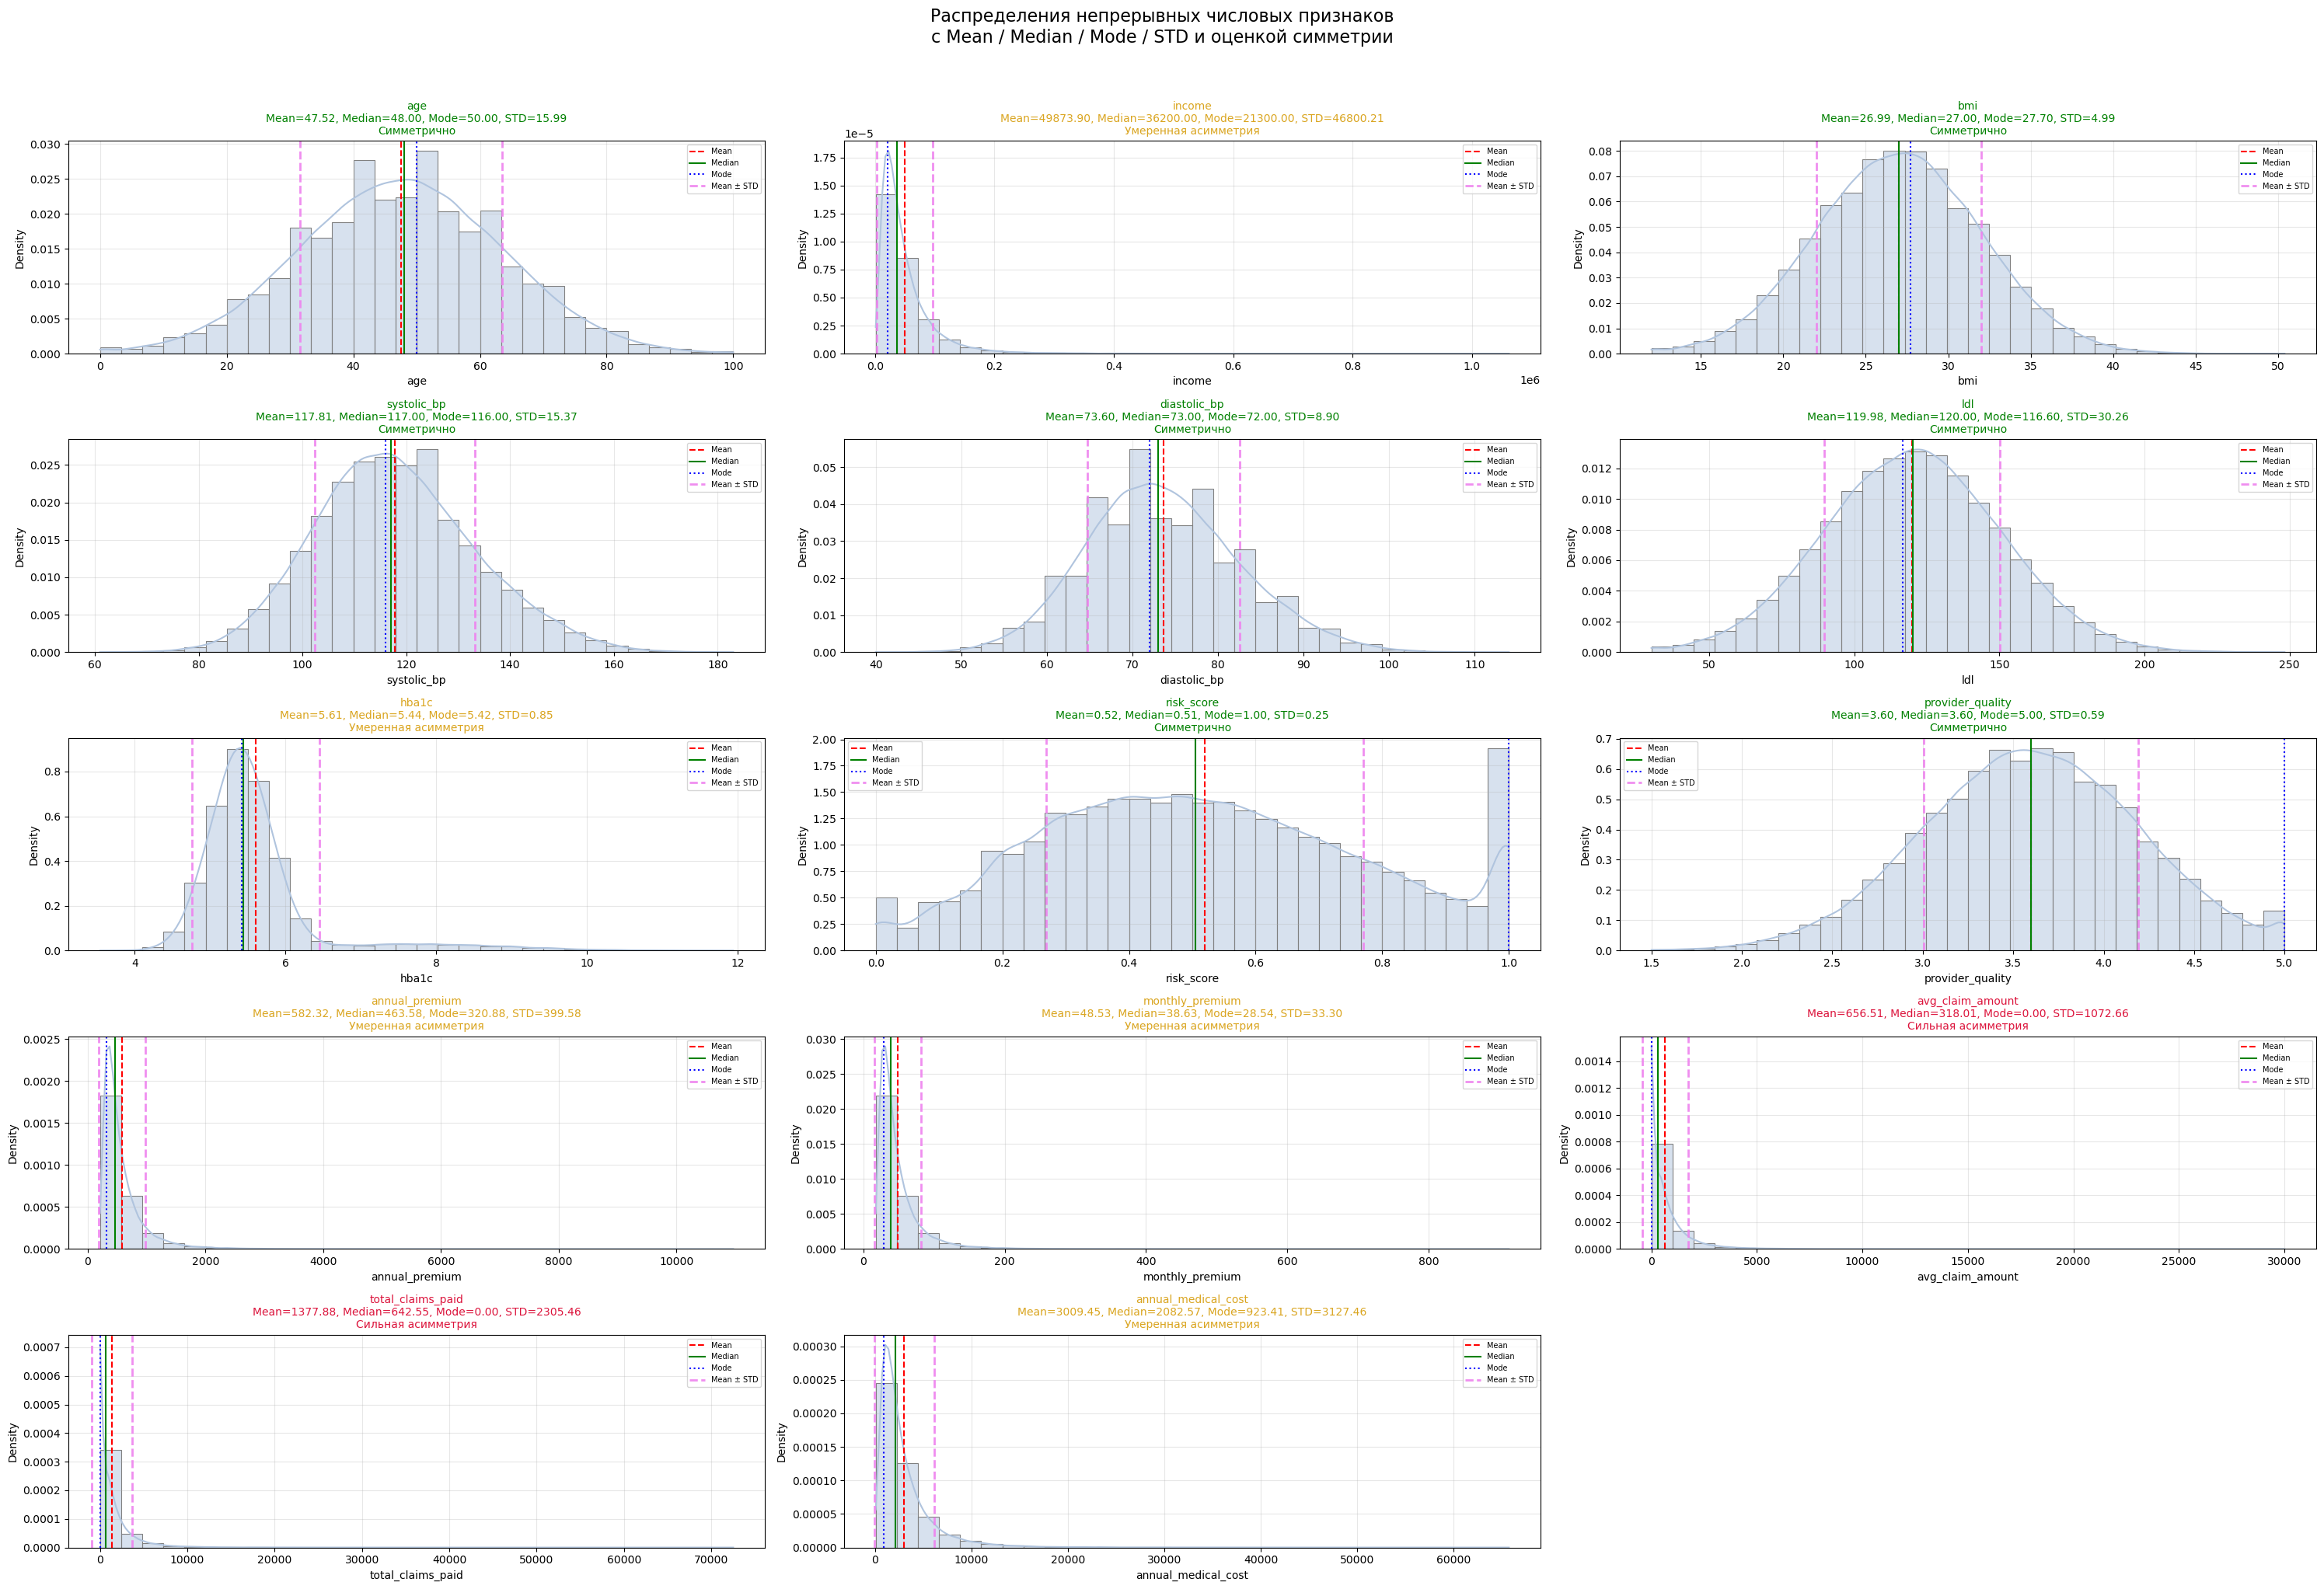

In [19]:
# Распределения непрерывных числовых признаков
# Смотрим форму распределения, среднее, медиану, моду и стандартное отклонение

plot_features = continuous_features_for_eda

n_cols = 3
n_rows = (len(plot_features) + n_cols - 1) // n_cols

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(10 * n_cols, 4 * n_rows)
)

axes = axes.flatten()

for i, col in enumerate(plot_features):
    data = df[col].dropna()

    mean_val = data.mean()
    median_val = data.median()
    mode_val = data.mode().iloc[0] if not data.mode().empty else np.nan
    std_val = data.std()

    # Простая оценка асимметрии через разницу среднего и медианы
    diff = abs(mean_val - median_val)
    skew_ratio = diff / std_val if std_val != 0 else 0

    if skew_ratio < 0.1:
        color = 'green'
        label = 'Симметрично'
    elif skew_ratio < 0.3:
        color = 'goldenrod'
        label = 'Умеренная асимметрия'
    else:
        color = 'crimson'
        label = 'Сильная асимметрия'

    sns.histplot(
        data,
        bins=30,
        kde=True,
        color='lightsteelblue',
        edgecolor='gray',
        linewidth=0.8,
        ax=axes[i],
        stat='density'
    )

    # Основные статистики на графике
    axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label='Mean')
    axes[i].axvline(median_val, color='green', linestyle='-', linewidth=1.5, label='Median')
    axes[i].axvline(mode_val, color='blue', linestyle=':', linewidth=1.5, label='Mode')

    # Интервал mean ± std
    axes[i].axvline(
        mean_val + std_val,
        color='violet',
        linestyle='--',
        linewidth=2,
        alpha=0.9,
        label='Mean ± STD'
    )
    axes[i].axvline(
        mean_val - std_val,
        color='violet',
        linestyle='--',
        linewidth=2,
        alpha=0.9
    )

    axes[i].set_title(
        (
            f'{col}\n'
            f'Mean={mean_val:.2f}, Median={median_val:.2f}, '
            f'Mode={mode_val:.2f}, STD={std_val:.2f}\n'
            f'{label}'
        ),
        fontsize=10,
        color=color
    )

    axes[i].grid(alpha=0.3)
    axes[i].legend(fontsize=7)

# Удаляем пустые оси, если количество графиков не кратно n_cols
for j in range(len(plot_features), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle(
    'Распределения непрерывных числовых признаков\n'
    'с Mean / Median / Mode / STD и оценкой симметрии',
    fontsize=16,
    y=1.02
)

plt.tight_layout(rect=[0, 0, 1, 1])
plt.show()

- Большинство базовых клинических признаков (`age`, `bmi`, `systolic_bp`, `diastolic_bp`, `ldl`) имеют достаточно реалистичные и близкие к симметричным распределения.

- `income` имеет выраженный правый хвост: у большинства пациентов доход находится в нижней и средней части диапазона, но есть редкие очень высокие значения.

- `hba1c` имеет умеренную правостороннюю асимметрию: основная масса значений находится около 5–6, но есть пациенты с заметно повышенными значениями.

- `risk_score` распределён широко по диапазону от 0 до 1 и выглядит потенциально информативным признаком для модели.

- `provider_quality` выглядит близким к симметричному распределению, основная масса значений находится примерно около 3–4.

- Premium- и claims-признаки (`annual_premium`, `monthly_premium`, `avg_claim_amount`, `total_claims_paid`) сильно скошены вправо: у большинства пациентов значения небольшие, но есть длинный хвост крупных сумм.

- Целевая переменная `annual_medical_cost` также сильно скошена вправо: большинство пациентов имеют относительно небольшие расходы, а небольшая группа формирует длинный хвост очень высоких затрат.

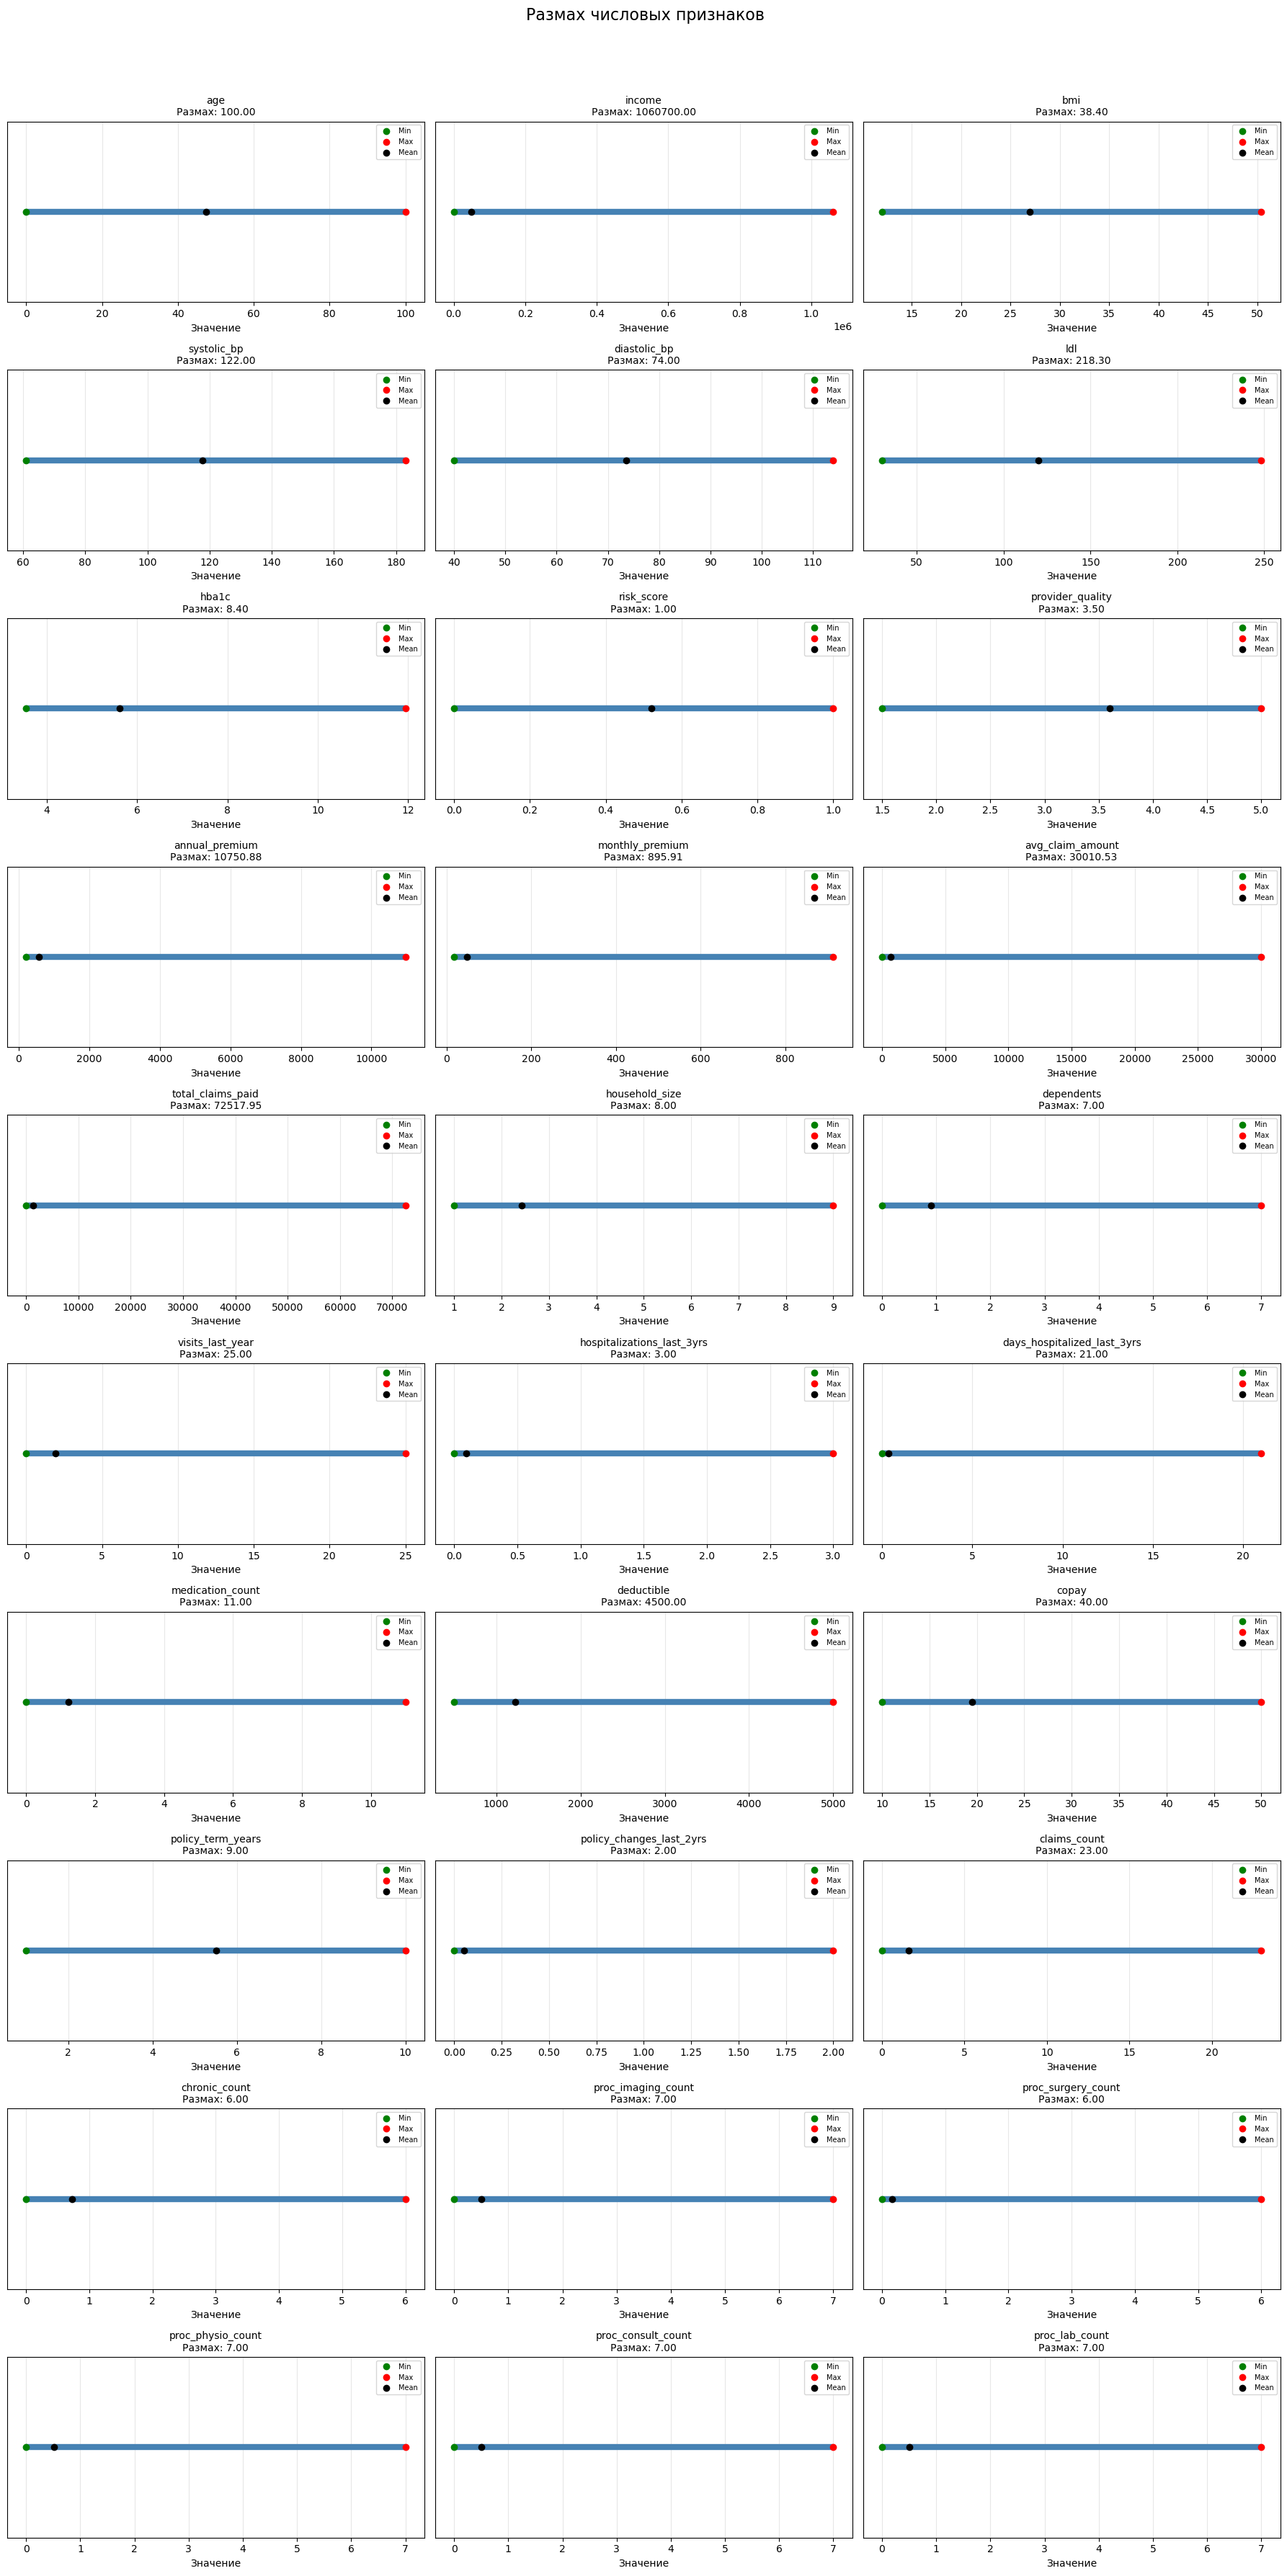

In [20]:
# Размах числовых признаков
# Смотрим минимальное, максимальное и среднее значение по каждому числовому признаку

plot_features = numeric_features

n_cols = 3
n_rows = (len(plot_features) + n_cols - 1) // n_cols

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(6 * n_cols, 3.5 * n_rows)
)

axes = np.array(axes).flatten()

for i, col in enumerate(plot_features):
    data = df[col].dropna()

    min_val = data.min()
    max_val = data.max()
    mean_val = data.mean()
    range_val = max_val - min_val

    # Линия от минимального до максимального значения
    axes[i].hlines(
        y=1,
        xmin=min_val,
        xmax=max_val,
        color='steelblue',
        linewidth=6
    )

    # Отмечаем min / max / mean
    axes[i].plot(min_val, 1, 'go', label='Min')
    axes[i].plot(max_val, 1, 'ro', label='Max')
    axes[i].plot(mean_val, 1, 'ko', label='Mean')

    axes[i].set_title(
        f'{col}\nРазмах: {range_val:.2f}',
        fontsize=10
    )

    axes[i].set_yticks([])
    axes[i].set_xlabel('Значение')
    axes[i].grid(axis='x', alpha=0.3)
    axes[i].legend(fontsize=7, loc='upper right')

# Удаляем пустые оси, если графиков меньше, чем ячеек сетки
for j in range(len(plot_features), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle(
    'Размах числовых признаков',
    fontsize=16,
    y=1.02
)

plt.tight_layout(rect=[0, 0, 1, 1])
plt.show()

- Диапазоны базовых клинических признаков (`age`, `bmi`, давление, `ldl`, `hba1c`) выглядят реалистично: явных некорректных экстремальных значений не видно.

- `income`, `annual_premium`, `monthly_premium`, `avg_claim_amount` и `total_claims_paid` имеют очень широкий размах: среднее значение находится близко к нижней части диапазона, а максимум сильно удалён вправо. Это подтверждает наличие длинных правых хвостов.

- Признаки медицинской нагрузки (`visits_last_year`, `hospitalizations_last_3yrs`, `days_hospitalized_last_3yrs`, `medication_count`) имеют низкие средние значения, но заметные максимумы. Это ожидаемо: большинство пациентов используют мало медицинских услуг, но есть редкие пациенты с высокой нагрузкой.

- Policy-признаки (`deductible`, `copay`, `policy_term_years`, `policy_changes_last_2yrs`) имеют ограниченные и понятные диапазоны значений.

- Процедурные признаки (`proc_*_count`) также имеют правый хвост: у большинства пациентов значения низкие, но есть пациенты с несколькими процедурами.

- В целом явных ошибок в числовых диапазонах не видно. Большие значения лучше не удалять автоматически, так как они могут отражать редкие, но важные случаи с высокими медицинскими расходами.

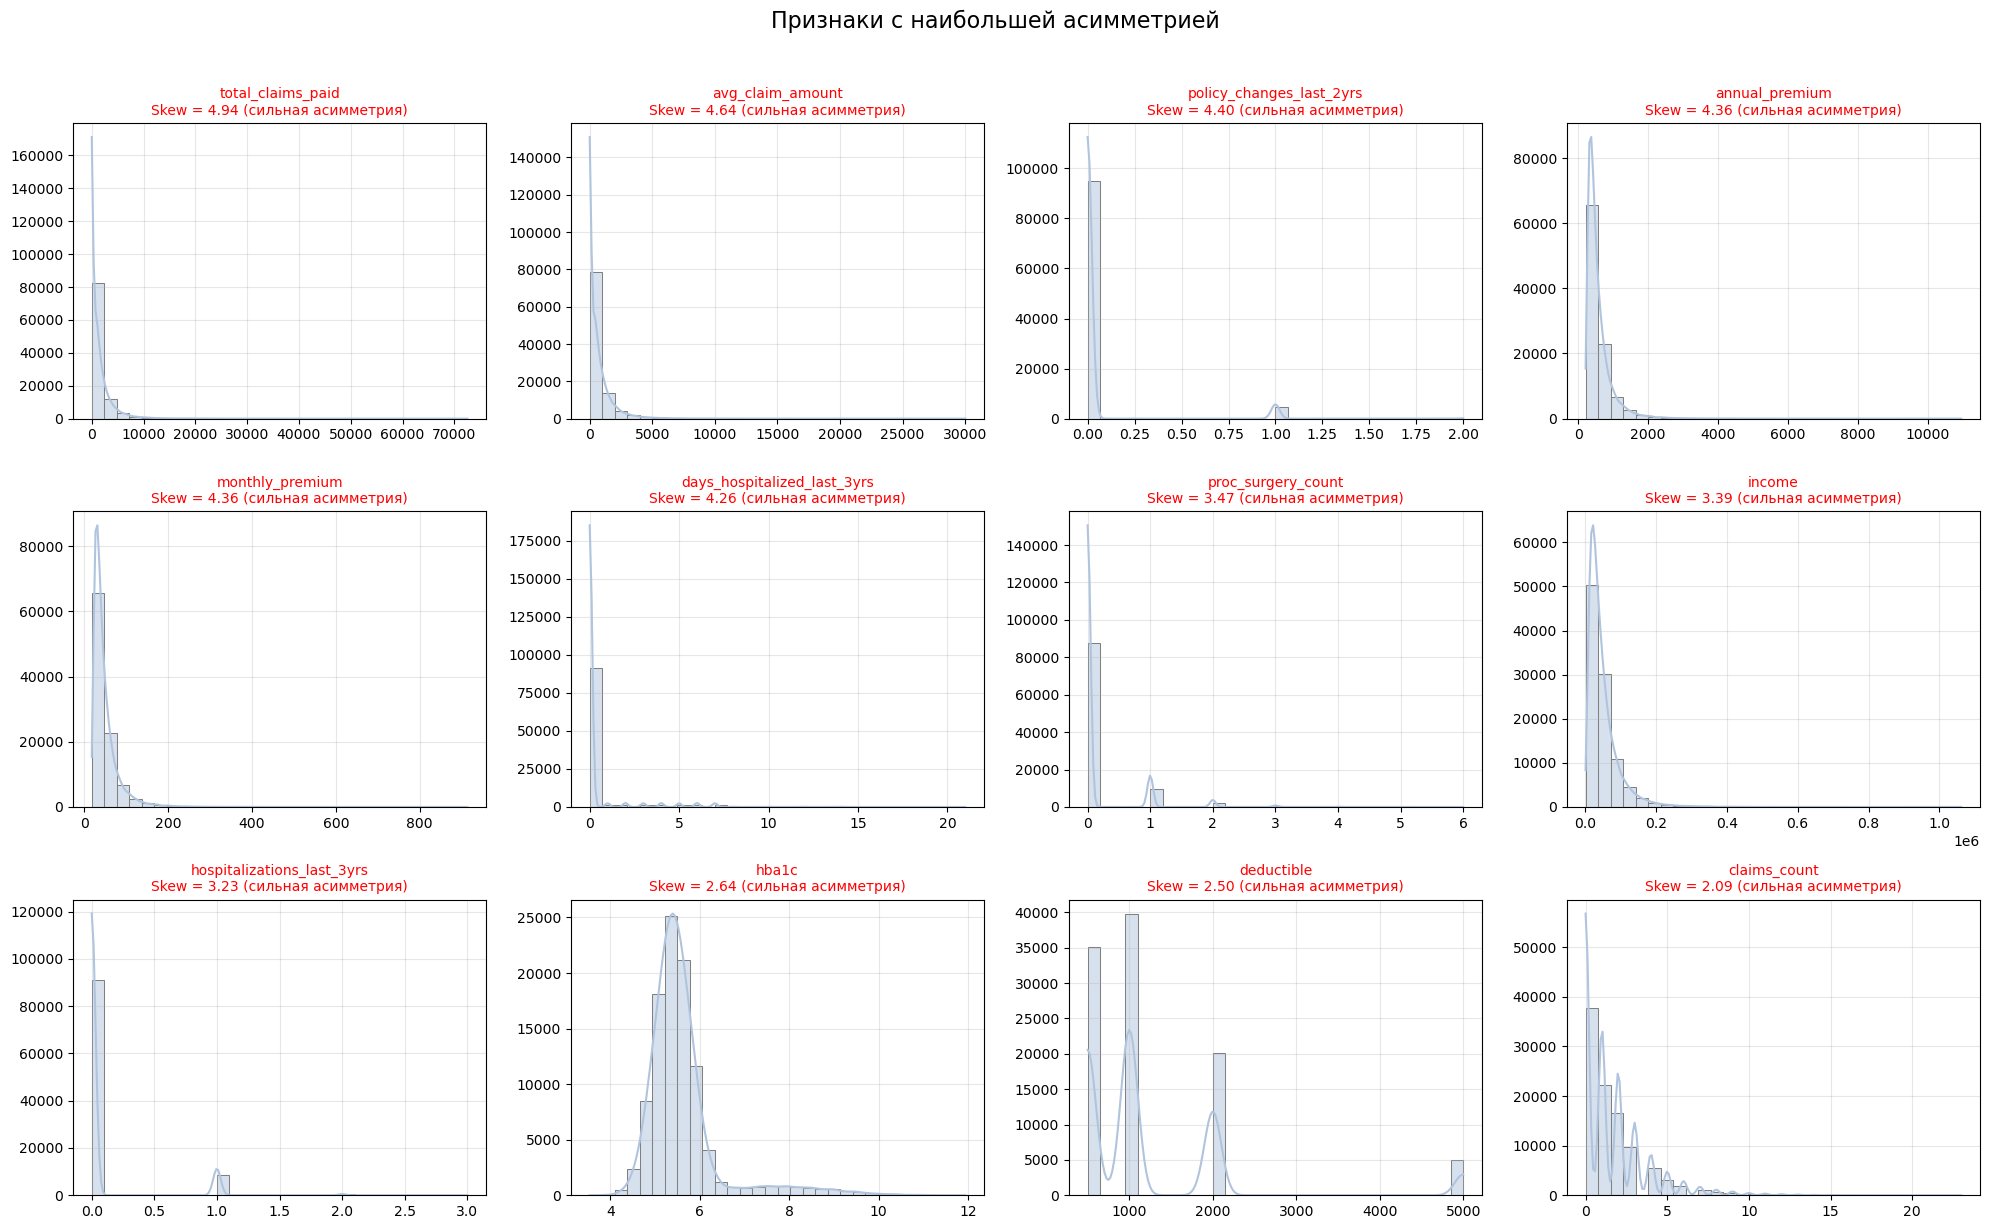

,skew
total_claims_paid,4.938
avg_claim_amount,4.642
policy_changes_last_2yrs,4.400
annual_premium,4.365
monthly_premium,4.365
days_hospitalized_last_3yrs,4.258
proc_surgery_count,3.473
income,3.390
hospitalizations_last_3yrs,3.225
hba1c,2.637


In [23]:
# Признаки с наибольшей асимметрией
# Ищем числовые признаки, распределение которых заметно отклоняется от симметричного

skew_threshold = 0.5
top_n = 12

# Сколько графиков максимум показывать в одном ряду
max_cols = 4

# Считаем коэффициент асимметрии по числовым признакам
skew_values = df[numeric_features].skew()

# Оставляем признаки с заметной асимметрией
skewed_features = skew_values[skew_values.abs() > skew_threshold]

# Сортируем по абсолютной величине асимметрии
skewed_features = skewed_features.reindex(
    skewed_features.abs().sort_values(ascending=False).index
)

# Берём несколько наиболее "проблемных" признаков для визуализации
plot_features = skewed_features.head(top_n).index.tolist()

if len(plot_features) == 0:
    print(f'Признаков с |skew| > {skew_threshold} не найдено.')
else:
    n_plots = len(plot_features)
    n_cols = min(max_cols, n_plots)
    n_rows = int(np.ceil(n_plots / n_cols))

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(5 * n_cols, 4 * n_rows)
    )

    axes = np.ravel(axes)

    for ax, col in zip(axes, plot_features):
        data = df[col].dropna()
        skew_val = data.skew()

        sns.histplot(
            data,
            bins=30,
            kde=True,
            ax=ax,
            color='lightsteelblue',
            edgecolor='gray'
        )

        # Оцениваем степень асимметрии
        if abs(skew_val) < 0.3:
            color = 'green'
            skew_label = 'симметричное'
        elif abs(skew_val) < 1:
            color = 'orange'
            skew_label = 'умеренная асимметрия'
        else:
            color = 'red'
            skew_label = 'сильная асимметрия'

        ax.set_title(
            f'{col}\nSkew = {skew_val:.2f} ({skew_label})',
            fontsize=10,
            color=color
        )
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax.grid(alpha=0.3)

    # Убираем пустые оси, если графиков меньше, чем ячеек в сетке
    for ax in axes[n_plots:]:
        ax.set_visible(False)

    fig.suptitle('Признаки с наибольшей асимметрией', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

# Таблица со значениями асимметрии
skewed_features.to_frame(name='skew').round(3)

- Наибольшая асимметрия наблюдается у claims- и premium-признаков: `total_claims_paid`, `avg_claim_amount`, `annual_premium`, `monthly_premium`, `claims_count`. Это ожидаемо: у многих пациентов выплаты и количество claims небольшие или нулевые, но есть длинный хвост дорогих случаев.

- `policy_changes_last_2yrs` имеет сильную асимметрию, потому что у большинства пациентов изменений полиса не было, а значения выше 0 встречаются редко.

- `days_hospitalized_last_3yrs`, `hospitalizations_last_3yrs` и `proc_surgery_count` также сильно скошены вправо: большинство пациентов не имели госпитализаций или хирургических процедур, но редкие случаи могут быть важны для прогноза расходов.

- `income` снова показывает выраженный правый хвост из-за небольшой группы пациентов с очень высоким доходом.

- `hba1c`, `deductible` и `claims_count` тоже попали в список асимметричных признаков, но их значения выглядят осмысленными и не требуют ручной корректировки.

- Для линейных моделей такие признаки стоит обрабатывать через `log1p`, а для деревьев и бустингов можно оставить в исходном масштабе.

In [24]:
# Разделяем числовые признаки по степени асимметрии
# Это пригодится дальше для preprocessing pipeline линейных моделей

skew_threshold = 0.5

skew_values = df[numeric_features].skew()

numeric_skewed = skew_values[
    skew_values.abs() > skew_threshold
].index.tolist()

numeric_standard = [
    col for col in numeric_features
    if col not in numeric_skewed
]

print(f'Признаки с заметной асимметрией: {numeric_skewed}')
print(f'Остальные числовые признаки: {numeric_standard}')

Признаки с заметной асимметрией: ['income', 'hba1c', 'annual_premium', 'monthly_premium', 'avg_claim_amount', 'total_claims_paid', 'household_size', 'dependents', 'visits_last_year', 'hospitalizations_last_3yrs', 'days_hospitalized_last_3yrs', 'medication_count', 'deductible', 'copay', 'policy_changes_last_2yrs', 'claims_count', 'chronic_count', 'proc_imaging_count', 'proc_surgery_count', 'proc_physio_count', 'proc_consult_count', 'proc_lab_count']
Остальные числовые признаки: ['age', 'bmi', 'systolic_bp', 'diastolic_bp', 'ldl', 'risk_score', 'provider_quality', 'policy_term_years']


In [25]:
# Поиск потенциальных выбросов по IQR-методу
# Метод считает границы нормального диапазона: [Q1 - 1.5 * IQR, Q3 + 1.5 * IQR]

def get_iqr_outlier_info(data, column):
    values = data[column].dropna()

    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outlier_mask = (values < lower_bound) | (values > upper_bound)
    outliers_count = outlier_mask.sum()

    return {
        'feature': column,
        'q1': q1,
        'q3': q3,
        'iqr': iqr,
        'lower_bound': lower_bound,
        'upper_bound': upper_bound,
        'outliers_count': outliers_count,
        'outliers_pct': outliers_count / len(values) * 100
    }


# Считаем информацию по всем числовым признакам
outliers_info = pd.DataFrame([
    get_iqr_outlier_info(df, col)
    for col in numeric_features
])

# Округляем числовые значения для более удобного отображения
outliers_info = outliers_info.round({
    'q1': 2,
    'q3': 2,
    'iqr': 2,
    'lower_bound': 2,
    'upper_bound': 2,
    'outliers_pct': 2
})

# Сортируем по доле потенциальных выбросов
outliers_info = outliers_info.sort_values(
    by='outliers_pct',
    ascending=False
)

outliers_info

,feature,q1,q3,iqr,lower_bound,upper_bound,outliers_count,outliers_pct
26,proc_surgery_count,0.00,0.00,0.00,0.00,0.00,12519,12.52
16,hospitalizations_last_3yrs,0.00,0.00,0.00,0.00,0.00,8969,8.97
17,days_hospitalized_last_3yrs,0.00,0.00,0.00,0.00,0.00,8969,8.97
6,hba1c,5.16,5.76,0.60,4.26,6.66,7465,7.46
12,total_claims_paid,0.00,1795.52,1795.52,-2693.28,4488.81,6963,6.96
9,annual_premium,352.07,666.70,314.63,-119.87,1138.64,6927,6.93
10,monthly_premium,29.34,55.56,26.22,-9.99,94.89,6925,6.93
11,avg_claim_amount,0.00,872.22,872.22,-1308.32,2180.54,6581,6.58
14,dependents,0.00,1.00,1.00,-1.50,2.50,6306,6.31
1,income,21100.00,62200.00,41100.00,-40550.00,123850.00,6236,6.24


- По IQR-методу больше всего “выбросов” найдено в признаках с большим количеством нулей: `proc_surgery_count`, `hospitalizations_last_3yrs`, `days_hospitalized_last_3yrs`, `policy_changes_last_2yrs`. Это не ошибки данных, а редкие события: хирургические процедуры, госпитализации и изменения полиса встречаются не у всех пациентов.

- Claims- и premium-признаки (`total_claims_paid`, `avg_claim_amount`, `claims_count`, `annual_premium`, `monthly_premium`) также имеют заметную долю выбросов. Это ожидаемо: большинство пациентов имеют небольшие выплаты и premiums, но есть небольшая группа дорогих случаев.

- `income` снова показывает правый хвост с высокими значениями. Такие значения лучше не удалять автоматически, а учитывать через трансформацию `log1p` в линейных моделях.

- `hba1c`, `bmi`, `systolic_bp`, `diastolic_bp`, `ldl` имеют выбросы по IQR, но диапазоны выглядят медицински возможными. Автоматически исправлять или удалять их не нужно.

- `deductible` попал в выбросы из-за дискретной структуры значений страхового плана, а не из-за ошибки. Значения выглядят осмысленными.

- В целом ручная обработка выбросов не требуется. Большинство экстремальных значений отражает редкие, но важные случаи, которые могут быть полезны для прогноза медицинских расходов.

- Для линейных моделей асимметричные признаки будут обработаны через `log1p`, а для деревьев и бустингов значения можно оставить в исходном масштабе.

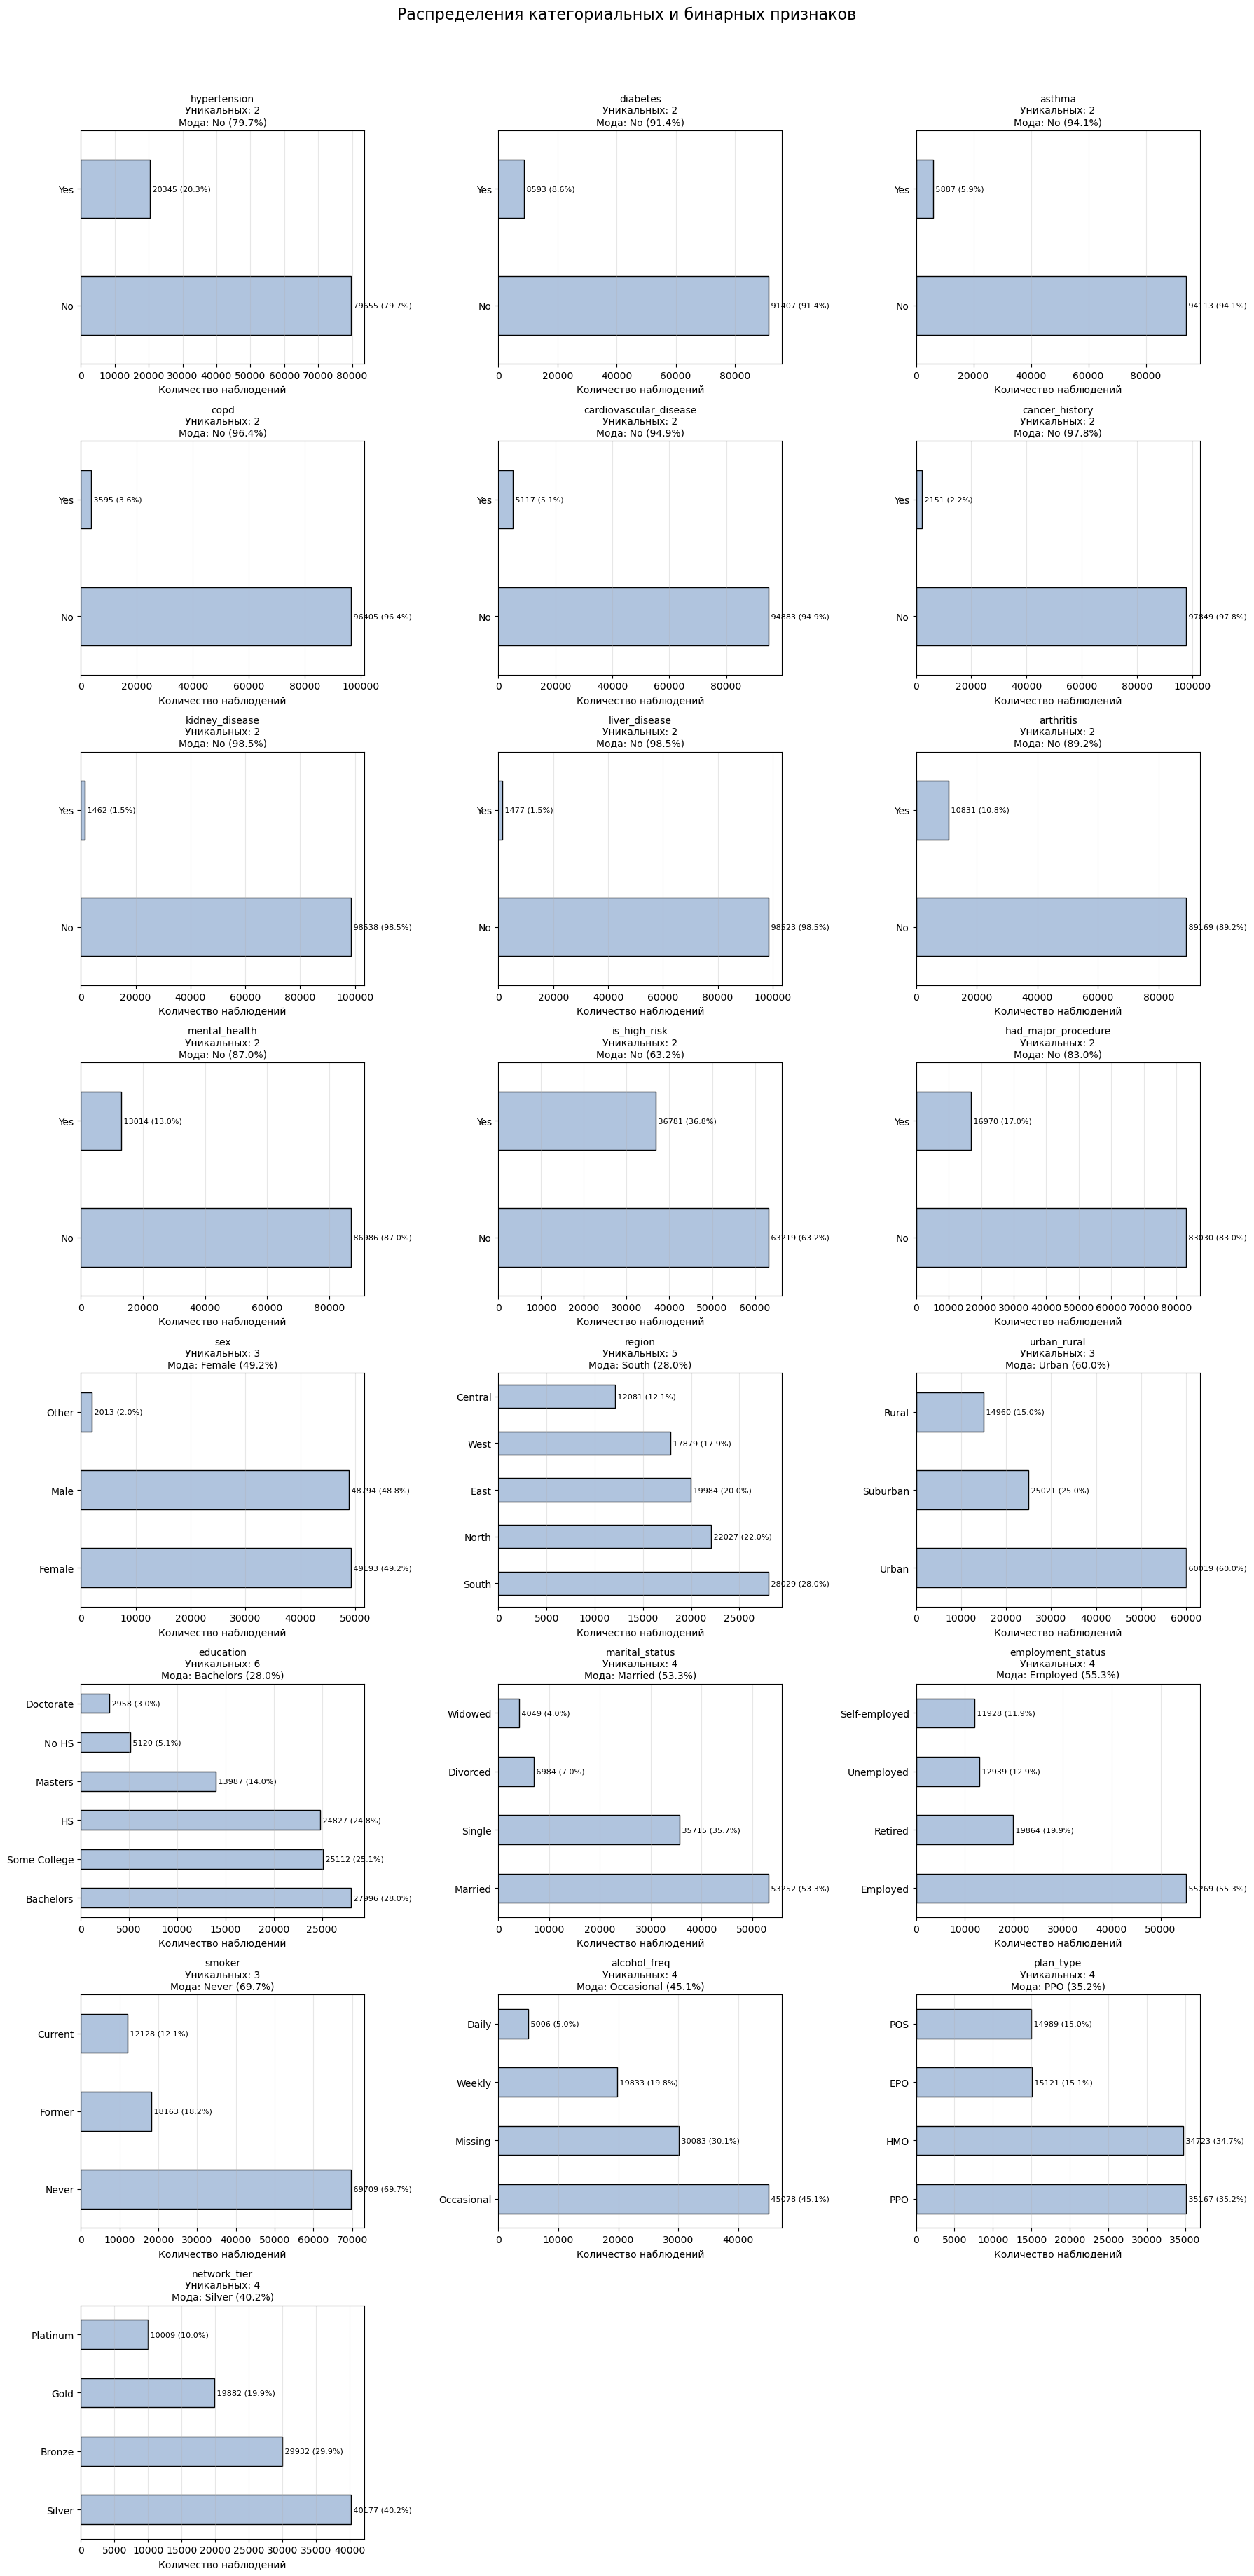

In [27]:
# Распределения категориальных и бинарных признаков
# Смотрим баланс категорий и долю самой частой категории

plot_features = cat_features_for_eda

# Читаемые подписи для бинарных признаков
binary_value_labels = {
    col: {0: 'No', 1: 'Yes'}
    for col in binary_features
}

n_cols = 3
n_rows = (len(plot_features) + n_cols - 1) // n_cols

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(6 * n_cols, 4.5 * n_rows)
)

axes = np.array(axes).flatten()

for i, col in enumerate(plot_features):
    # Для бинарных признаков заменяем 0/1 на понятные подписи
    if col in binary_value_labels:
        plot_data = df[col].map(binary_value_labels[col])
    else:
        plot_data = df[col]

    # Учитываем пропуски как отдельную категорию, если они есть
    plot_data = plot_data.fillna('Missing')

    counts = plot_data.value_counts()
    percents = counts / len(df) * 100

    counts.plot(
        kind='barh',
        color='lightsteelblue',
        edgecolor='black',
        ax=axes[i]
    )

    mode_val = counts.index[0]
    mode_percent = percents.iloc[0]

    axes[i].set_title(
        f'{col}\n'
        f'Уникальных: {plot_data.nunique()}\n'
        f'Мода: {mode_val} ({mode_percent:.1f}%)',
        fontsize=10
    )

    axes[i].set_xlabel('Количество наблюдений')
    axes[i].set_ylabel('')
    axes[i].grid(axis='x', alpha=0.3)

    # Подписываем значения на барах
    for j, value in enumerate(counts):
        axes[i].text(
            value,
            j,
            f' {value} ({percents.iloc[j]:.1f}%)',
            va='center',
            fontsize=8
        )

# Удаляем пустые оси
for j in range(len(plot_features), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle(
    'Распределения категориальных и бинарных признаков',
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()

- Бинарные медицинские признаки заметно несбалансированы: большинство хронических заболеваний и состояний встречается у небольшой доли пациентов.

- Наиболее частые положительные медицинские флаги: `is_high_risk`, `hypertension`, `had_major_procedure`, `mental_health` и `arthritis`.

- Редкие заболевания (`kidney_disease`, `liver_disease`, `cancer_history`, `copd`) представлены малой долей пациентов, но их стоит оставлять: такие признаки могут быть важны для дорогих медицинских случаев.

- `sex` почти сбалансирован между `Female` и `Male`, категория `Other` составляет около 2% и корректно учитывается отдельно.

- `region` распределён достаточно равномерно, без экстремального перекоса в одну категорию.

- В `urban_rural` преобладает категория `Urban`, затем идут `Suburban` и `Rural`.

- По социально-экономическим признакам видно, что чаще встречаются пациенты с `Bachelors`, `Some College` и `HS`; по семейному статусу преобладает `Married`, по занятости — `Employed`.

- `smoker` распределён ожидаемо: большинство пациентов — `Never`, далее `Former`, затем `Current`.

- У `alcohol_freq` значимая доля `Missing`, поэтому пропуски лучше кодировать как отдельную категорию, а не удалять строки.

- В all-features версии дополнительно появились policy-признаки: `plan_type` и `network_tier`.

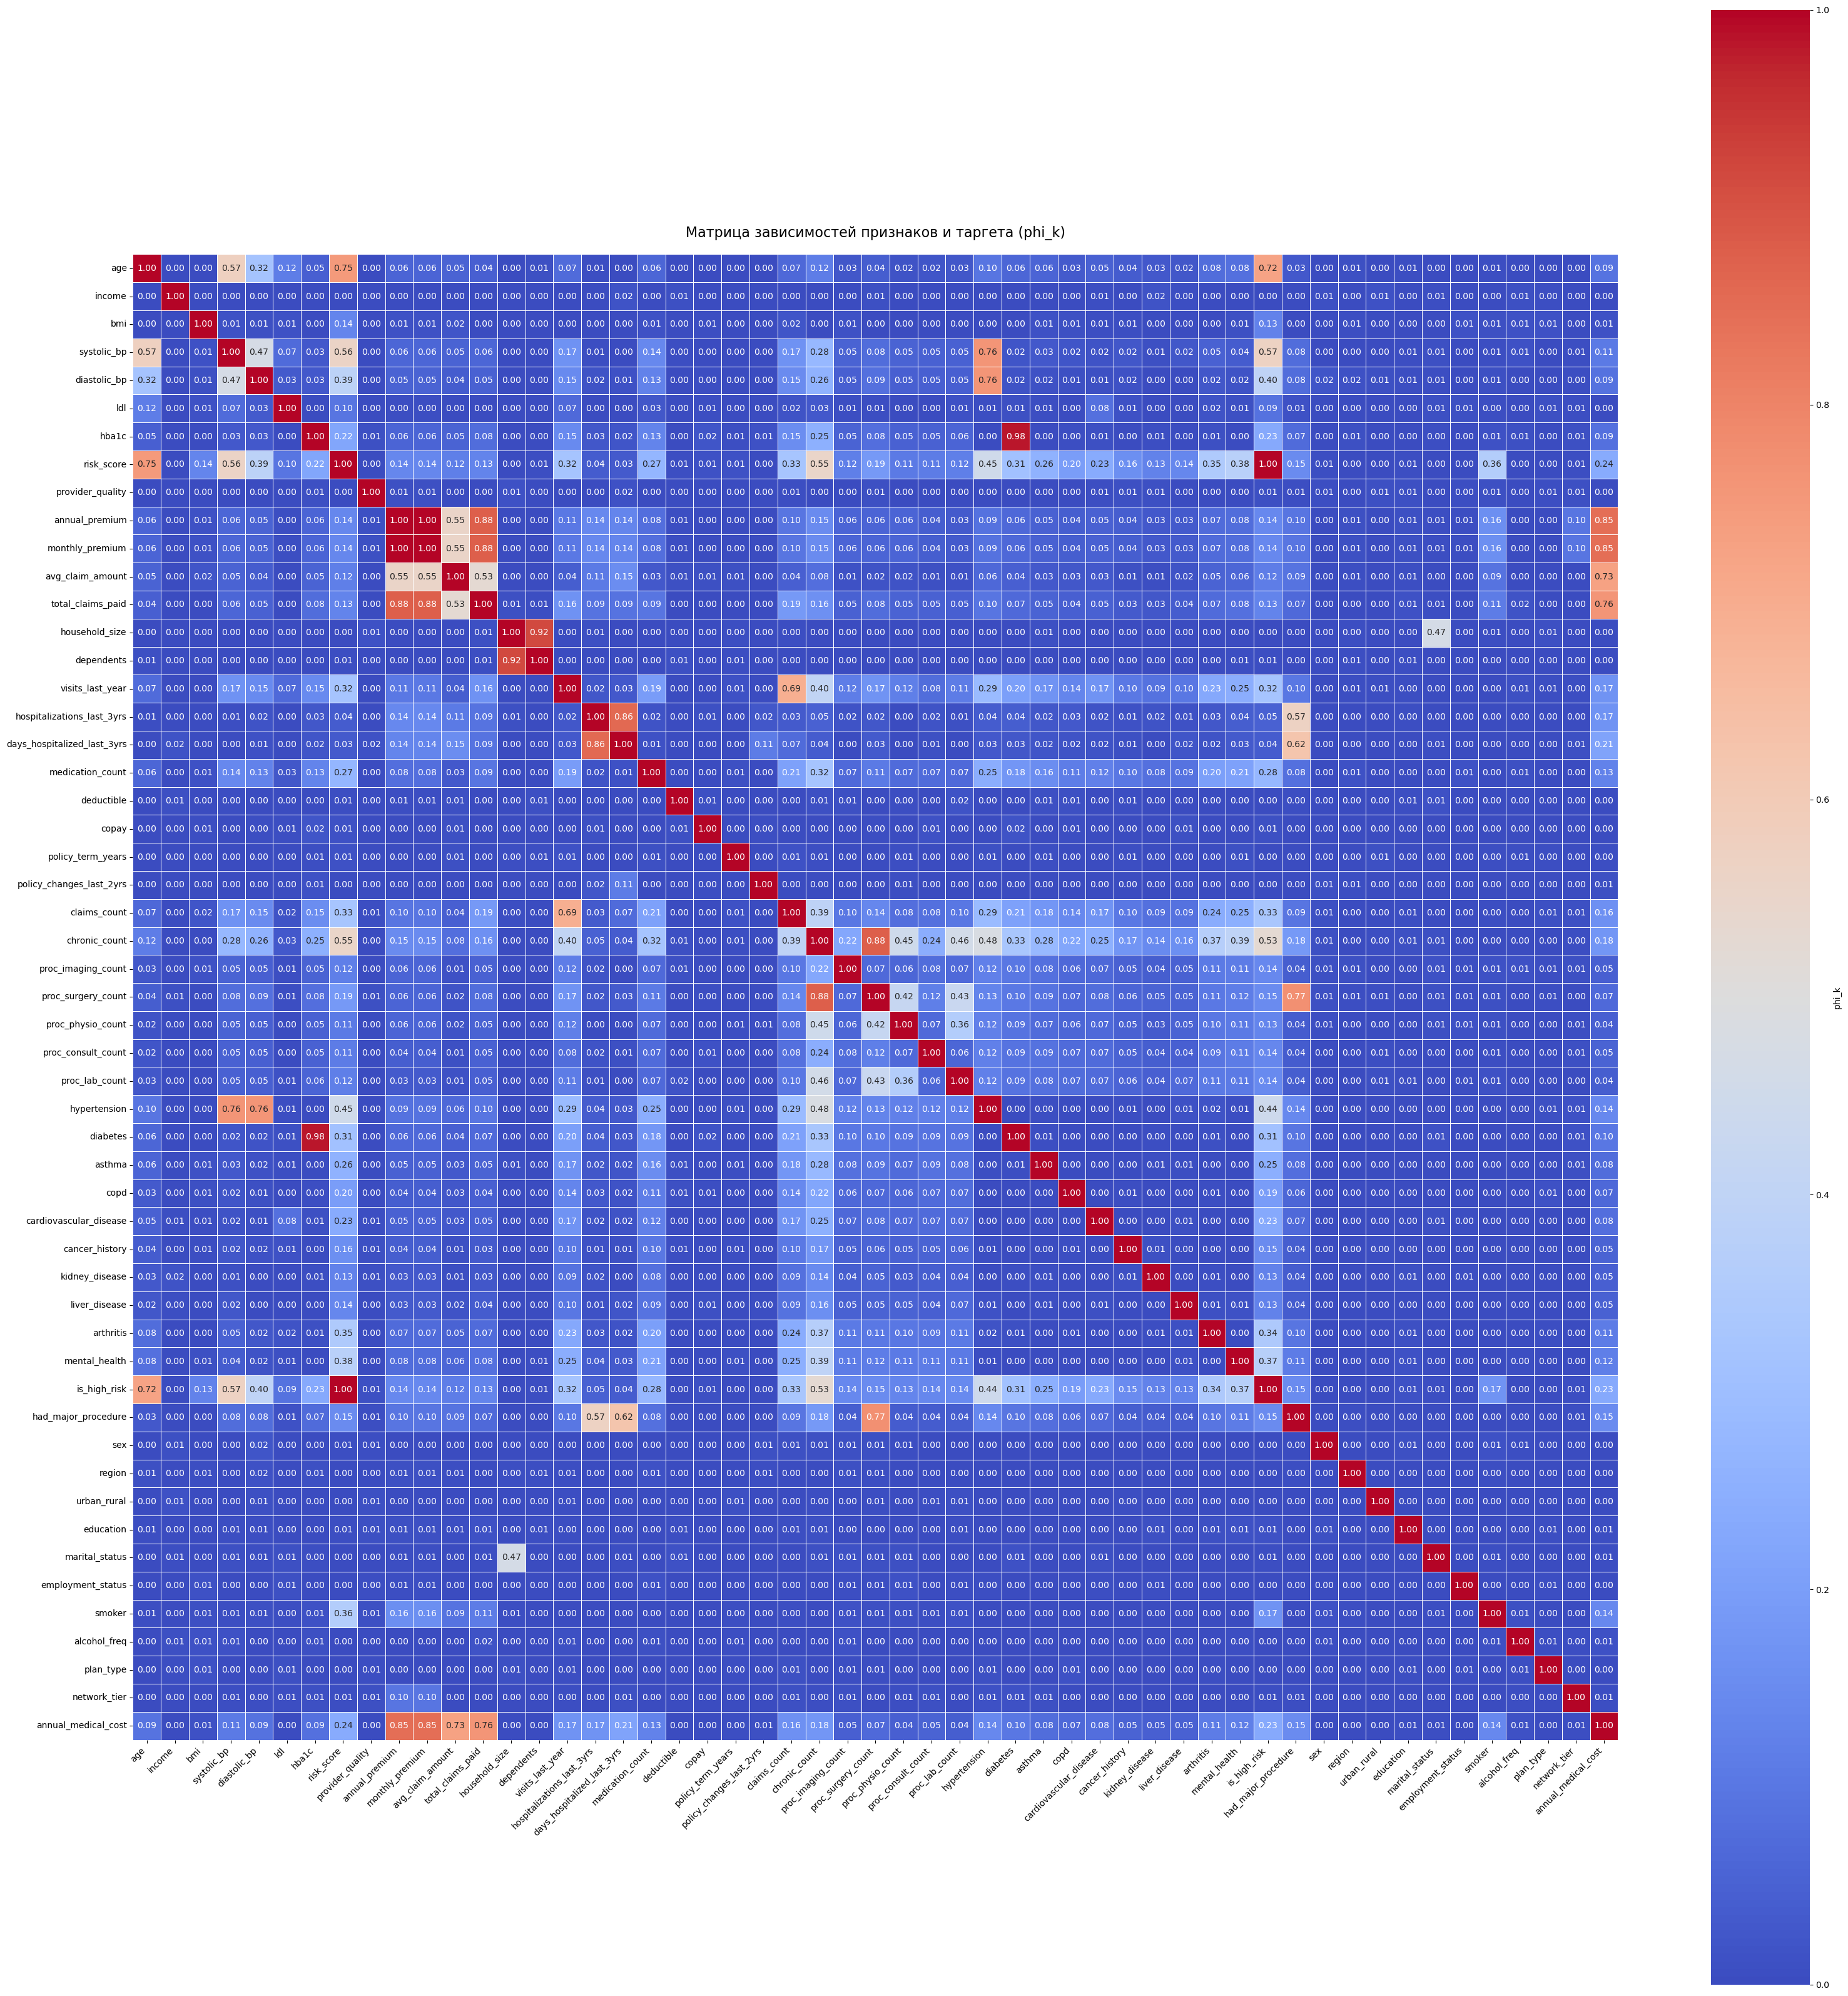

In [29]:
# Матрица зависимостей phi_k
# Позволяет оценивать связи между числовыми, бинарными и категориальными признаками,
# включая нелинейные зависимости

phik_features = feature_cols + [target_col]

phik_data = df[phik_features].copy()

# Бинарные признаки явно приводим к category,
# чтобы phi_k не интерпретировал их как непрерывные числовые признаки
for col in binary_features + categorical_features:
    phik_data[col] = phik_data[col].astype('category')

# Интервальными считаем только настоящие числовые признаки и таргет
interval_cols = numeric_features + [target_col]

phik_matrix = phik_data.phik_matrix(interval_cols=interval_cols)

plt.figure(figsize=(32, 32))

sns.heatmap(
    phik_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=0,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={'label': 'phi_k'}
)

plt.title('Матрица зависимостей признаков и таргета (phi_k)', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

- В all-features версии связи с таргетом стали намного сильнее за счёт premium- и claims-признаков.

- Наиболее сильную связь с `annual_medical_cost` показывают признаки, напрямую связанные со страховыми выплатами и стоимостью:
  - `annual_premium`;
  - `monthly_premium`;
  - `total_claims_paid`;
  - `avg_claim_amount`.

- Между некоторыми признаками есть почти полное дублирование. Например, `annual_premium` и `monthly_premium` практически повторяют друг друга, так как месячная премия является производной от годовой.

- Также сохраняются сильные связи из предыдущего эксперимента: `is_high_risk` сильно связан с `risk_score`, а `diabetes` — с `hba1c`. Если хотим уменьшить мультиколлинеарность и упростить интерпретацию, можно оставить `risk_score` и `hba1c`, а `is_high_risk` и `diabetes` исключить.

- `hospitalizations_last_3yrs` и `days_hospitalized_last_3yrs` также сильно связаны между собой, но это не полные дубликаты: первый признак отражает количество госпитализаций, второй — длительность пребывания. Их можно оставить.

- Для деревянных моделей и бустингов высокая корреляция признаков не является критичной: такие модели обычно нормально работают с избыточными признаками.

- Для линейных моделей мультиколлинеарность может усложнять интерпретацию коэффициентов, поэтому регуляризация Ridge / ElasticNet особенно важна.

- В целом матрица подтверждает, что полный набор признаков содержит очень сильные предикторы таргета. Однако premium-признаки будут исключены из ML-моделирования как потенциальные leakage-признаки.

## 2. Анализ целевой переменной

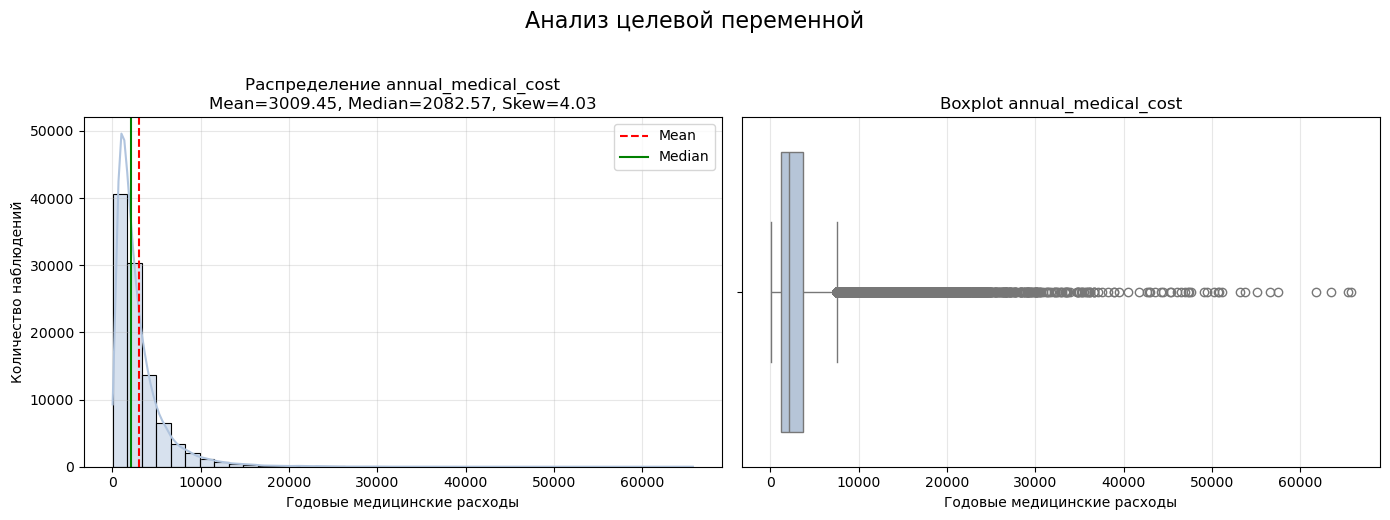

In [30]:
# Анализ распределения целевой переменной
# Смотрим форму распределения, асимметрию, основные статистики и возможные выбросы

target_data = df[target_col].dropna()

mean_val = target_data.mean()
median_val = target_data.median()
std_val = target_data.std()
skew_val = target_data.skew()

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

# Распределение таргета
sns.histplot(
    target_data,
    bins=40,
    kde=True,
    color='lightsteelblue',
    edgecolor='black',
    ax=axes[0]
)

axes[0].axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label='Mean')
axes[0].axvline(median_val, color='green', linestyle='-', linewidth=1.5, label='Median')

axes[0].set_title(
    f'Распределение {target_col}\n'
    f'Mean={mean_val:.2f}, Median={median_val:.2f}, Skew={skew_val:.2f}',
    fontsize=12
)
axes[0].set_xlabel('Годовые медицинские расходы')
axes[0].set_ylabel('Количество наблюдений')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Boxplot таргета
sns.boxplot(
    x=target_data,
    color='lightsteelblue',
    ax=axes[1]
)

axes[1].set_title(
    f'Boxplot {target_col}',
    fontsize=12
)
axes[1].set_xlabel('Годовые медицинские расходы')
axes[1].grid(axis='x', alpha=0.3)

fig.suptitle(
    'Анализ целевой переменной',
    fontsize=16,
    y=1.03
)

plt.tight_layout()
plt.show()

In [31]:
# Краткая статистика по целевой переменной

target_summary = pd.DataFrame({
    'count': [target_data.count()],
    'mean': [target_data.mean()],
    'median': [target_data.median()],
    'std': [target_data.std()],
    'min': [target_data.min()],
    'max': [target_data.max()],
    'skew': [target_data.skew()]
})

target_summary.round(2)

,count,mean,median,std,min,max,skew
0,100000,3009.45,2082.57,3127.46,55.55,65724.9,4.03


- Целевая переменная `annual_medical_cost` имеет выраженную правостороннюю асимметрию: большинство пациентов имеют сравнительно небольшие расходы, но есть длинный хвост пациентов с очень высокими затратами.

- Среднее значение расходов заметно выше медианы: около 3009 против 2083. Это подтверждает, что небольшая доля дорогих пациентов сильно влияет на среднее.

- Коэффициент асимметрии высокий (`skew = 4.03`), поэтому распределение таргета существенно отличается от нормального.

- На boxplot видно большое количество верхних выбросов. Для медицинских расходов это ожидаемо: отдельные пациенты могут иметь редкие, но очень дорогие случаи лечения.

- Автоматически удалять такие наблюдения не стоит, так как именно дорогие пациенты важны для задачи прогнозирования расходов.

- Для линейных моделей стоит рассмотреть логарифмирование таргета через `TransformedTargetRegressor`, а для деревянных моделей и бустингов таргет можно оставить в исходном масштабе.

In [32]:
# Оцениваем связь каждого признака с целевой переменной
# Используем phi_k, так как он умеет учитывать числовые, бинарные,
# категориальные и потенциально нелинейные зависимости

phik_features = feature_cols + [target_col]

phik_data = df[phik_features].copy()

# Бинарные и категориальные признаки явно приводим к category
for col in binary_features + categorical_features:
    phik_data[col] = phik_data[col].astype('category')

# Интервальными считаем только настоящие числовые признаки и таргет
interval_cols = numeric_features + [target_col]

phik_matrix = phik_data.phik_matrix(interval_cols=interval_cols)

# Достаём связи признаков с таргетом и убираем сам таргет
target_phik = (
    phik_matrix[target_col]
    .drop(target_col)
    .sort_values(ascending=False)
)

target_phik.round(3)

monthly_premium                0.846
annual_premium                 0.846
total_claims_paid              0.761
avg_claim_amount               0.729
risk_score                     0.236
is_high_risk                   0.233
days_hospitalized_last_3yrs    0.211
chronic_count                  0.178
visits_last_year               0.170
hospitalizations_last_3yrs     0.169
claims_count                   0.163
had_major_procedure            0.149
hypertension                   0.143
smoker                         0.142
medication_count               0.126
mental_health                  0.118
arthritis                      0.111
systolic_bp                    0.106
diabetes                       0.100
age                            0.093
diastolic_bp                   0.088
hba1c                          0.085
cardiovascular_disease         0.079
asthma                         0.076
proc_surgery_count             0.070
copd                           0.066
proc_consult_count             0.053
c

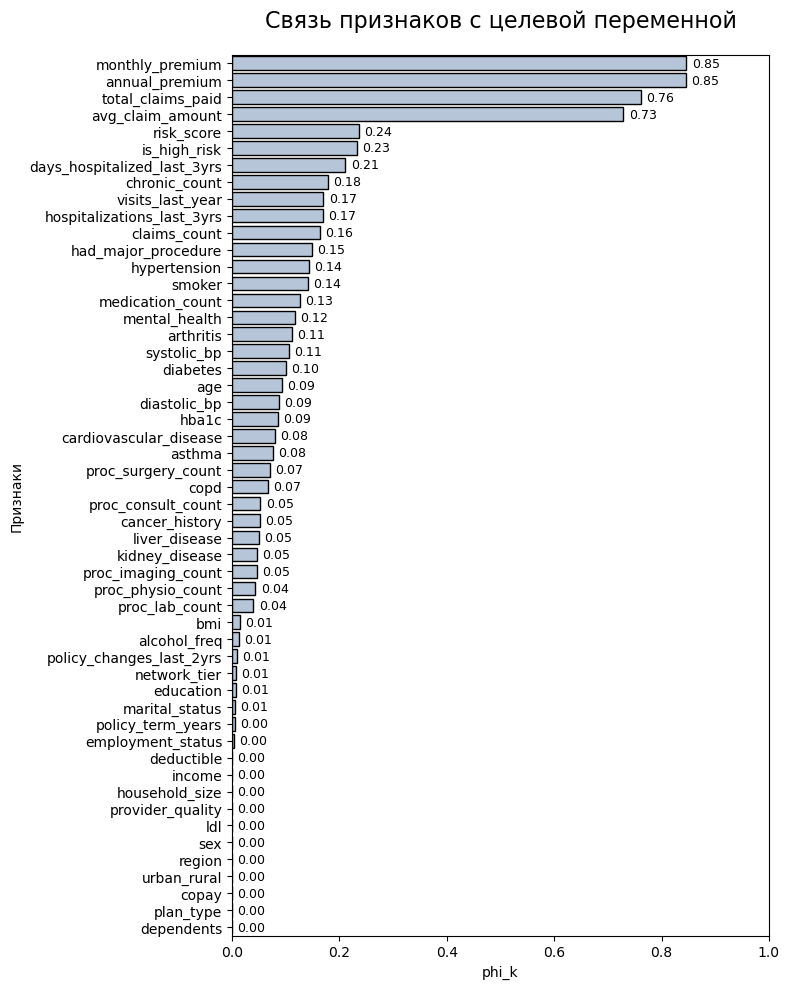

In [33]:
# Связь признаков с целевой переменной

target_phik = (
    phik_matrix[target_col]
    .drop(target_col)
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 10))

ax = sns.barplot(
    x=target_phik.values,
    y=target_phik.index,
    orient='h',
    color='lightsteelblue',
    edgecolor='black'
)

ax.set_title(
    'Связь признаков с целевой переменной',
    fontsize=16,
    pad=20
)
ax.set_xlabel('phi_k')
ax.set_ylabel('Признаки')
ax.set_xlim(0, 1)

# Подписываем значения на барах
for i, value in enumerate(target_phik.values):
    ax.text(
        value + 0.01,
        i,
        f'{value:.2f}',
        va='center',
        fontsize=9
    )

plt.tight_layout()
plt.show()

- В all-features версии наиболее сильную связь с целевой переменной показывают признаки, напрямую связанные со стоимостью и страховыми выплатами: `monthly_premium`, `annual_premium`, `total_claims_paid` и `avg_claim_amount`.

- `monthly_premium` и `annual_premium` имеют практически одинаковую связь с таргетом, так как месячная премия является производной от годовой. Это почти дублирующие признаки.

- После premium- и claims-признаков наиболее заметную связь с таргетом сохраняют признаки риска и медицинской нагрузки: `risk_score`, `is_high_risk`, `days_hospitalized_last_3yrs`, `chronic_count`, `visits_last_year`, `hospitalizations_last_3yrs`.

- Также умеренную связь показывают признаки состояния здоровья и поведения пациента: `hypertension`, `smoker`, `medication_count`, `mental_health`, `arthritis`, `diabetes`, показатели давления и хронические заболевания.

- Социально-демографические и policy-признаки вроде `sex`, `region`, `urban_rural`, `plan_type`, `copay`, `deductible`, `provider_quality` почти не показывают самостоятельной связи с таргетом, но их можно оставить: эффект может проявляться во взаимодействиях с другими признаками.

- В целом график подтверждает, что полный набор признаков содержит очень сильные предикторы таргета. При этом основной прирост информативности связан именно с premium- и claims-признаками.

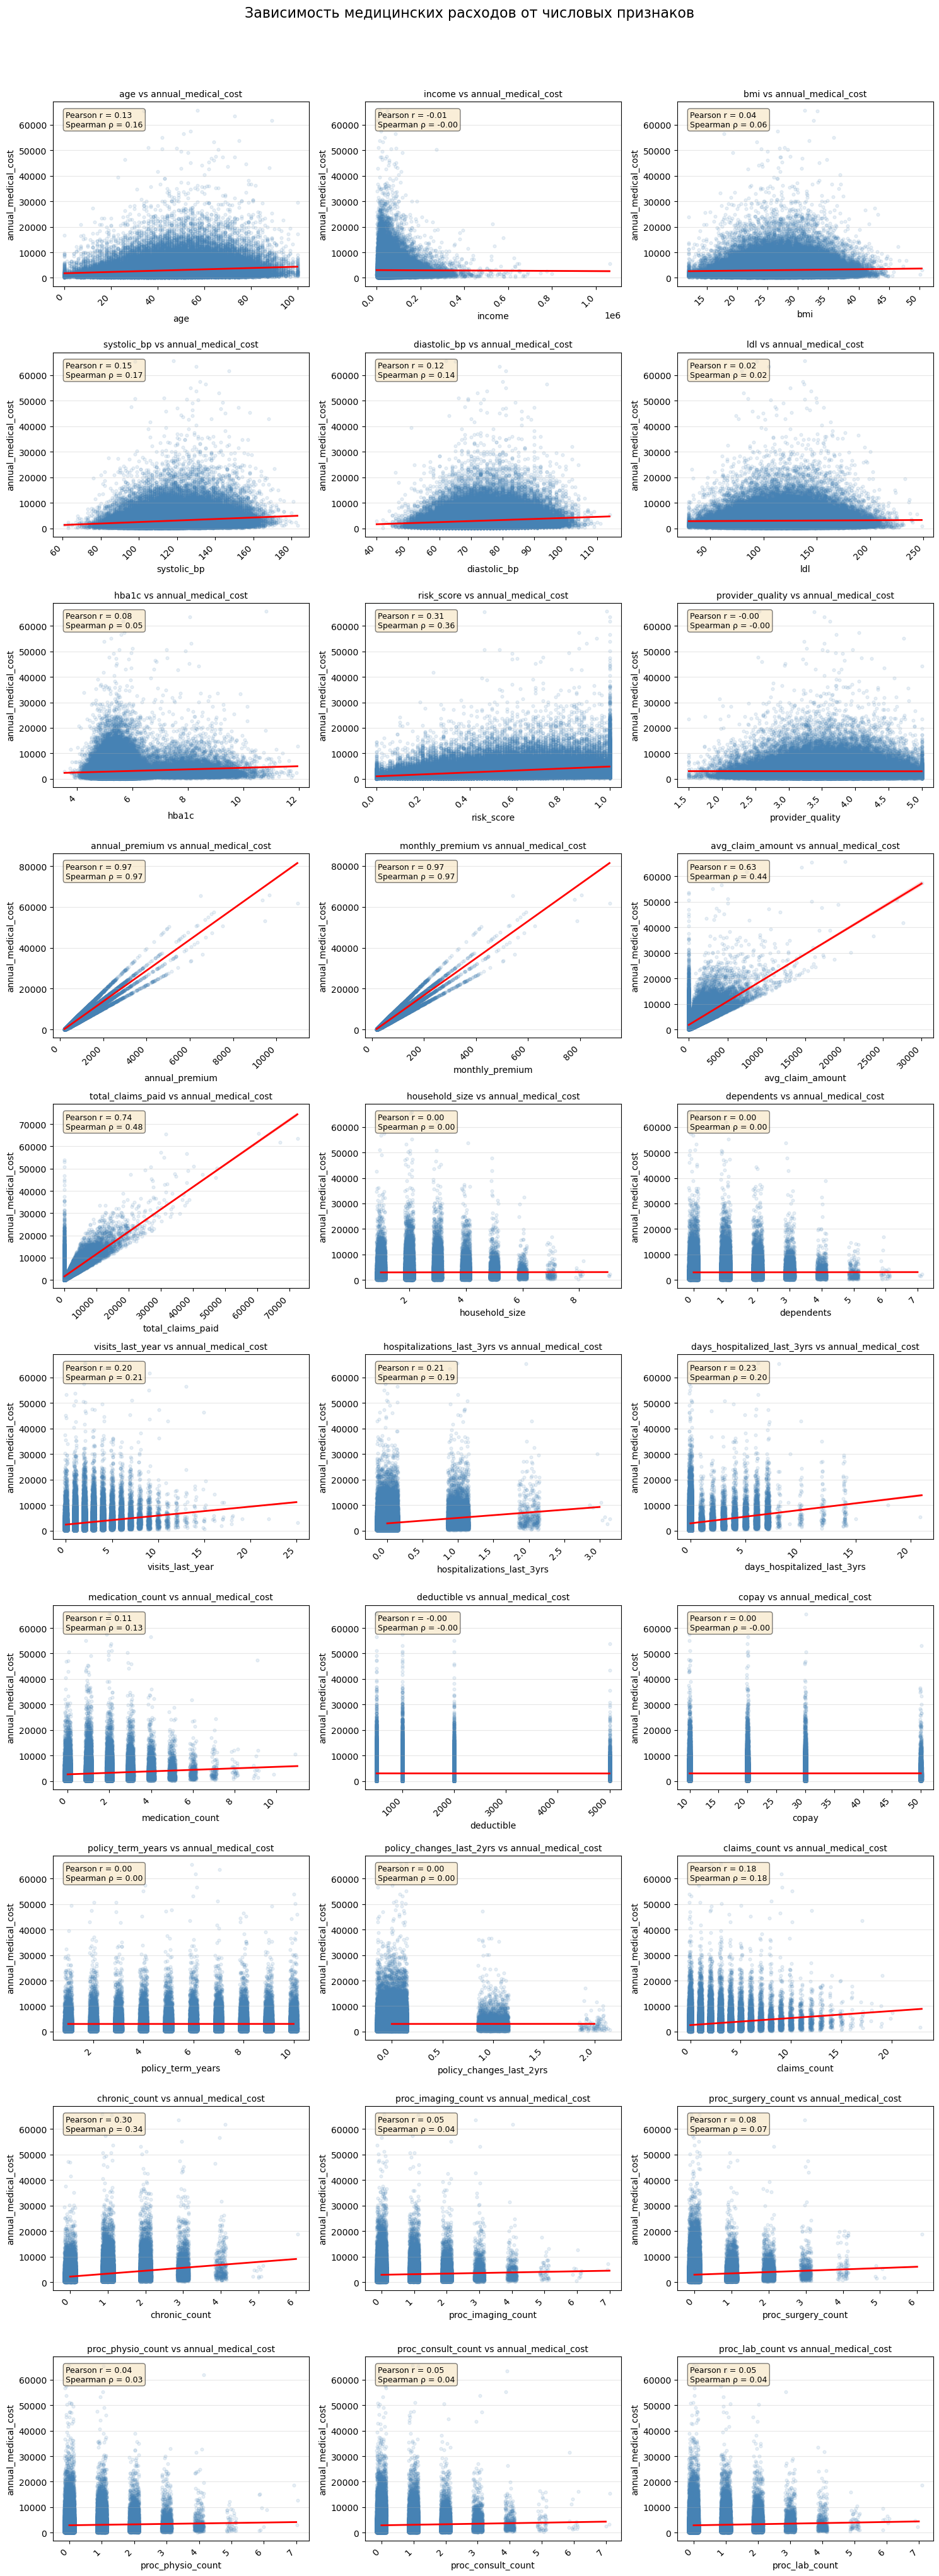

In [34]:
# Связь числовых признаков с целевой переменной
# Смотрим scatterplot + линейный тренд, а также Pearson и Spearman корреляции

plot_features = numeric_features

n_cols = 3
n_rows = (len(plot_features) + n_cols - 1) // n_cols

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(5 * n_cols, 4 * n_rows)
)

axes = np.array(axes).flatten()

for i, feature in enumerate(plot_features):
    ax = axes[i]

    # Для дискретных признаков добавляем небольшой jitter,
    # чтобы точки не накладывались строго друг на друга
    x_jitter = 0.15 if feature in count_features else None

    sns.regplot(
        data=df,
        x=feature,
        y=target_col,
        scatter_kws={
            'alpha': 0.12,
            's': 12,
            'color': 'steelblue'
        },
        line_kws={
            'color': 'red',
            'linewidth': 2
        },
        x_jitter=x_jitter,
        ax=ax
    )

    pearson_corr = df[[feature, target_col]].corr(method='pearson').iloc[0, 1]
    spearman_corr = df[[feature, target_col]].corr(method='spearman').iloc[0, 1]

    ax.text(
        0.05,
        0.95,
        f'Pearson r = {pearson_corr:.2f}\nSpearman ρ = {spearman_corr:.2f}',
        transform=ax.transAxes,
        fontsize=9,
        verticalalignment='top',
        bbox=dict(
            boxstyle='round',
            facecolor='wheat',
            alpha=0.5
        )
    )

    ax.set_title(
        f'{feature} vs {target_col}',
        fontsize=10
    )
    ax.set_xlabel(feature)
    ax.set_ylabel(target_col)
    ax.grid(axis='y', alpha=0.3)

    plt.setp(
        ax.xaxis.get_majorticklabels(),
        rotation=45,
        ha='right'
    )

# Удаляем пустые оси
for j in range(len(plot_features), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle(
    'Зависимость медицинских расходов от числовых признаков',
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()

- В all-features версии наиболее выраженная связь с таргетом видна у premium- и claims-признаков: `annual_premium`, `monthly_premium`, `total_claims_paid`, `avg_claim_amount`.

- `annual_premium` и `monthly_premium` имеют почти линейную связь с `annual_medical_cost`. Это ожидаемо, так как premium-признаки, вероятно, рассчитываются с учётом ожидаемой стоимости пациента.

- `total_claims_paid` и `avg_claim_amount` также сильно связаны с расходами, потому что напрямую описывают размер страховых выплат.

- Среди остальных медицинских признаков сохраняется положительная связь у `risk_score`, `chronic_count`, `days_hospitalized_last_3yrs`, `hospitalizations_last_3yrs`, `visits_last_year` и `claims_count`.

- Признаки медицинской нагрузки имеют правый хвост: большинство пациентов имеет низкие значения, но у пациентов с высокой активностью расходы заметно выше.

- Клинические показатели (`systolic_bp`, `diastolic_bp`, `hba1c`) показывают слабую положительную связь с расходами. `bmi`, `ldl`, `income`, `household_size`, `dependents` почти не имеют самостоятельной линейной связи с таргетом.

- Policy-признаки вроде `deductible`, `copay`, `policy_term_years`, `policy_changes_last_2yrs` визуально почти не показывают сильной линейной связи с расходами, но их можно оставить для моделей, так как эффект может проявляться во взаимодействиях.

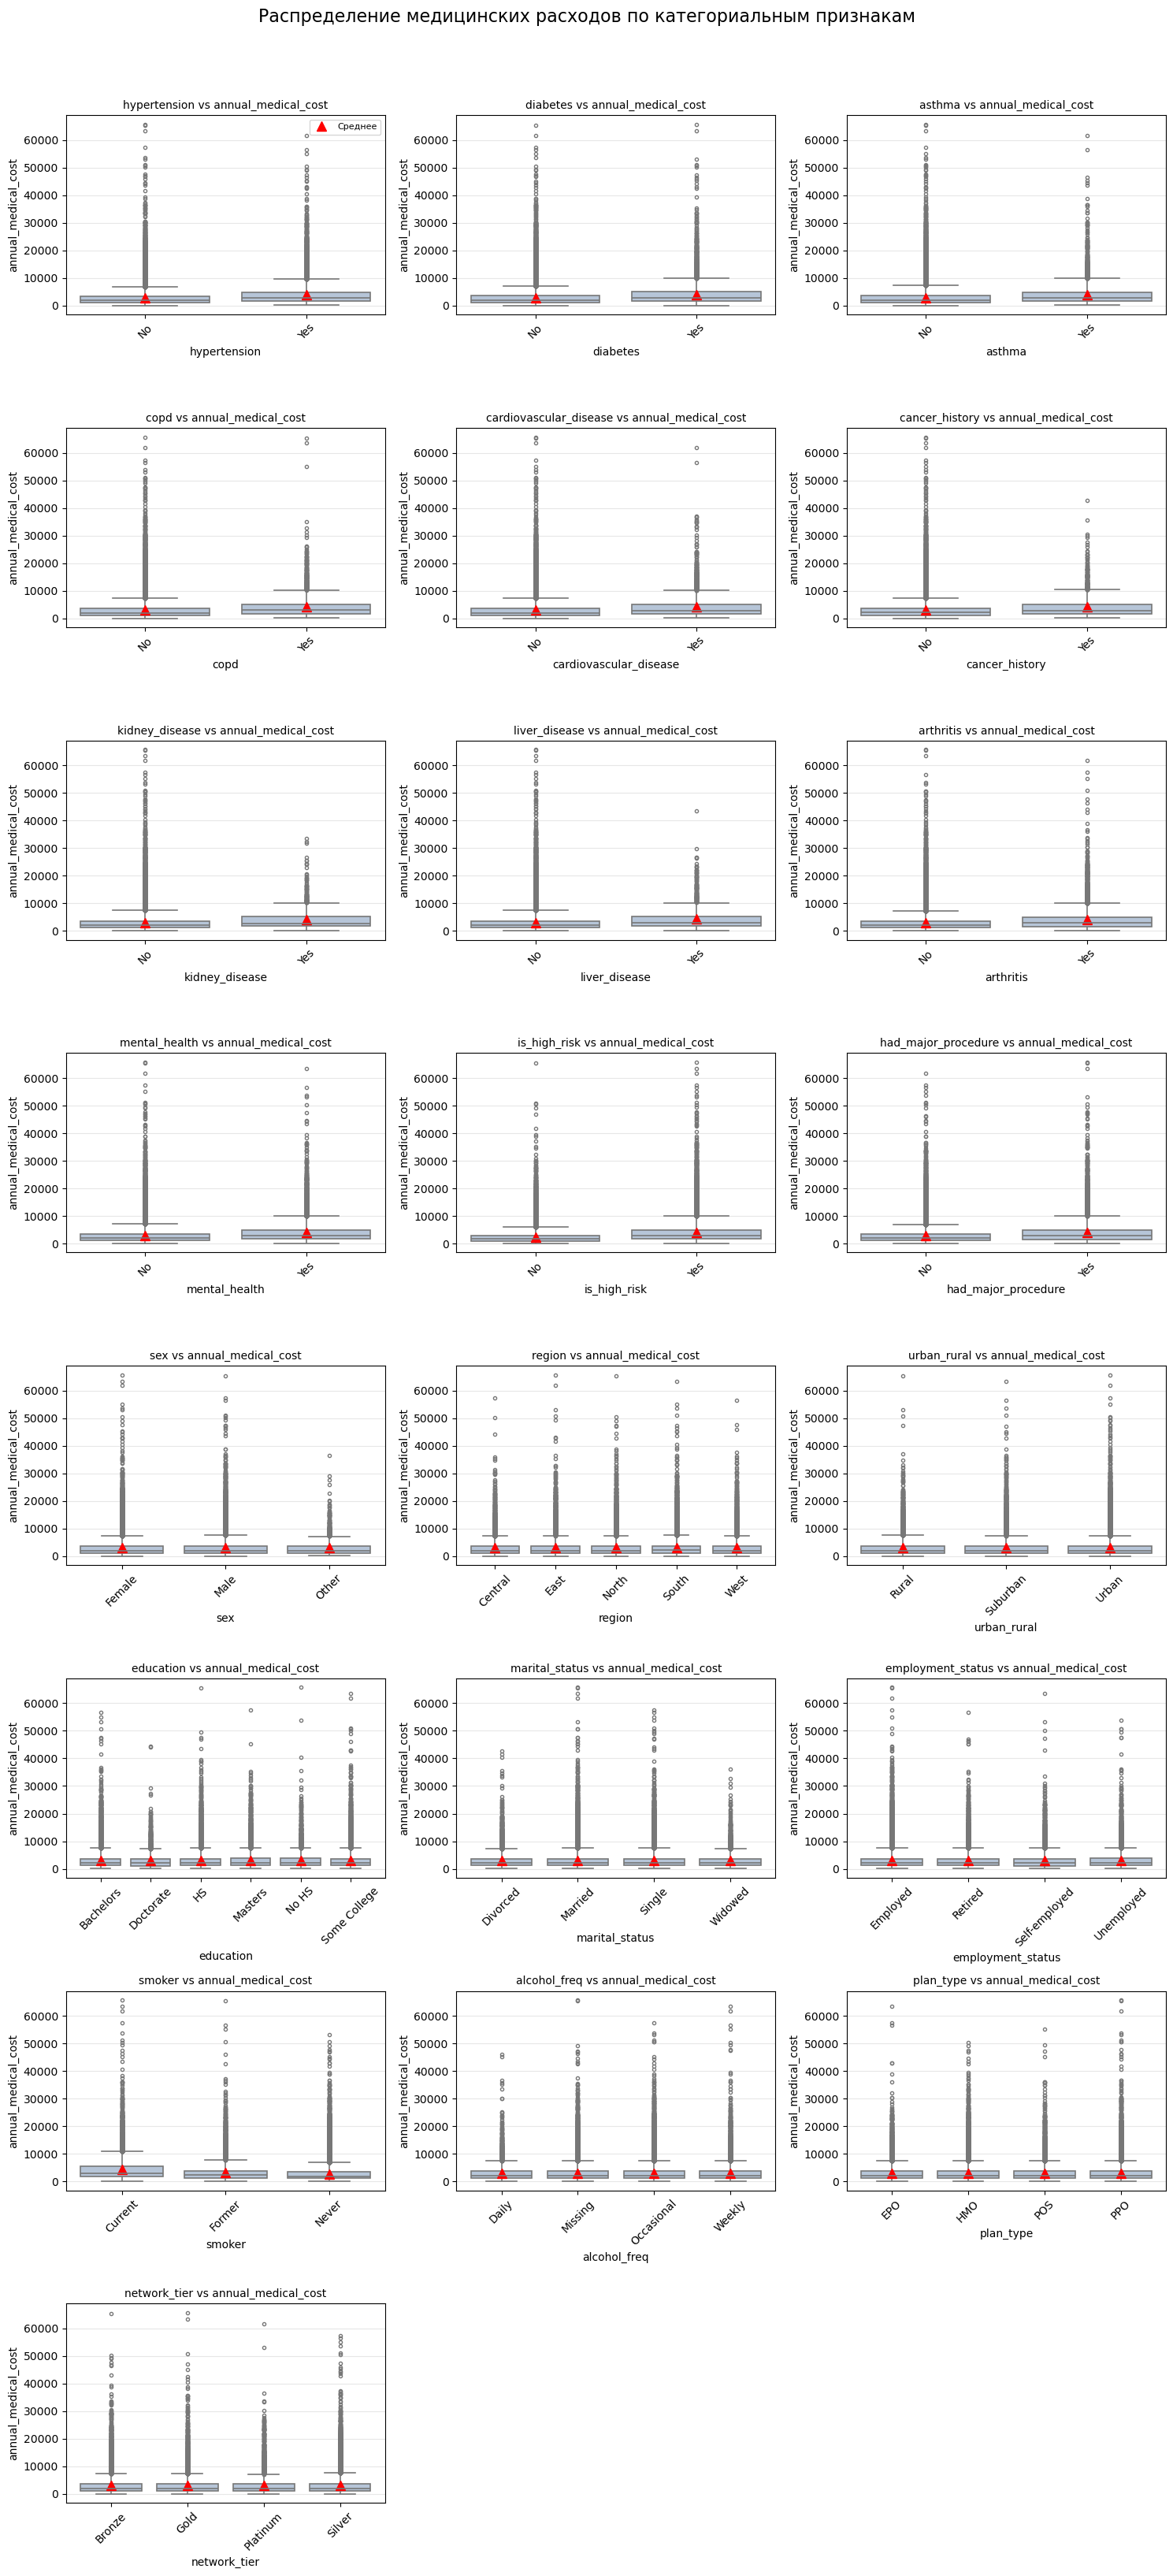

In [35]:
# Зависимость целевой переменной от категориальных и бинарных признаков
# Смотрим, как распределяются медицинские расходы в разных категориях признаков

plot_features = cat_features_for_eda

# Копия датафрейма только для визуализации
plot_df = df.copy()

# Читаемые подписи для бинарных признаков
binary_value_labels = {
    col: {0: 'No', 1: 'Yes'}
    for col in binary_features
}

# Заменяем 0/1 на текстовые категории только для графиков
for col, mapping in binary_value_labels.items():
    plot_df[col] = plot_df[col].map(mapping)

n_cols = 3
n_rows = (len(plot_features) + n_cols - 1) // n_cols

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(5 * n_cols, 4 * n_rows)
)

axes = np.array(axes).flatten()

for i, col in enumerate(plot_features):
    ax = axes[i]

    # Учитываем пропуски как отдельную категорию, если они есть
    plot_df[col] = plot_df[col].fillna('Missing')

    # Средние значения таргета по категориям
    means = plot_df.groupby(col, observed=False)[target_col].mean()

    # Порядок категорий на графике
    order = means.index.tolist()

    sns.boxplot(
        data=plot_df,
        x=col,
        y=target_col,
        order=order,
        color='lightsteelblue',
        fliersize=3,
        linewidth=1.2,
        ax=ax
    )

    # Отмечаем среднее значение таргета по каждой категории
    for j, category in enumerate(order):
        ax.plot(
            j,
            means.loc[category],
            'r^',
            markersize=8,
            label='Среднее' if j == 0 else ''
        )

    ax.set_title(f'{col} vs {target_col}', fontsize=10)
    ax.set_xlabel(col)
    ax.set_ylabel(target_col)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', alpha=0.3)

    if i == 0:
        ax.legend(loc='upper right', fontsize=8)

# Удаляем пустые оси
for j in range(len(plot_features), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle(
    'Распределение медицинских расходов по категориальным признакам',
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()

- По большинству медицинских бинарных признаков группа `Yes` имеет более высокие средние и медианные расходы, чем группа `No`. Это особенно заметно для `hypertension`, `asthma`, `copd`, `cardiovascular_disease`, `arthritis`, `mental_health`, `is_high_risk` и `had_major_procedure`.

- `is_high_risk` и `had_major_procedure` визуально хорошо разделяют пациентов по уровню расходов, но `is_high_risk` далее исключаем из-за сильного дублирования с `risk_score`.

- Для редких заболеваний (`kidney_disease`, `liver_disease`, `cancer_history`, `copd`) положительный класс малочисленный, поэтому boxplot менее устойчив, но в среднем расходы у таких пациентов выше.

- Социально-демографические признаки (`sex`, `region`, `urban_rural`, `education`, `marital_status`, `employment_status`) показывают более слабые различия между категориями.

- По `smoker` видно, что текущие курильщики (`Current`) имеют более высокие расходы, чем `Former` и `Never`.

- Для `alcohol_freq` различия умеренные, но категория `Missing` остаётся важной: пропуски лучше не удалять, а кодировать как отдельную категорию.

- Во всех группах присутствует длинный верхний хвост расходов, что подтверждает наличие небольшой группы пациентов с очень высокими медицинскими затратами.

## Общие выводы по EDA

- В `all-features` версии используется более полный набор признаков нового датасета: демографические, социально-экономические, клинические, поведенческие признаки, показатели медицинской нагрузки, процедуры, policy-признаки, premium- и claims-признаки.

- Целевая переменная `annual_medical_cost` имеет выраженную правостороннюю асимметрию: большинство пациентов имеют относительно небольшие расходы, но есть небольшая группа с очень высокими медицинскими затратами.

- Большинство числовых признаков выглядит реалистично, явных некорректных значений не обнаружено. Выбросы в основном соответствуют редким, но возможным случаям: высоким расходам, большим выплатам, госпитализациям, процедурам или высоким значениям дохода.

- Наиболее асимметричные признаки — `total_claims_paid`, `avg_claim_amount`, `annual_premium`, `monthly_premium`, `income`, а также признаки госпитализаций, процедур и медицинской нагрузки. Для линейных моделей такие признаки стоит обрабатывать через `log1p`, для деревьев и бустингов специальная трансформация обычно не требуется.

- Многие бинарные медицинские признаки несбалансированы: положительный класс встречается редко, но часто связан с более высокими медицинскими расходами.

- В all-features сценарии наиболее сильную связь с таргетом показывают premium- и claims-признаки: `annual_premium`, `monthly_premium`, `total_claims_paid`, `avg_claim_amount`.

- Среди медицинских признаков заметную связь с таргетом сохраняют `risk_score`, `is_high_risk`, `days_hospitalized_last_3yrs`, `chronic_count`, `visits_last_year`, `hospitalizations_last_3yrs`, `claims_count`, `had_major_procedure` и `smoker`.

- В матрице зависимостей есть признаки с высокой взаимной связью: `annual_premium` почти дублирует `monthly_premium`, `is_high_risk` дублирует `risk_score`, а `diabetes` сильно связан с `hba1c`.

- Социально-демографические и часть policy-признаков сами по себе слабо связаны с таргетом, но могут быть полезны во взаимодействиях с другими признаками, поэтому автоматически не удаляются.

- В целом полный набор признаков должен дать моделям заметно больше информации и потенциально лучшее качество, чем предыдущие эксперименты.

# ML-моделирование


В этом разделе переходим к построению моделей и ансамблей.  
Сначала фиксируем train/test split, группы признаков, стратегию кросс-валидации и общие функции для оценки качества.

Test set откладывается до самого конца и не используется ни для подбора гиперпараметров, ни для расчёта весов ансамблей.  
Вся промежуточная оценка моделей выполняется внутри train через cross-validation и out-of-fold predictions.

In [69]:
# Базовые настройки эксперимента

RANDOM_STATE = 42
TEST_SIZE = 0.2
N_SPLITS = 5

np.random.seed(RANDOM_STATE)

In [70]:
# Фиксируем целевую переменную и технический идентификатор

target_col = 'annual_medical_cost'
id_col = 'person_id'


# Числовые признаки
# В all-features версии используем полный набор доступных числовых признаков,
# исключая только premium-признаки как явные leakage-переменные.

numeric_features = [
    # demographics & socioeconomic
    'age',
    'income',
    'household_size',
    'dependents',

    # lifestyle & clinical
    'bmi',
    'systolic_bp',
    'diastolic_bp',
    'ldl',
    'hba1c',
    'risk_score',

    # healthcare utilization
    'visits_last_year',
    'hospitalizations_last_3yrs',
    'days_hospitalized_last_3yrs',
    'medication_count',

    # policy
    'deductible',
    'copay',
    'policy_term_years',
    'policy_changes_last_2yrs',
    'provider_quality',

    # claims
    'claims_count',
    'avg_claim_amount',
    'total_claims_paid',

    # health summary
    'chronic_count',

    # procedures
    'proc_imaging_count',
    'proc_surgery_count',
    'proc_physio_count',
    'proc_consult_count',
    'proc_lab_count'
]


# Бинарные признаки, уже закодированные как 0/1
# diabetes исключаем, так как он почти полностью дублирует hba1c
# is_high_risk исключаем, так как он почти полностью дублирует risk_score

binary_features = [
    'hypertension',
    'asthma',
    'copd',
    'cardiovascular_disease',
    'cancer_history',
    'kidney_disease',
    'liver_disease',
    'arthritis',
    'mental_health',
    'had_major_procedure'
]


# Номинальные категориальные признаки
# Добавляем также policy-признаки plan_type и network_tier.

categorical_features = [
    'sex',
    'region',
    'urban_rural',
    'education',
    'marital_status',
    'employment_status',
    'smoker',
    'alcohol_freq',
    'plan_type',
    'network_tier'
]


# Все признаки для модели

feature_cols = numeric_features + binary_features + categorical_features


# Признаки, которые исключаем из моделирования

excluded_features = [
    id_col,
    target_col
]


# Проверяем, что исключённые признаки не попали в feature_cols

leaked_features = [
    col for col in excluded_features
    if col in feature_cols
]

assert len(leaked_features) == 0, (
    f'В feature_cols попали исключённые признаки: {leaked_features}'
)


# Проверяем наличие нужных колонок

required_cols = feature_cols + [target_col]
missing_cols = [
    col for col in required_cols
    if col not in df.columns
]

assert len(missing_cols) == 0, f'В df отсутствуют колонки: {missing_cols}'
assert df[target_col].isna().sum() == 0, 'В целевой переменной есть пропуски'


# Формируем X и y

X = df[feature_cols].copy()
y = df[target_col].copy()

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print(f'Количество признаков: {len(feature_cols)}')
print(f'Числовых признаков: {len(numeric_features)}')
print(f'Бинарных признаков: {len(binary_features)}')
print(f'Категориальных признаков: {len(categorical_features)}')

X shape: (100000, 48)
y shape: (100000,)
Количество признаков: 48
Числовых признаков: 28
Бинарных признаков: 10
Категориальных признаков: 10


In [71]:
X.head()

,age,income,household_size,dependents,bmi,systolic_bp,diastolic_bp,ldl,hba1c,risk_score,visits_last_year,hospitalizations_last_3yrs,days_hospitalized_last_3yrs,medication_count,deductible,copay,policy_term_years,policy_changes_last_2yrs,provider_quality,claims_count,avg_claim_amount,total_claims_paid,chronic_count,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,hypertension,asthma,copd,cardiovascular_disease,cancer_history,kidney_disease,liver_disease,arthritis,mental_health,had_major_procedure,sex,region,urban_rural,education,marital_status,employment_status,smoker,alcohol_freq,plan_type,network_tier
0,52,22700.0,3,1,27.4,121.0,76.0,123.8,5.28,0.5714,2,0,0,4,1000,20,4,0,3.73,1,4672.59,4672.59,1,1,0,2,0,1,0,0,0,0,0,0,0,1,0,0,Female,North,Suburban,Doctorate,Married,Retired,Never,NaN,PPO,Bronze
1,79,12800.0,3,1,26.6,131.0,79.0,97.3,4.82,1.0000,2,0,0,3,1000,10,1,0,3.10,4,297.27,1189.08,2,0,0,1,0,1,0,0,0,0,0,0,0,1,1,0,Female,North,Urban,No HS,Married,Employed,Never,Weekly,POS,Gold
2,68,40700.0,5,3,31.5,160.0,84.0,129.5,5.51,1.0000,1,0,0,4,500,20,10,0,3.90,0,0.00,0.00,3,1,0,2,1,0,1,0,0,0,1,0,0,0,1,0,Male,North,Rural,HS,Married,Retired,Never,NaN,HMO,Platinum
3,15,15600.0,5,3,31.6,104.0,68.0,160.3,8.50,0.2857,0,0,0,1,500,20,5,0,3.89,0,0.00,0.00,1,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,Male,North,Suburban,Some College,Married,Self-employed,Never,NaN,HMO,Silver
4,53,89600.0,2,0,30.5,136.0,83.0,171.0,5.20,0.8681,3,0,0,2,500,10,7,0,3.90,1,1002.24,1002.24,2,2,0,1,1,0,1,0,0,0,0,0,0,1,0,0,Male,Central,Suburban,Doctorate,Married,Self-employed,Never,Daily,POS,Platinum


In [72]:
# Делаем стратификацию по бинам таргета,
# чтобы сохранить похожее распределение annual_medical_cost в train и test

target_bins = pd.qcut(
    y,
    q=10,
    labels=False,
    duplicates='drop'
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=target_bins
)

# Сбрасываем индексы, чтобы дальше удобно работать с OOF/test predictions
X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

print(f'Train shape: {X_train.shape}')
print(f'Test shape:  {X_test.shape}')

Train shape: (80000, 48)
Test shape:  (20000, 48)


In [73]:
# Проверяем, что распределение таргета в train и test похоже

def get_target_summary(y_values, name):
    return pd.Series({
        'count': y_values.count(),
        'mean': y_values.mean(),
        'median': y_values.median(),
        'std': y_values.std(),
        'min': y_values.min(),
        'max': y_values.max(),
        'skew': y_values.skew()
    }, name=name)


target_split_summary = pd.concat(
    [
        get_target_summary(y_train, 'train'),
        get_target_summary(y_test, 'test')
    ],
    axis=1
)

target_split_summary.round(2)

,train,test
count,80000.00,20000.00
mean,3011.43,3001.54
median,2082.54,2082.76
std,3139.55,3078.69
min,55.55,57.85
max,65724.90,56596.07
skew,4.08,3.81


In [74]:
# Выделяем числовые признаки с заметной асимметрией.
# Это пригодится для preprocessing pipeline линейных моделей.

skew_threshold = 0.5

train_skew_values = X_train[numeric_features].skew()

numeric_skewed = train_skew_values[
    train_skew_values.abs() > skew_threshold
].index.tolist()

numeric_standard = [
    col for col in numeric_features
    if col not in numeric_skewed
]

print(f'Признаки с заметной асимметрией: {numeric_skewed}')
print(f'Остальные числовые признаки: {numeric_standard}')

Признаки с заметной асимметрией: ['income', 'household_size', 'dependents', 'hba1c', 'visits_last_year', 'hospitalizations_last_3yrs', 'days_hospitalized_last_3yrs', 'medication_count', 'deductible', 'copay', 'policy_changes_last_2yrs', 'claims_count', 'avg_claim_amount', 'total_claims_paid', 'chronic_count', 'proc_imaging_count', 'proc_surgery_count', 'proc_physio_count', 'proc_consult_count', 'proc_lab_count']
Остальные числовые признаки: ['age', 'bmi', 'systolic_bp', 'diastolic_bp', 'ldl', 'risk_score', 'policy_term_years', 'provider_quality']


In [75]:
# Стратегия кросс-валидации

cv = KFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)

In [76]:
# Метрики для оценки моделей.
# Основная метрика — MAE, так как она интерпретируется в денежных единицах.

scoring = {
    'mae': 'neg_mean_absolute_error',
    'rmse': make_scorer(root_mean_squared_error, greater_is_better=False),
    'r2': 'r2',
    'mape': 'neg_mean_absolute_percentage_error'
}

refit_metric = 'mae'

In [77]:
# Helper-функция для расчёта метрик на одном наборе данных

def calculate_regression_metrics(y_true, y_pred):
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': root_mean_squared_error(y_true, y_pred),
        'R2': r2_score(y_true, y_pred),
        'MAPE': mean_absolute_percentage_error(y_true, y_pred)
    }

# Helper-функция для оценки модели на кросс-валидации

def cross_validate_regression_model(
    model,
    X,
    y,
    model_name,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
):
    cv_results = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring=scoring,
        n_jobs=n_jobs,
        return_train_score=False
    )

    result = {
        'model': model_name,
        'CV_MAE_mean': -cv_results['test_mae'].mean(),
        'CV_MAE_std': (-cv_results['test_mae']).std(),
        'CV_RMSE_mean': -cv_results['test_rmse'].mean(),
        'CV_RMSE_std': (-cv_results['test_rmse']).std(),
        'CV_R2_mean': cv_results['test_r2'].mean(),
        'CV_R2_std': cv_results['test_r2'].std(),
        'CV_MAPE_mean': -cv_results['test_mape'].mean(),
        'CV_MAPE_std': (-cv_results['test_mape']).std()
    }

    return pd.Series(result)


# Helper-функция для финальной оценки уже обученной модели на test.
# Test будем использовать только в самом конце исследования.

def evaluate_on_test(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)

    metrics = calculate_regression_metrics(y_test, y_pred)
    metrics['model'] = model_name

    metrics = {
        'model': metrics.pop('model'),
        **metrics
    }

    return pd.Series(metrics), y_pred

In [78]:
# Контейнеры для результатов

cv_results = []
test_results = []
test_predictions = {}

## 1. Линейные модели

В качестве линейного baseline обучаем три регуляризованные модели:

- `Ridge` — L2-регуляризация;
- `Lasso` — L1-регуляризация;
- `ElasticNet` — комбинация L1 и L2.

Для линейных моделей используем отдельный preprocessing pipeline: числовые признаки масштабируются, асимметричные счётчики дополнительно логарифмируются, бинарные признаки остаются в формате 0/1, а категориальные признаки кодируются через one-hot encoding.

In [79]:
# Preprocessing для линейных моделей

def make_linear_preprocessor(
    numeric_standard,
    numeric_skewed,
    binary_features,
    categorical_features
):
    transformers = []

    if len(numeric_standard) > 0:
        standard_numeric_pipeline = Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ])

        transformers.append(
            ('num_standard', standard_numeric_pipeline, numeric_standard)
        )

    if len(numeric_skewed) > 0:
        skewed_numeric_pipeline = Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('log1p', FunctionTransformer(np.log1p, feature_names_out='one-to-one')),
            ('scaler', StandardScaler())
        ])

        transformers.append(
            ('num_skewed', skewed_numeric_pipeline, numeric_skewed)
        )

    if len(binary_features) > 0:
        binary_pipeline = Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent'))
        ])

        transformers.append(
            ('binary', binary_pipeline, binary_features)
        )

    if len(categorical_features) > 0:
        # Явно задаём базовые категории:
        categorical_drop_map = {
            'sex': 'Other',
            'region': 'Central',
            'urban_rural': 'Rural',
            'education': 'No HS',
            'marital_status': 'Single',
            'employment_status': 'Unemployed',
            'smoker': 'Never',
            'alcohol_freq': 'Missing',
            'plan_type': 'POS',
            'network_tier': 'Platinum'
        }

        categorical_drop = [
            categorical_drop_map[col]
            for col in categorical_features
        ]

        categorical_pipeline = Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
            ('encoder', OneHotEncoder(
                drop=categorical_drop,
                handle_unknown='ignore',
                sparse_output=False
            ))
        ])

        transformers.append(
            ('cat', categorical_pipeline, categorical_features)
        )

    return ColumnTransformer(
        transformers=transformers,
        remainder='drop',
        verbose_feature_names_out=True
    )


# Собираем pipeline для линейных моделей

def make_linear_pipeline(model):
    linear_preprocessor = make_linear_preprocessor(
        numeric_standard=numeric_standard,
        numeric_skewed=numeric_skewed,
        binary_features=binary_features,
        categorical_features=categorical_features
    )

    target_model = TransformedTargetRegressor(
        regressor=model,
        func=np.log1p,
        inverse_func=np.expm1
    )

    return Pipeline([
        ('preprocessor', linear_preprocessor),
        ('model', target_model)
    ])


# Helper-функция для запуска GridSearchCV

def run_grid_search(model_name, pipeline, param_grid):
    search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        scoring=scoring,
        refit='mae',
        cv=cv,
        n_jobs=-1,
        return_train_score=False,
        verbose=1
    )

    search.fit(X_train, y_train)

    print(f'{model_name}')
    print(f'Best CV MAE: {-search.best_score_:.4f}')
    print(f'Best params: {search.best_params_}')
    print()

    return search


# Helper-функция для извлечения метрик лучшей модели из GridSearchCV

def get_best_grid_metrics(search, model_name):
    best_idx = search.best_index_

    return pd.Series({
        'model': model_name,
        'CV_MAE_mean': -search.cv_results_['mean_test_mae'][best_idx],
        'CV_MAE_std': search.cv_results_['std_test_mae'][best_idx],
        'CV_RMSE_mean': -search.cv_results_['mean_test_rmse'][best_idx],
        'CV_RMSE_std': search.cv_results_['std_test_rmse'][best_idx],
        'CV_R2_mean': search.cv_results_['mean_test_r2'][best_idx],
        'CV_R2_std': search.cv_results_['std_test_r2'][best_idx],
        'CV_MAPE_mean': -search.cv_results_['mean_test_mape'][best_idx],
        'CV_MAPE_std': search.cv_results_['std_test_mape'][best_idx]
    })

### Ridge Regression

In [80]:
# Ridge Regression

ridge_pipeline = make_linear_pipeline(
    Ridge(random_state=RANDOM_STATE)
)

ridge_param_grid = {
    'model__regressor__alpha': np.logspace(-3, 4, 12)
}

ridge_search = run_grid_search(
    model_name='Ridge',
    pipeline=ridge_pipeline,
    param_grid=ridge_param_grid
)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Ridge
Best CV MAE: 1239.4006
Best params: {'model__regressor__alpha': 0.3511191734215131}



### Lasso Regression

In [81]:
# Lasso Regression

lasso_pipeline = make_linear_pipeline(
    Lasso(
        max_iter=50_000,
        random_state=RANDOM_STATE
    )
)

lasso_param_grid = {
    'model__regressor__alpha': np.logspace(-4, 2, 12)
}

lasso_search = run_grid_search(
    model_name='Lasso',
    pipeline=lasso_pipeline,
    param_grid=lasso_param_grid
)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Lasso
Best CV MAE: 1239.0622
Best params: {'model__regressor__alpha': 0.0001}



### ElasticNet Regression

In [82]:
# ElasticNet Regression

elasticnet_pipeline = make_linear_pipeline(
    ElasticNet(
        max_iter=50_000,
        random_state=RANDOM_STATE
    )
)

elasticnet_param_grid = {
    'model__regressor__alpha': np.logspace(-4, 2, 10),
    'model__regressor__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
}

elasticnet_search = run_grid_search(
    model_name='ElasticNet',
    pipeline=elasticnet_pipeline,
    param_grid=elasticnet_param_grid
)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
ElasticNet
Best CV MAE: 1239.5633
Best params: {'model__regressor__alpha': 0.0001, 'model__regressor__l1_ratio': 0.9}



### Результаты линейных моделей

In [83]:
# Собираем CV-результаты линейных моделей

linear_cv_results = pd.DataFrame([
    get_best_grid_metrics(ridge_search, 'Ridge'),
    get_best_grid_metrics(lasso_search, 'Lasso'),
    get_best_grid_metrics(elasticnet_search, 'ElasticNet')
])

linear_cv_results = linear_cv_results.sort_values(
    by='CV_MAE_mean',
    ascending=True
).reset_index(drop=True)

linear_cv_results.round(4)

,model,CV_MAE_mean,CV_MAE_std,CV_RMSE_mean,CV_RMSE_std,CV_R2_mean,CV_R2_std,CV_MAPE_mean,CV_MAPE_std
0,Lasso,1239.0622,8.1658,2271.6789,29.6664,0.4762,0.0132,0.5063,0.0060
1,Ridge,1239.4006,8.1653,2271.0970,29.8514,0.4765,0.0135,0.5063,0.0060
2,ElasticNet,1239.5633,8.5095,2277.5386,28.7739,0.4735,0.0128,0.5065,0.0059


In [84]:
# Сохраняем fitted-модели.
# GridSearchCV уже обучил best_estimator_ на всём train.

linear_fitted_models = {
    'Ridge': ridge_search.best_estimator_,
    'Lasso': lasso_search.best_estimator_,
    'ElasticNet': elasticnet_search.best_estimator_
}

best_linear_name = linear_cv_results.loc[0, 'model']
best_linear_model = linear_fitted_models[best_linear_name]

print(f'Лучшая линейная модель по CV MAE: {best_linear_name}')

Лучшая линейная модель по CV MAE: Lasso


In [85]:
# Добавляем результаты линейных моделей в общий список CV-результатов

cv_results.extend(linear_cv_results.to_dict('records'))

### Анализ feature importance для линейных моделей

In [86]:
# Функции для извлечения коэффициентов линейной модели после preprocessing

def clean_transformed_feature_name(feature_name):
    return feature_name.split('__', 1)[-1]


def get_original_feature_name(transformed_feature_name, original_features):
    clean_name = clean_transformed_feature_name(transformed_feature_name)

    for feature in sorted(original_features, key=len, reverse=True):
        if clean_name == feature or clean_name.startswith(f'{feature}_'):
            return feature

    return clean_name


def get_linear_coefficients(fitted_pipeline):
    feature_names = fitted_pipeline.named_steps['preprocessor'].get_feature_names_out()

    target_model = fitted_pipeline.named_steps['model']
    model = target_model.regressor_

    assert len(feature_names) == len(model.coef_), (
        f'Количество признаков ({len(feature_names)}) '
        f'не совпадает с количеством коэффициентов ({len(model.coef_)})'
    )

    coef_df = pd.DataFrame({
        'feature': [clean_transformed_feature_name(name) for name in feature_names],
        'original_feature': [
            get_original_feature_name(name, feature_cols)
            for name in feature_names
        ],
        'coefficient': model.coef_
    })

    coef_df['abs_coefficient'] = coef_df['coefficient'].abs()

    return coef_df.sort_values(
        by='abs_coefficient',
        ascending=False
    ).reset_index(drop=True)

In [87]:
# Проверяем базовые категории one-hot encoding

cat_encoder = (
    best_linear_model
    .named_steps['preprocessor']
    .named_transformers_['cat']
    .named_steps['encoder']
)

for feature, categories, dropped in zip(
    categorical_features,
    cat_encoder.categories_,
    cat_encoder.drop_idx_
):
    print(f'{feature}:')
    print(f'  категории: {list(categories)}')
    print(f'  базовая категория: {categories[dropped]}')
    print()

sex:
  категории: ['Female', 'Male', 'Other']
  базовая категория: Other

region:
  категории: ['Central', 'East', 'North', 'South', 'West']
  базовая категория: Central

urban_rural:
  категории: ['Rural', 'Suburban', 'Urban']
  базовая категория: Rural

education:
  категории: ['Bachelors', 'Doctorate', 'HS', 'Masters', 'No HS', 'Some College']
  базовая категория: No HS

marital_status:
  категории: ['Divorced', 'Married', 'Single', 'Widowed']
  базовая категория: Single

employment_status:
  категории: ['Employed', 'Retired', 'Self-employed', 'Unemployed']
  базовая категория: Unemployed

smoker:
  категории: ['Current', 'Former', 'Never']
  базовая категория: Never

alcohol_freq:
  категории: ['Daily', 'Missing', 'Occasional', 'Weekly']
  базовая категория: Missing

plan_type:
  категории: ['EPO', 'HMO', 'POS', 'PPO']
  базовая категория: POS

network_tier:
  категории: ['Bronze', 'Gold', 'Platinum', 'Silver']
  базовая категория: Platinum



In [88]:
# Коэффициенты лучшей линейной модели

linear_coef_df = get_linear_coefficients(best_linear_model)

# Агрегированная важность исходных признаков.
# Для one-hot encoded признаков суммируем абсолютные коэффициенты dummy-переменных.

linear_original_feature_importance = (
    linear_coef_df
    .groupby('original_feature', as_index=False)
    .agg(
        importance=('abs_coefficient', 'sum'),
        coefficient_sum=('coefficient', 'sum'),
        n_transformed_features=('feature', 'count')
    )
    .sort_values(by='importance', ascending=False)
    .reset_index(drop=True)
)

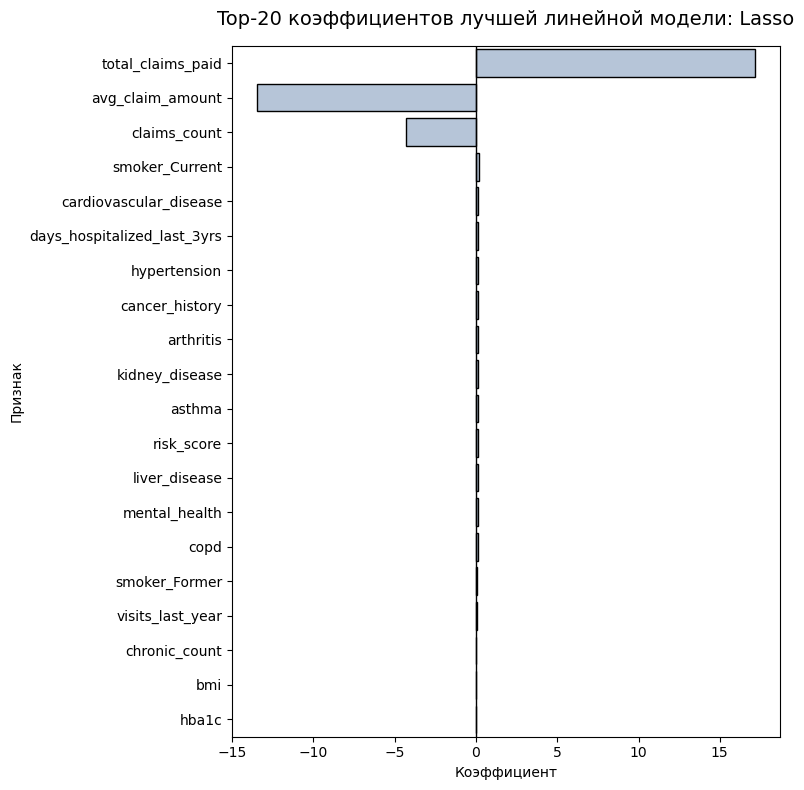

In [89]:
# Визуализация наиболее важных transformed-признаков

top_n = 20
plot_coef_df = linear_coef_df.head(top_n)

plt.figure(figsize=(8, 8))

ax = sns.barplot(
    data=plot_coef_df,
    x='coefficient',
    y='feature',
    color='lightsteelblue',
    edgecolor='black'
)

ax.axvline(0, color='black', linewidth=1)
ax.set_title(
    f'Top-{top_n} коэффициентов лучшей линейной модели: {best_linear_name}',
    fontsize=14,
    pad=15
)
ax.set_xlabel('Коэффициент')
ax.set_ylabel('Признак')

plt.tight_layout()
plt.show()

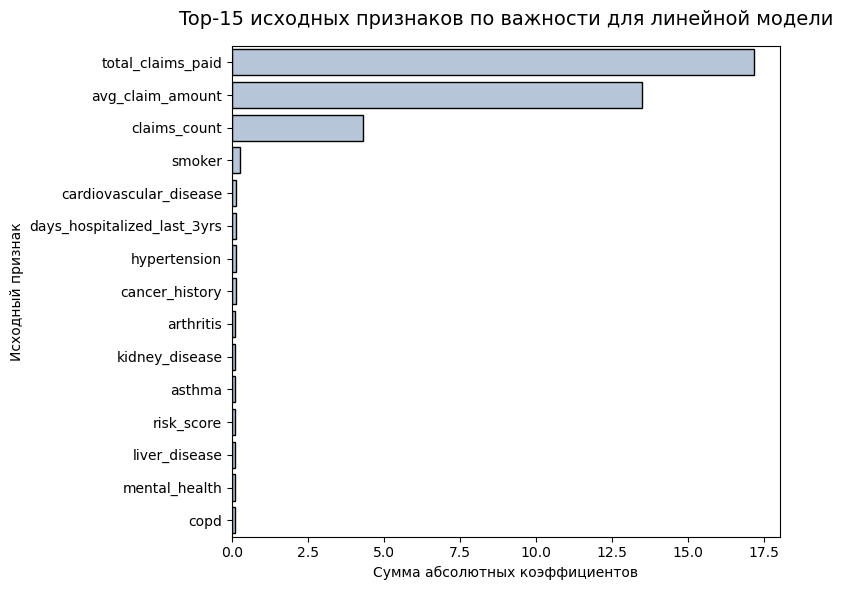

In [90]:
# Визуализация важности исходных признаков

top_n = 15
plot_original_importance = linear_original_feature_importance.head(top_n)

plt.figure(figsize=(8, 6))

ax = sns.barplot(
    data=plot_original_importance,
    x='importance',
    y='original_feature',
    color='lightsteelblue',
    edgecolor='black'
)

ax.set_title(
    f'Top-{top_n} исходных признаков по важности для линейной модели',
    fontsize=14,
    pad=15
)
ax.set_xlabel('Сумма абсолютных коэффициентов')
ax.set_ylabel('Исходный признак')

plt.tight_layout()
plt.show()

In [91]:
cv_results

[{'model': 'Lasso',
  'CV_MAE_mean': 1239.062219559559,
  'CV_MAE_std': 8.165811957949208,
  'CV_RMSE_mean': 2271.678883542997,
  'CV_RMSE_std': 29.66641472584597,
  'CV_R2_mean': 0.4762160090437413,
  'CV_R2_std': 0.013239653007685714,
  'CV_MAPE_mean': 0.5062685131631103,
  'CV_MAPE_std': 0.006003978315815368},
 {'model': 'Ridge',
  'CV_MAE_mean': 1239.4005744506715,
  'CV_MAE_std': 8.165289745570506,
  'CV_RMSE_mean': 2271.0969766440558,
  'CV_RMSE_std': 29.851421243105037,
  'CV_R2_mean': 0.4764798884531246,
  'CV_R2_std': 0.013462768544796682,
  'CV_MAPE_mean': 0.506343061658455,
  'CV_MAPE_std': 0.006031629764516088},
 {'model': 'ElasticNet',
  'CV_MAE_mean': 1239.5633475633108,
  'CV_MAE_std': 8.50954099907298,
  'CV_RMSE_mean': 2277.5385566303385,
  'CV_RMSE_std': 28.77393104500384,
  'CV_R2_mean': 0.47351586613208363,
  'CV_R2_std': 0.012846262315294107,
  'CV_MAPE_mean': 0.5064632112475735,
  'CV_MAPE_std': 0.00592669999426687}]

## 2. Модели на основе деревьев

В этом блоке обучаем несколько нелинейных моделей для общего пула base models: `RandomForestRegressor`, `ExtraTreesRegressor`, `HistGradientBoostingRegressor` и `CatBoostRegressor`.

Для sklearn-моделей используем общий preprocessing pipeline: числовые признаки импутируются, бинарные остаются как 0/1, категориальные признаки кодируются через one-hot encoding.  
Для CatBoost категориальные признаки оставляем в исходном виде, чтобы модель обработала их нативно.

На этом этапе подбираем гиперпараметры и фиксируем лучшие модели. OOF-предсказания будем строить позже отдельным общим блоком для всех base models.

In [92]:
# Для расширенного датасета ordinal-признаки отдельно не выделяем.
# Все строковые признаки считаем номинальными категориальными.

nominal_categorical_features = categorical_features.copy()

# CatBoost будет обрабатывать эти признаки нативно
catboost_cat_features = categorical_features.copy()

In [93]:
# Preprocessing для RandomForest / ExtraTrees / HistGradientBoosting
# Масштабирование не используем: деревья не чувствительны к масштабу признаков

# Preprocessing для RandomForest / ExtraTrees / HistGradientBoosting
# Масштабирование не используем: деревья не чувствительны к масштабу признаков

def make_sklearn_tree_preprocessor(
    numeric_features,
    binary_features,
    nominal_categorical_features
):
    numeric_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median'))
    ])

    binary_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent'))
    ])

    categorical_drop_map = {
        'sex': 'Other',
        'region': 'Central',
        'urban_rural': 'Rural',
        'education': 'No HS',
        'marital_status': 'Single',
        'employment_status': 'Unemployed',
        'smoker': 'Never',
        'alcohol_freq': 'Missing',
        'plan_type': 'POS',
        'network_tier': 'Platinum'
    }

    categorical_drop = [
        categorical_drop_map[col]
        for col in nominal_categorical_features
    ]

    nominal_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
        ('encoder', OneHotEncoder(
            drop=categorical_drop,
            handle_unknown='ignore',
            sparse_output=False
        ))
    ])

    return ColumnTransformer(
        transformers=[
            ('num', numeric_pipeline, numeric_features),
            ('binary', binary_pipeline, binary_features),
            ('nominal', nominal_pipeline, nominal_categorical_features)
        ],
        remainder='drop',
        verbose_feature_names_out=True
    )


def make_sklearn_tree_pipeline(model):
    return Pipeline([
        ('preprocessor', make_sklearn_tree_preprocessor(
            numeric_features=numeric_features,
            binary_features=binary_features,
            nominal_categorical_features=nominal_categorical_features
        )),
        ('model', model)
    ])

In [94]:
# Helper для RandomizedSearchCV
# Для 100k строк RandomizedSearchCV практичнее, чем полный GridSearchCV

def run_random_search(
    model_name,
    pipeline,
    param_distributions,
    n_iter=20,
    random_state=RANDOM_STATE
):
    search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=param_distributions,
        n_iter=n_iter,
        scoring=scoring,
        refit='mae',
        cv=cv,
        n_jobs=-1,
        random_state=random_state,
        return_train_score=False,
        verbose=1
    )

    search.fit(X_train, y_train)

    print(f'{model_name}')
    print(f'Best CV MAE: {-search.best_score_:.4f}')
    print(f'Best params: {search.best_params_}')
    print()

    return search


# Helper для извлечения метрик лучшей модели из GridSearchCV / RandomizedSearchCV

def get_best_search_metrics(search, model_name):
    best_idx = search.best_index_

    return pd.Series({
        'model': model_name,
        'CV_MAE_mean': -search.cv_results_['mean_test_mae'][best_idx],
        'CV_MAE_std': search.cv_results_['std_test_mae'][best_idx],
        'CV_RMSE_mean': -search.cv_results_['mean_test_rmse'][best_idx],
        'CV_RMSE_std': search.cv_results_['std_test_rmse'][best_idx],
        'CV_R2_mean': search.cv_results_['mean_test_r2'][best_idx],
        'CV_R2_std': search.cv_results_['std_test_r2'][best_idx],
        'CV_MAPE_mean': -search.cv_results_['mean_test_mape'][best_idx],
        'CV_MAPE_std': search.cv_results_['std_test_mape'][best_idx]
    })

### RandomForestRegressor

In [95]:
# RandomForestRegressor

rf_pipeline = make_sklearn_tree_pipeline(
    RandomForestRegressor(
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
)

rf_param_distributions = {
    'model__n_estimators': [200, 400, 600],
    'model__max_depth': [None, 6, 8, 10, 14, 18],
    'model__min_samples_split': [5, 10, 30, 100],
    'model__min_samples_leaf': [3, 10, 30, 50],
    'model__max_features': ['sqrt', 0.5, 0.8, 1.0]
}

rf_search = run_random_search(
    model_name='RandomForestRegressor',
    pipeline=rf_pipeline,
    param_distributions=rf_param_distributions,
    n_iter=20
)

rf_cv_result = get_best_search_metrics(
    rf_search,
    model_name='RandomForestRegressor'
)

rf_cv_result

Fitting 5 folds for each of 20 candidates, totalling 100 fits
RandomForestRegressor
Best CV MAE: 965.3454
Best params: {'model__n_estimators': 600, 'model__min_samples_split': 10, 'model__min_samples_leaf': 3, 'model__max_features': 0.5, 'model__max_depth': 10}



model           RandomForestRegressor
CV_MAE_mean                965.345364
CV_MAE_std                   7.225452
CV_RMSE_mean              1716.368437
CV_RMSE_std                 46.629755
CV_R2_mean                    0.70084
CV_R2_std                    0.016078
CV_MAPE_mean                 0.522101
CV_MAPE_std                  0.009062
dtype: object

### ExtraTreesRegressor

In [96]:
# ExtraTreesRegressor.
# Эта модель похожа на RandomForest, но строит более рандомизированные деревья.
# Она может давать другой тип ошибок, что полезно для ансамбля.

extra_trees_pipeline = make_sklearn_tree_pipeline(
    ExtraTreesRegressor(
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
)

extra_trees_param_distributions = {
    'model__n_estimators': [200, 400, 600],
    'model__max_depth': [None, 6, 8, 10, 14, 18],
    'model__min_samples_split': [5, 10, 30, 100],
    'model__min_samples_leaf': [3, 10, 30, 50],
    'model__max_features': ['sqrt', 0.5, 0.8, 1.0]
}

extra_trees_search = run_random_search(
    model_name='ExtraTreesRegressor',
    pipeline=extra_trees_pipeline,
    param_distributions=extra_trees_param_distributions,
    n_iter=20
)

extra_trees_cv_result = get_best_search_metrics(
    extra_trees_search,
    model_name='ExtraTreesRegressor'
)

extra_trees_cv_result

Fitting 5 folds for each of 20 candidates, totalling 100 fits
ExtraTreesRegressor
Best CV MAE: 965.0564
Best params: {'model__n_estimators': 200, 'model__min_samples_split': 5, 'model__min_samples_leaf': 10, 'model__max_features': 1.0, 'model__max_depth': 14}



model           ExtraTreesRegressor
CV_MAE_mean              965.056396
CV_MAE_std                 7.745219
CV_RMSE_mean            1723.991281
CV_RMSE_std               48.582525
CV_R2_mean                 0.698182
CV_R2_std                  0.016405
CV_MAPE_mean               0.519337
CV_MAPE_std                0.008767
dtype: object

### HistGradientBoostingRegressor

In [97]:
# Функция для оценки pipeline на CV.
# Используется внутри Optuna objective.

def evaluate_pipeline_cv_mae(pipeline, X, y, cv, trial=None):
    fold_mae = []

    for fold_id, (train_idx, valid_idx) in enumerate(cv.split(X, y), start=1):
        X_fold_train = X.iloc[train_idx].copy()
        X_fold_valid = X.iloc[valid_idx].copy()

        y_fold_train = y.iloc[train_idx].copy()
        y_fold_valid = y.iloc[valid_idx].copy()

        fold_model = clone(pipeline)
        fold_model.fit(X_fold_train, y_fold_train)

        y_fold_pred = fold_model.predict(X_fold_valid)

        mae = mean_absolute_error(
            y_fold_valid,
            y_fold_pred
        )

        fold_mae.append(mae)

        if trial is not None:
            trial.report(np.mean(fold_mae), step=fold_id)

            if trial.should_prune():
                raise optuna.TrialPruned()

    return np.mean(fold_mae)


# HistGradientBoostingRegressor с early stopping.
# max_iter задаём большим, а фактическое число итераций контролируется early stopping.

MAX_ITER_HGB = 5000

def make_hgb_pipeline_from_params(params):
    model = HistGradientBoostingRegressor(
        **params,
        max_iter=MAX_ITER_HGB,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=50,
        tol=1.0,
        scoring='neg_mean_absolute_error',
        random_state=RANDOM_STATE
    )

    return make_sklearn_tree_pipeline(model)


def hgb_objective(trial):
    params = {
        'loss': trial.suggest_categorical(
            'loss',
            ['squared_error', 'absolute_error']
        ),
        'learning_rate': trial.suggest_float(
            'learning_rate',
            0.01,
            0.20,
            log=True
        ),
        'max_leaf_nodes': trial.suggest_int(
            'max_leaf_nodes',
            8,
            127
        ),
        'max_depth': trial.suggest_categorical(
            'max_depth',
            [None, 4, 6, 8, 10, 15]
        ),
        'min_samples_leaf': trial.suggest_int(
            'min_samples_leaf',
            10,
            200
        ),
        'l2_regularization': trial.suggest_float(
            'l2_regularization',
            1e-8,
            100.0,
            log=True
        ),
        'max_bins': trial.suggest_int(
            'max_bins',
            64,
            255
        ),
        'max_features': trial.suggest_float(
            'max_features',
            0.5,
            1.0
        )
    }

    pipeline = make_hgb_pipeline_from_params(params)

    return evaluate_pipeline_cv_mae(
        pipeline=pipeline,
        X=X_train,
        y=y_train,
        cv=cv,
        trial=trial
    )

In [98]:
# Запуск Optuna для HistGradientBoostingRegressor

N_TRIALS_HGB = 30

if OPTUNA_AVAILABLE:
    hgb_study = optuna.create_study(
        direction='minimize',
        sampler=TPESampler(seed=RANDOM_STATE),
        pruner=MedianPruner(n_startup_trials=10, n_warmup_steps=2)
    )

    hgb_study.optimize(
        hgb_objective,
        n_trials=N_TRIALS_HGB,
        show_progress_bar=True
    )

    print(f'Best CV MAE: {hgb_study.best_value:.4f}')
    print(f'Best params: {hgb_study.best_params}')

  0%|          | 0/30 [00:00<?, ?it/s]

Best CV MAE: 919.3567
Best params: {'loss': 'absolute_error', 'learning_rate': 0.015057969910976698, 'max_leaf_nodes': 37, 'max_depth': None, 'min_samples_leaf': 91, 'l2_regularization': 2.6693989147093145e-05, 'max_bins': 243, 'max_features': 0.922953846262095}


In [99]:
# Финальная CV-оценка лучшей HGB-конфигурации по всем метрикам

best_hgb_pipeline = make_hgb_pipeline_from_params(
    hgb_study.best_params
)

hgb_cv_result = cross_validate_regression_model(
    model=best_hgb_pipeline,
    X=X_train,
    y=y_train,
    model_name='HistGradientBoostingRegressor',
    cv=cv,
    scoring=scoring
)

hgb_cv_result

model           HistGradientBoostingRegressor
CV_MAE_mean                        919.356721
CV_MAE_std                            11.7835
CV_RMSE_mean                      1841.163814
CV_RMSE_std                           45.8717
CV_R2_mean                           0.655911
CV_R2_std                            0.014079
CV_MAPE_mean                         0.395936
CV_MAPE_std                          0.005406
dtype: object

In [100]:
# Обучаем лучшую HGB-модель на всём train
# Test set пока не используем

best_hgb_pipeline.fit(X_train, y_train)

hgb_model = best_hgb_pipeline.named_steps['model']

print(f'Max iterations: {hgb_model.max_iter}')
print(f'Actual iterations: {hgb_model.n_iter_}')
print(f'Early stopping used: {hgb_model.do_early_stopping_}')

Max iterations: 5000
Actual iterations: 335
Early stopping used: True


### CatBoost

In [101]:
# Preprocessing для CatBoost.
# Числовые и бинарные признаки оставляем как есть.
# Категориальные признаки передаём в CatBoost как строки.

class CatBoostPreprocessor(BaseEstimator, TransformerMixin):
    def __init__(
        self,
        numeric_features,
        binary_features,
        catboost_cat_features
    ):
        self.numeric_features = numeric_features
        self.binary_features = binary_features
        self.catboost_cat_features = catboost_cat_features

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        X_out = pd.DataFrame(index=X.index)

        # Числовые признаки
        # NaN не заполняем: CatBoost умеет работать с ними нативно
        X_out[self.numeric_features] = X[self.numeric_features]

        # Бинарные признаки оставляем как 0/1
        X_out[self.binary_features] = X[self.binary_features]

        # Категориальные признаки оставляем строковыми
        # Пропуски превращаем в отдельную категорию Missing
        for col in self.catboost_cat_features:
            X_out[col] = (
                X[col]
                .astype('object')
                .where(X[col].notna(), 'Missing')
                .astype(str)
            )

        return X_out[
            self.numeric_features
            + self.binary_features
            + self.catboost_cat_features
        ]


def make_catboost_preprocessor():
    return CatBoostPreprocessor(
        numeric_features=numeric_features,
        binary_features=binary_features,
        catboost_cat_features=catboost_cat_features
    )


def make_catboost_model(
    params,
    iterations=3000,
    early_stopping_rounds=None
):
    model_params = {
        'iterations': iterations,
        'loss_function': 'RMSE',
        'eval_metric': 'MAE',
        'random_seed': RANDOM_STATE,
        'verbose': False,
        'allow_writing_files': False,
        'thread_count': -1,
        'cat_features': catboost_cat_features
    }

    if early_stopping_rounds is not None:
        model_params['early_stopping_rounds'] = early_stopping_rounds

    model_params.update(params)

    return CatBoostRegressor(**model_params)


def evaluate_catboost_params_cv(
    params,
    X,
    y,
    cv,
    max_iterations=5000,
    early_stopping_rounds=50,
    trial=None
):
    fold_metrics = []
    fold_best_iterations = []

    for fold_id, (train_idx, valid_idx) in enumerate(cv.split(X, y), start=1):
        X_fold_train = X.iloc[train_idx].copy()
        X_fold_valid = X.iloc[valid_idx].copy()

        y_fold_train = y.iloc[train_idx].copy()
        y_fold_valid = y.iloc[valid_idx].copy()

        # Preprocessing обучается только на train-части текущего фолда
        fold_preprocessor = make_catboost_preprocessor()

        X_fold_train_prepared = fold_preprocessor.fit_transform(X_fold_train)
        X_fold_valid_prepared = fold_preprocessor.transform(X_fold_valid)

        model = make_catboost_model(
            params=params,
            iterations=max_iterations,
            early_stopping_rounds=early_stopping_rounds
        )

        model.fit(
            X_fold_train_prepared,
            y_fold_train,
            eval_set=(X_fold_valid_prepared, y_fold_valid),
            use_best_model=True
        )

        y_fold_pred = model.predict(X_fold_valid_prepared)

        metrics = calculate_regression_metrics(
            y_fold_valid,
            y_fold_pred
        )

        fold_metrics.append(metrics)
        fold_best_iterations.append(model.tree_count_)

        if trial is not None:
            current_mae = np.mean([m['MAE'] for m in fold_metrics])
            trial.report(current_mae, step=fold_id)

            if trial.should_prune():
                raise optuna.TrialPruned()

    return {
        'CV_MAE_mean': np.mean([m['MAE'] for m in fold_metrics]),
        'CV_MAE_std': np.std([m['MAE'] for m in fold_metrics]),
        'CV_RMSE_mean': np.mean([m['RMSE'] for m in fold_metrics]),
        'CV_RMSE_std': np.std([m['RMSE'] for m in fold_metrics]),
        'CV_R2_mean': np.mean([m['R2'] for m in fold_metrics]),
        'CV_R2_std': np.std([m['R2'] for m in fold_metrics]),
        'CV_MAPE_mean': np.mean([m['MAPE'] for m in fold_metrics]),
        'CV_MAPE_std': np.std([m['MAPE'] for m in fold_metrics]),
        'best_iteration_mean': np.mean(fold_best_iterations),
        'best_iteration_median': int(np.median(fold_best_iterations))
    }


def catboost_objective(trial):
    params = {
        'depth': trial.suggest_int(
            'depth',
            3,
            10
        ),
        'learning_rate': trial.suggest_float(
            'learning_rate',
            0.01,
            0.20,
            log=True
        ),
        'l2_leaf_reg': trial.suggest_float(
            'l2_leaf_reg',
            1e-2,
            100.0,
            log=True
        ),
        'random_strength': trial.suggest_float(
            'random_strength',
            0.0,
            10.0
        ),
        'bagging_temperature': trial.suggest_float(
            'bagging_temperature',
            0.0,
            10.0
        ),
        'border_count': trial.suggest_int(
            'border_count',
            32,
            255
        )
    }

    cv_result = evaluate_catboost_params_cv(
        params=params,
        X=X_train,
        y=y_train,
        cv=cv,
        max_iterations=5000,
        early_stopping_rounds=50,
        trial=trial
    )

    return cv_result['CV_MAE_mean']

In [102]:
# Запуск Optuna для CatBoost
# При необходимости можно увеличить N_TRIALS_CATBOOST до 30-50, сейчас для производительности задано более низкое значение

N_TRIALS_CATBOOST = 20

if OPTUNA_AVAILABLE and CATBOOST_AVAILABLE:
    catboost_study = optuna.create_study(
        direction='minimize',
        sampler=TPESampler(seed=RANDOM_STATE),
        pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=2)
    )

    catboost_study.optimize(
        catboost_objective,
        n_trials=N_TRIALS_CATBOOST,
        show_progress_bar=True
    )

    print(f'Best CV MAE: {catboost_study.best_value:.4f}')
    print(f'Best params: {catboost_study.best_params}')

  0%|          | 0/20 [00:00<?, ?it/s]

Best CV MAE: 966.9745
Best params: {'depth': 10, 'learning_rate': 0.042768740756745124, 'l2_leaf_reg': 0.2729712604024386, 'random_strength': 0.03768694471146075, 'bagging_temperature': 6.455897756509286, 'border_count': 188}


In [103]:
# Финальная CV-оценка CatBoost с лучшими параметрами

best_catboost_cv_metrics = evaluate_catboost_params_cv(
    params=catboost_study.best_params,
    X=X_train,
    y=y_train,
    cv=cv,
    max_iterations=5000,
    early_stopping_rounds=50
)

catboost_cv_result = pd.Series({
    'model': 'CatBoostRegressor',
    'CV_MAE_mean': best_catboost_cv_metrics['CV_MAE_mean'],
    'CV_MAE_std': best_catboost_cv_metrics['CV_MAE_std'],
    'CV_RMSE_mean': best_catboost_cv_metrics['CV_RMSE_mean'],
    'CV_RMSE_std': best_catboost_cv_metrics['CV_RMSE_std'],
    'CV_R2_mean': best_catboost_cv_metrics['CV_R2_mean'],
    'CV_R2_std': best_catboost_cv_metrics['CV_R2_std'],
    'CV_MAPE_mean': best_catboost_cv_metrics['CV_MAPE_mean'],
    'CV_MAPE_std': best_catboost_cv_metrics['CV_MAPE_std']
})

catboost_cv_result

model           CatBoostRegressor
CV_MAE_mean            966.974532
CV_MAE_std               7.497885
CV_RMSE_mean          1737.315161
CV_RMSE_std             49.306084
CV_R2_mean                0.69349
CV_R2_std                0.016846
CV_MAPE_mean             0.522805
CV_MAPE_std              0.008998
dtype: object

In [104]:
# Финально обучаем CatBoost на всём train
# Количество итераций берём как медиану best_iteration по CV

best_catboost_iterations = (best_catboost_cv_metrics['best_iteration_median'])

best_catboost_pipeline = Pipeline([
    ('catboost_preprocessing', make_catboost_preprocessor()),
    ('model', make_catboost_model(
        params=catboost_study.best_params,
        iterations=best_catboost_iterations,
        early_stopping_rounds=None
    ))
])

best_catboost_pipeline.fit(X_train, y_train)

print(f'CatBoost final iterations: {best_catboost_iterations}')

CatBoost final iterations: 228


### SHAP для CatBoost

In [105]:
# SHAP importance для CatBoost
# Используем нативный метод CatBoost get_feature_importance(type='ShapValues')

def get_catboost_shap_importance(
    fitted_catboost_pipeline,
    X,
    sample_size=1000
):
    sample_size = min(sample_size, len(X))

    X_sample = X.sample(
        n=sample_size,
        random_state=RANDOM_STATE
    )

    preprocessor = fitted_catboost_pipeline.named_steps['catboost_preprocessing']
    model = fitted_catboost_pipeline.named_steps['model']

    X_sample_prepared = preprocessor.transform(X_sample)

    pool = Pool(
        X_sample_prepared,
        cat_features=catboost_cat_features
    )

    shap_values = model.get_feature_importance(
        pool,
        type='ShapValues'
    )

    # Последняя колонка — base value, её не учитываем в важности признаков
    shap_feature_values = shap_values[:, :-1]

    shap_importance = pd.DataFrame({
        'feature': X_sample_prepared.columns,
        'importance': np.abs(shap_feature_values).mean(axis=0)
    })

    shap_importance = (
        shap_importance
        .sort_values('importance', ascending=False)
        .reset_index(drop=True)
    )

    return shap_importance, shap_feature_values, X_sample_prepared

In [106]:
if CATBOOST_AVAILABLE:
    catboost_shap_importance, catboost_shap_values, catboost_shap_X = (
        get_catboost_shap_importance(
            fitted_catboost_pipeline=best_catboost_pipeline,
            X=X_train,
            sample_size=10000
        )
    )

C:\Users\dmitry.volobuev_inde\AppData\Local\Temp\ipykernel_21344\338177884.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


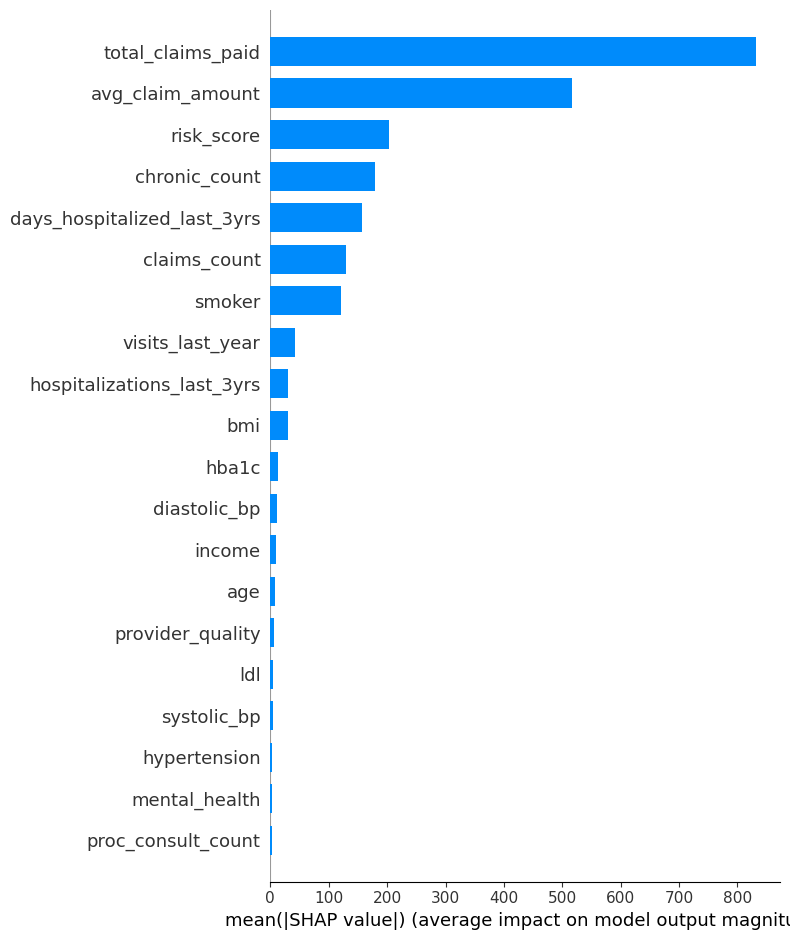

In [107]:
if SHAP_AVAILABLE and CATBOOST_AVAILABLE:
    shap.summary_plot(
        catboost_shap_values,
        catboost_shap_X,
        plot_type='bar',
        max_display=20
    )

### Результаты моделей на основе деревьев

In [108]:
# Собираем CV-результаты деревянных моделей

tree_cv_results = pd.DataFrame([
    rf_cv_result,
    extra_trees_cv_result,
    hgb_cv_result,
    catboost_cv_result
])

tree_cv_results = tree_cv_results.sort_values(
    by='CV_MAE_mean',
    ascending=True
).reset_index(drop=True)


# Сохраняем fitted-модели.
# Они обучены только на train и будут использоваться позже для OOF/test логики

tree_fitted_models = {
    'RandomForestRegressor': rf_search.best_estimator_,
    'ExtraTreesRegressor': extra_trees_search.best_estimator_,
    'HistGradientBoostingRegressor': best_hgb_pipeline,
    'CatBoostRegressor': best_catboost_pipeline
}

In [109]:
# Добавляем результаты в общую таблицу CV-результатов

tree_model_names = set(tree_cv_results['model'])

cv_results = [
    row for row in cv_results
    if row.get('model') not in tree_model_names
]

cv_results.extend(tree_cv_results.to_dict('records'))

all_cv_results = (
    pd.DataFrame(cv_results)
    .sort_values('CV_MAE_mean')
    .reset_index(drop=True)
)

all_cv_results.round(4)

,model,CV_MAE_mean,CV_MAE_std,CV_RMSE_mean,CV_RMSE_std,CV_R2_mean,CV_R2_std,CV_MAPE_mean,CV_MAPE_std
0,HistGradientBoostingRegressor,919.3567,11.7835,1841.1638,45.8717,0.6559,0.0141,0.3959,0.0054
1,ExtraTreesRegressor,965.0564,7.7452,1723.9913,48.5825,0.6982,0.0164,0.5193,0.0088
2,RandomForestRegressor,965.3454,7.2255,1716.3684,46.6298,0.7008,0.0161,0.5221,0.0091
3,CatBoostRegressor,966.9745,7.4979,1737.3152,49.3061,0.6935,0.0168,0.5228,0.0090
4,Lasso,1239.0622,8.1658,2271.6789,29.6664,0.4762,0.0132,0.5063,0.0060
5,Ridge,1239.4006,8.1653,2271.0970,29.8514,0.4765,0.0135,0.5063,0.0060
6,ElasticNet,1239.5633,8.5095,2277.5386,28.7739,0.4735,0.0128,0.5065,0.0059


На этом этапе зафиксированы основные нелинейные base models.  
Следующий шаг - собрать финальный набор базовых моделей и получить out-of-fold predictions, которые будут использоваться для расчёта весов ансамблей и обучения stacking-модели.

## Out-of-fold predictions и ансамбли

На этом шаге строим честные out-of-fold предсказания базовых моделей на train.  
Каждый объект получает прогноз от модели, которая не видела его при обучении.

OOF-предсказания используются для:

- оценки качества базовых моделей;
- расчёта весов ансамблей;
- построения pseudo-BMA;
- обучения stacking meta-model.

In [110]:
# Финальный набор базовых моделей для ансамблей
# Используем одну лучшую линейную модель + основные нелинейные модели

base_models = {
    f'BestLinear_{best_linear_name}': best_linear_model,
    'RandomForestRegressor': tree_fitted_models['RandomForestRegressor'],
    'ExtraTreesRegressor': tree_fitted_models['ExtraTreesRegressor'],
    'HistGradientBoostingRegressor': tree_fitted_models['HistGradientBoostingRegressor'],
    'CatBoostRegressor': tree_fitted_models['CatBoostRegressor']
}

list(base_models.keys())

['BestLinear_Lasso',
 'RandomForestRegressor',
 'ExtraTreesRegressor',
 'HistGradientBoostingRegressor',
 'CatBoostRegressor']

In [111]:
# Получаем OOF-предсказания на train и прогнозы на test
# Test-прогнозы пока только сохраняем, метрики на test будем считать в финальном блоке

def get_oof_and_test_predictions(
    models,
    X_train,
    y_train,
    X_test,
    cv
):
    oof_predictions = pd.DataFrame(index=X_train.index)
    test_predictions = pd.DataFrame(index=X_test.index)
    fitted_models = {}

    for model_name, model in models.items():
        print(f'Processing model: {model_name}')

        oof_pred = np.zeros(len(X_train))

        for fold_id, (train_idx, valid_idx) in enumerate(cv.split(X_train, y_train), start=1):
            X_fold_train = X_train.iloc[train_idx].copy()
            X_fold_valid = X_train.iloc[valid_idx].copy()

            y_fold_train = y_train.iloc[train_idx].copy()

            fold_model = clone(model)
            fold_model.fit(X_fold_train, y_fold_train)

            oof_pred[valid_idx] = fold_model.predict(X_fold_valid)

        # После OOF обучаем модель на всём train для будущего test-прогноза
        final_model = clone(model)
        final_model.fit(X_train, y_train)

        test_pred = final_model.predict(X_test)

        oof_predictions[model_name] = oof_pred
        test_predictions[model_name] = test_pred
        fitted_models[model_name] = final_model

    return oof_predictions, test_predictions, fitted_models

In [112]:
oof_predictions, base_test_predictions, final_fitted_models = get_oof_and_test_predictions(
    models=base_models,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    cv=cv
)

oof_predictions.head()

Processing model: BestLinear_Lasso
Processing model: RandomForestRegressor
Processing model: ExtraTreesRegressor
Processing model: HistGradientBoostingRegressor
Processing model: CatBoostRegressor


,BestLinear_Lasso,RandomForestRegressor,ExtraTreesRegressor,HistGradientBoostingRegressor,CatBoostRegressor
0,1842.660590,898.850555,927.841674,882.613486,1029.013775
1,4004.626357,9593.644321,9560.574601,8903.110556,9283.817135
2,1594.684536,1818.923114,1851.663482,1525.987267,1905.341285
3,5177.972578,5090.158726,5027.010926,4839.586562,5176.580202
4,2613.780535,4434.065496,4555.810371,3339.186184,4742.508296


In [113]:
# Оцениваем базовые модели по OOF-предсказаниям

oof_base_results = []

for model_name in oof_predictions.columns:
    metrics = calculate_regression_metrics(
        y_true=y_train,
        y_pred=oof_predictions[model_name]
    )

    metrics['model'] = model_name

    oof_base_results.append(metrics)

oof_base_results = (
    pd.DataFrame(oof_base_results)
    [['model', 'MAE', 'RMSE', 'R2', 'MAPE']]
    .sort_values('MAE')
    .reset_index(drop=True)
)

oof_base_results.round(4)

,model,MAE,RMSE,R2,MAPE
0,HistGradientBoostingRegressor,919.3567,1841.7352,0.6559,0.3959
1,ExtraTreesRegressor,965.0564,1724.6757,0.6982,0.5193
2,RandomForestRegressor,965.3454,1717.0017,0.7009,0.5221
3,CatBoostRegressor,967.0241,1737.7188,0.6936,0.5220
4,BestLinear_Lasso,1239.0622,2271.8726,0.4764,0.5063


In [114]:
# Лучшая одиночная модель выбирается только по OOF-качеству

best_single_model_name = oof_base_results.loc[0, 'model']

print(f'Лучшая одиночная модель по OOF MAE: {best_single_model_name}')

Лучшая одиночная модель по OOF MAE: HistGradientBoostingRegressor


## Ансамбль 1 - Simple Average

In [115]:
# Простое среднее прогнозов всех базовых моделей

simple_average_oof_pred = oof_predictions.mean(axis=1)
simple_average_test_pred = base_test_predictions.mean(axis=1)

## Ансамбль 2 - Inverse-Error Weighted Ensemble

In [116]:
# Веса моделей обратно пропорциональны OOF-ошибке
# Чем меньше MAE модели на OOF, тем больший вес она получает

def get_inverse_error_weights(
    oof_predictions,
    y_true,
    metric='mae',
    power=1.0,
    eps=1e-8
):
    errors = {}

    for model_name in oof_predictions.columns:
        y_pred = oof_predictions[model_name]

        if metric == 'mae':
            error = mean_absolute_error(y_true, y_pred)
        elif metric == 'rmse':
            error = root_mean_squared_error(y_true, y_pred)
        else:
            raise ValueError("metric должен быть 'mae' или 'rmse'")

        errors[model_name] = error

    errors = pd.Series(errors)

    raw_weights = 1 / np.power(errors + eps, power)
    weights = raw_weights / raw_weights.sum()

    return weights.sort_values(ascending=False)

In [117]:
inverse_mae_weights = get_inverse_error_weights(
    oof_predictions=oof_predictions,
    y_true=y_train,
    metric='mae',
    power=1.0
)

inverse_mae_weights.round(4)

HistGradientBoostingRegressor    0.2175
ExtraTreesRegressor              0.2072
RandomForestRegressor            0.2071
CatBoostRegressor                0.2068
BestLinear_Lasso                 0.1614
dtype: float64

In [118]:
inverse_weighted_oof_pred = oof_predictions.dot(inverse_mae_weights)
inverse_weighted_test_pred = base_test_predictions.dot(inverse_mae_weights)

## Ансамбль 3 - Pseudo-BMA

In [119]:
# Pseudo-BMA weights
# Используем байесовски-мотивированную идею:
# prior weights одинаковые, затем они корректируются через качество OOF-прогнозов
#
# Strict-версия использует "полный" log-likelihood и может "схлопнуться" в одну модель
# Tempered-версия мягче и обычно лучше подходит для практического ансамбля

def get_pseudo_bma_weights(
    oof_predictions,
    y_true,
    temperature=1.0,
    eps=1e-8
):
    y_true = np.asarray(y_true)
    model_names = oof_predictions.columns.tolist()

    n = len(y_true)
    k = len(model_names)

    log_scores = []

    for model_name in model_names:
        y_pred = np.asarray(oof_predictions[model_name])

        mse = np.mean((y_true - y_pred) ** 2)

        # Gaussian-inspired log-likelihood up to a constant
        log_likelihood = -0.5 * n * np.log(mse + eps)

        # Uniform prior: P(M_i) = 1 / K
        log_prior = -np.log(k)

        log_scores.append(log_prior + log_likelihood / temperature)

    log_scores = np.array(log_scores)

    # Stable softmax
    exp_scores = np.exp(log_scores - log_scores.max())
    weights = exp_scores / exp_scores.sum()

    return pd.Series(weights, index=model_names).sort_values(ascending=False)

In [120]:
# Strict pseudo-BMA: может дать почти весь вес одной модели

strict_pseudo_bma_weights = get_pseudo_bma_weights(
    oof_predictions=oof_predictions,
    y_true=y_train,
    temperature=1.0
)

strict_pseudo_bma_weights.round(4)

RandomForestRegressor            1.0
ExtraTreesRegressor              0.0
BestLinear_Lasso                 0.0
HistGradientBoostingRegressor    0.0
CatBoostRegressor                0.0
dtype: float64

In [121]:
# Tempered pseudo-BMA: более мягкая версия
# temperature=len(y_train) переводит сумму log-likelihood ближе к среднему log-score

tempered_pseudo_bma_weights = get_pseudo_bma_weights(
    oof_predictions=oof_predictions,
    y_true=y_train,
    temperature=len(y_train)
)

tempered_pseudo_bma_weights.round(4)

RandomForestRegressor            0.2141
ExtraTreesRegressor              0.2131
CatBoostRegressor                0.2115
HistGradientBoostingRegressor    0.1996
BestLinear_Lasso                 0.1618
dtype: float64

In [122]:
strict_pseudo_bma_oof_pred = oof_predictions.dot(strict_pseudo_bma_weights)
strict_pseudo_bma_test_pred = base_test_predictions.dot(strict_pseudo_bma_weights)

tempered_pseudo_bma_oof_pred = oof_predictions.dot(tempered_pseudo_bma_weights)
tempered_pseudo_bma_test_pred = base_test_predictions.dot(tempered_pseudo_bma_weights)

## Ансамбль 4 - Stacking

Для stacking используем RidgeCV как простую и устойчивую meta-model.
OOF-качество stacking оцениваем через дополнительную CV уже на таблице OOF-прогнозов, чтобы не получить слишком оптимистичную оценку.

In [123]:
# Meta-model для stacking

stacking_meta_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RidgeCV(alphas=np.logspace(-3, 4, 20)))
])

In [124]:
# Честная OOF-оценка stacking meta-model

stacking_oof_pred = cross_val_predict(
    estimator=stacking_meta_model,
    X=oof_predictions,
    y=y_train,
    cv=cv,
    n_jobs=-1
)

# Финально обучаем meta-model на всех OOF-предсказаниях train
# и применяем к test-предсказаниям базовых моделей.

stacking_meta_model.fit(oof_predictions, y_train)
stacking_test_pred = stacking_meta_model.predict(base_test_predictions)

In [125]:
# Коэффициенты stacking meta-model

stacking_weights = pd.Series(
    stacking_meta_model.named_steps['model'].coef_,
    index=oof_predictions.columns
).sort_values(ascending=False)

stacking_weights.round(4)

RandomForestRegressor            1834.3832
CatBoostRegressor                 562.3998
ExtraTreesRegressor               478.0708
BestLinear_Lasso                  114.0609
HistGradientBoostingRegressor    -341.0242
dtype: float64

## OOF-оценка ансамблей

In [126]:
# OOF-предсказания ансамблей
# BestSingleModel сюда не добавляем, так как это не отдельная модель,
# а ссылка на лучшую базовую модель по OOF

ensemble_oof_predictions = pd.DataFrame({
    'SimpleAverageEnsemble': simple_average_oof_pred,
    'InverseMAEWeightedEnsemble': inverse_weighted_oof_pred,
    'StrictPseudoBMA': strict_pseudo_bma_oof_pred,
    'TemperedPseudoBMA': tempered_pseudo_bma_oof_pred,
    'StackingRidge': stacking_oof_pred
})

In [127]:
# OOF-метрики ансамблей

oof_ensemble_results = []

for model_name in ensemble_oof_predictions.columns:
    metrics = calculate_regression_metrics(
        y_true=y_train,
        y_pred=ensemble_oof_predictions[model_name]
    )

    metrics['model'] = model_name

    oof_ensemble_results.append(metrics)

oof_ensemble_results = (
    pd.DataFrame(oof_ensemble_results)
    [['model', 'MAE', 'RMSE', 'R2', 'MAPE']]
    .sort_values('MAE')
    .reset_index(drop=True)
)

oof_ensemble_results.round(4)

,model,MAE,RMSE,R2,MAPE
0,InverseMAEWeightedEnsemble,937.4867,1753.0901,0.6882,0.4732
1,TemperedPseudoBMA,938.4259,1751.1711,0.6889,0.4756
2,SimpleAverageEnsemble,940.7509,1761.9668,0.6850,0.4726
3,StackingRidge,964.9350,1715.5906,0.7014,0.5175
4,StrictPseudoBMA,965.3454,1717.0017,0.7009,0.5221


In [128]:
# Общая OOF-таблица: базовые модели + ансамбли

oof_all_results = pd.concat(
    [
        oof_base_results.assign(type='base_model'),
        oof_ensemble_results.assign(type='ensemble')
    ],
    ignore_index=True
)

oof_all_results = (
    oof_all_results
    .sort_values('MAE')
    .reset_index(drop=True)
)

oof_all_results.round(4)

,model,MAE,RMSE,R2,MAPE,type
0,HistGradientBoostingRegressor,919.3567,1841.7352,0.6559,0.3959,base_model
1,InverseMAEWeightedEnsemble,937.4867,1753.0901,0.6882,0.4732,ensemble
2,TemperedPseudoBMA,938.4259,1751.1711,0.6889,0.4756,ensemble
3,SimpleAverageEnsemble,940.7509,1761.9668,0.6850,0.4726,ensemble
4,StackingRidge,964.9350,1715.5906,0.7014,0.5175,ensemble
5,ExtraTreesRegressor,965.0564,1724.6757,0.6982,0.5193,base_model
6,RandomForestRegressor,965.3454,1717.0017,0.7009,0.5221,base_model
7,StrictPseudoBMA,965.3454,1717.0017,0.7009,0.5221,ensemble
8,CatBoostRegressor,967.0241,1737.7188,0.6936,0.5220,base_model
9,BestLinear_Lasso,1239.0622,2271.8726,0.4764,0.5063,base_model


## Test-предсказания ансамблей без оценки

In [129]:
# Test-предсказания ансамблей
# BestSingleModel не добавляем как отдельный столбец

ensemble_test_predictions = pd.DataFrame({
    'SimpleAverageEnsemble': simple_average_test_pred,
    'InverseMAEWeightedEnsemble': inverse_weighted_test_pred,
    'StrictPseudoBMA': strict_pseudo_bma_test_pred,
    'TemperedPseudoBMA': tempered_pseudo_bma_test_pred,
    'StackingRidge': stacking_test_pred
})

In [130]:
# Итоговый набор test-предсказаний для финального сравнения:
# базовые модели + ансамбли

final_test_predictions = pd.concat(
    [
        base_test_predictions,
        ensemble_test_predictions
    ],
    axis=1
)

final_test_predictions.head()

,BestLinear_Lasso,RandomForestRegressor,ExtraTreesRegressor,HistGradientBoostingRegressor,CatBoostRegressor,SimpleAverageEnsemble,InverseMAEWeightedEnsemble,StrictPseudoBMA,TemperedPseudoBMA,StackingRidge
0,2561.954354,2632.146064,2681.162368,2492.899710,2629.931903,2599.618880,2600.230718,2632.146064,2602.980087,2617.953132
1,1567.208227,2095.056098,2071.342046,1587.612402,2108.145410,1885.872836,1897.295505,2095.056098,1906.112692,2093.490415
2,2763.710884,5137.583298,5318.848102,3845.781727,5368.445960,4486.873994,4558.814873,5137.583298,4583.212923,5283.245918
3,1304.686690,1744.528760,1728.380270,1158.415497,1692.205321,1525.643308,1531.901513,1744.528760,1541.900543,1741.249328
4,1577.485450,1490.784806,1455.816478,1382.742998,1412.332862,1463.832519,1457.809754,1490.784806,1459.205368,1432.102819


- `oof_predictions` — OOF-прогнозы базовых моделей;
- `base_test_predictions` — test-прогнозы базовых моделей;
- `ensemble_oof_predictions` — OOF-прогнозы ансамблей;
- `ensemble_test_predictions` — test-прогнозы ансамблей;
- `final_test_predictions` — все test-прогнозы для финального сравнения;
- `oof_all_results` — таблица качества базовых моделей и ансамблей по OOF.

## Финальная оценка на test и статистическое сравнение

На этом этапе впервые используем отложенный test set.  
Модели и ансамбли уже были выбраны по train / OOF-логике, поэтому test используется только для независимой финальной оценки.

Основное сравнение делаем против `BestSingleModel`, то есть лучшей одиночной модели, выбранной по OOF-качеству.

In [131]:
# Финальная test-оценка всех моделей и ансамблей

test_results = []

for model_name in final_test_predictions.columns:
    metrics = calculate_regression_metrics(
        y_true=y_test,
        y_pred=final_test_predictions[model_name]
    )
    metrics['model'] = model_name
    test_results.append(metrics)

test_results = (
    pd.DataFrame(test_results)
    [['model', 'MAE', 'RMSE', 'R2', 'MAPE']]
    .sort_values('MAE')
    .reset_index(drop=True)
)

test_results.round(4)

,model,MAE,RMSE,R2,MAPE
0,HistGradientBoostingRegressor,922.4037,1869.9266,0.6311,0.3977
1,InverseMAEWeightedEnsemble,941.6838,1787.9598,0.6627,0.4765
2,TemperedPseudoBMA,942.6263,1786.1080,0.6634,0.4788
3,SimpleAverageEnsemble,944.8819,1797.7642,0.6590,0.4759
4,ExtraTreesRegressor,968.4998,1752.7014,0.6759,0.5229
5,StackingRidge,968.7618,1749.0086,0.6772,0.5219
6,RandomForestRegressor,968.8488,1748.8246,0.6773,0.5263
7,StrictPseudoBMA,968.8488,1748.8246,0.6773,0.5263
8,CatBoostRegressor,970.6720,1770.4159,0.6693,0.5245
9,BestLinear_Lasso,1247.9026,2317.0042,0.4336,0.5105


In [132]:
# Bootstrap confidence intervals для метрик на test

def bootstrap_metric_ci(
    y_true,
    y_pred,
    metric_func,
    n_bootstrap=1000,
    ci=0.95,
    random_state=RANDOM_STATE
):
    rng = np.random.default_rng(random_state)

    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    n = len(y_true)
    values = []

    for _ in range(n_bootstrap):
        sample_idx = rng.choice(n, size=n, replace=True)
        values.append(
            metric_func(y_true[sample_idx], y_pred[sample_idx])
        )

    alpha = 1 - ci

    return {
        'mean': np.mean(values),
        'ci_lower': np.quantile(values, alpha / 2),
        'ci_upper': np.quantile(values, 1 - alpha / 2)
    }

In [133]:
# Считаем 95% CI для основных метрик

metric_functions = {
    'MAE': mean_absolute_error,
    'RMSE': root_mean_squared_error,
    'R2': r2_score,
    'MAPE': mean_absolute_percentage_error
}

ci_rows = []

for model_name in final_test_predictions.columns:
    y_pred = final_test_predictions[model_name]

    for metric_name, metric_func in metric_functions.items():
        ci_result = bootstrap_metric_ci(
            y_true=y_test,
            y_pred=y_pred,
            metric_func=metric_func,
            n_bootstrap=1000
        )

        ci_rows.append({
            'model': model_name,
            'metric': metric_name,
            **ci_result
        })

test_metric_ci = pd.DataFrame(ci_rows)

test_metric_ci.head()

,model,metric,mean,ci_lower,ci_upper
0,BestLinear_Lasso,MAE,1247.299238,1221.180673,1274.677090
1,BestLinear_Lasso,RMSE,2316.323402,2205.287175,2440.543070
2,BestLinear_Lasso,R2,0.433357,0.403319,0.462531
3,BestLinear_Lasso,MAPE,0.510271,0.501179,0.519323
4,RandomForestRegressor,MAE,968.899333,948.472159,990.541588


In [134]:
# Таблица test-метрик с 95% CI

test_metric_ci_wide = (
    test_metric_ci
    .assign(
        value_with_ci=lambda d:
            d['mean'].round(4).astype(str)
            + ' ['
            + d['ci_lower'].round(4).astype(str)
            + '; '
            + d['ci_upper'].round(4).astype(str)
            + ']'
    )
    .pivot(
        index='model',
        columns='metric',
        values='value_with_ci'
    )
    .reset_index()
)

model_order = test_results['model'].tolist()

test_metric_ci_wide['model'] = pd.Categorical(
    test_metric_ci_wide['model'],
    categories=model_order,
    ordered=True
)

test_metric_ci_wide = (
    test_metric_ci_wide
    .sort_values('model')
    .reset_index(drop=True)
)

test_metric_ci_wide

metric,model,MAE,MAPE,R2,RMSE
0,HistGradientBoostingRegressor,922.3163 [898.8607; 946.0279],0.3976 [0.3886; 0.4066],0.6305 [0.5989; 0.6602],1870.2138 [1758.4014; 1995.1415]
1,InverseMAEWeightedEnsemble,941.617 [920.3699; 963.7813],0.4763 [0.4652; 0.4878],0.662 [0.6297; 0.6912],1788.7334 [1685.4449; 1910.5479]
2,TemperedPseudoBMA,942.5632 [921.3391; 964.713],0.4786 [0.4674; 0.4903],0.6627 [0.6303; 0.692],1786.8958 [1683.4046; 1908.7776]
3,SimpleAverageEnsemble,944.7929 [923.5948; 967.0521],0.4757 [0.4647; 0.4873],0.6583 [0.6261; 0.6874],1798.4914 [1695.7615; 1919.9604]
4,ExtraTreesRegressor,968.5187 [947.5694; 989.6288],0.5227 [0.5096; 0.5357],0.675 [0.6439; 0.704],1753.8019 [1653.1874; 1870.7874]
5,StackingRidge,968.8035 [948.5503; 990.2147],0.5217 [0.5085; 0.5351],0.6763 [0.6452; 0.706],1750.1748 [1655.5189; 1868.4229]
6,RandomForestRegressor,968.8993 [948.4722; 990.5416],0.5262 [0.5131; 0.5393],0.6764 [0.6445; 0.7059],1749.993 [1654.0317; 1869.7095]
7,StrictPseudoBMA,968.8993 [948.4722; 990.5416],0.5262 [0.5131; 0.5393],0.6764 [0.6445; 0.7059],1749.993 [1654.0317; 1869.7095]
8,CatBoostRegressor,970.7137 [950.1367; 992.1131],0.5243 [0.5118; 0.5372],0.6684 [0.6374; 0.6969],1771.5367 [1673.5285; 1888.6354]
9,BestLinear_Lasso,1247.2992 [1221.1807; 1274.6771],0.5103 [0.5012; 0.5193],0.4334 [0.4033; 0.4625],2316.3234 [2205.2872; 2440.5431]


In [135]:
# Paired bootstrap: сравниваем MAE каждой модели с BestSingleModel
# Если CI разницы полностью ниже 0 — модель устойчиво лучше BestSingleModel
# Если CI включает 0 — статистически значимой разницы по MAE не видно

def paired_bootstrap_mae_diff(
    y_true,
    y_pred_model,
    y_pred_reference,
    n_bootstrap=1000,
    ci=0.95,
    random_state=RANDOM_STATE
):
    rng = np.random.default_rng(random_state)

    y_true = np.asarray(y_true)
    y_pred_model = np.asarray(y_pred_model)
    y_pred_reference = np.asarray(y_pred_reference)

    n = len(y_true)
    diffs = []

    for _ in range(n_bootstrap):
        sample_idx = rng.choice(n, size=n, replace=True)

        mae_model = mean_absolute_error(
            y_true[sample_idx],
            y_pred_model[sample_idx]
        )
        mae_reference = mean_absolute_error(
            y_true[sample_idx],
            y_pred_reference[sample_idx]
        )

        diffs.append(mae_model - mae_reference)

    alpha = 1 - ci

    return {
        'MAE_diff_mean': np.mean(diffs),
        'ci_lower': np.quantile(diffs, alpha / 2),
        'ci_upper': np.quantile(diffs, 1 - alpha / 2)
    }

In [136]:
best_single_model_name

'HistGradientBoostingRegressor'

In [137]:
# Референсная модель — лучшая одиночная модель, выбранная по OOF

reference_model_name = best_single_model_name
reference_pred = final_test_predictions[reference_model_name]

print(f'Референсная одиночная модель: {reference_model_name}')
reference_pred = final_test_predictions[reference_model_name]

bootstrap_comparison_rows = []

for model_name in final_test_predictions.columns:
    if model_name == reference_model_name:
        continue

    diff_result = paired_bootstrap_mae_diff(
        y_true=y_test,
        y_pred_model=final_test_predictions[model_name],
        y_pred_reference=reference_pred,
        n_bootstrap=1000
    )

    bootstrap_comparison_rows.append({
        'model': model_name,
        'compared_with': reference_model_name,
        **diff_result
    })

bootstrap_mae_comparison = (
    pd.DataFrame(bootstrap_comparison_rows)
    .sort_values('MAE_diff_mean')
    .reset_index(drop=True)
)

bootstrap_mae_comparison.round(4)

Референсная одиночная модель: HistGradientBoostingRegressor


,model,compared_with,MAE_diff_mean,ci_lower,ci_upper
0,InverseMAEWeightedEnsemble,HistGradientBoostingRegressor,19.3007,14.0807,24.4099
1,TemperedPseudoBMA,HistGradientBoostingRegressor,20.2469,14.8601,25.5230
2,SimpleAverageEnsemble,HistGradientBoostingRegressor,22.4766,17.2107,27.7908
3,ExtraTreesRegressor,HistGradientBoostingRegressor,46.2024,38.1627,54.1123
4,StackingRidge,HistGradientBoostingRegressor,46.4871,37.8294,54.9570
5,RandomForestRegressor,HistGradientBoostingRegressor,46.5830,37.6118,55.0889
6,StrictPseudoBMA,HistGradientBoostingRegressor,46.5830,37.6118,55.0889
7,CatBoostRegressor,HistGradientBoostingRegressor,48.3974,40.5289,56.2888
8,BestLinear_Lasso,HistGradientBoostingRegressor,324.9829,312.0294,338.8215


In [138]:
# Wilcoxon signed-rank test по абсолютным ошибкам
# Это дополнительная проверка: сравниваем ошибки моделей на одних и тех же test-объектах

try:
    from scipy.stats import wilcoxon

    wilcoxon_rows = []

    reference_abs_error = np.abs(y_test - reference_pred)

    for model_name in final_test_predictions.columns:
        if model_name == reference_model_name:
            continue

        model_abs_error = np.abs(
            y_test - final_test_predictions[model_name]
        )

        stat, p_value = wilcoxon(
            model_abs_error,
            reference_abs_error,
            alternative='two-sided'
        )

        wilcoxon_rows.append({
            'model': model_name,
            'compared_with': reference_model_name,
            'wilcoxon_stat': stat,
            'p_value': p_value
        })

    wilcoxon_results = (
        pd.DataFrame(wilcoxon_rows)
        .sort_values('p_value')
        .reset_index(drop=True)
    )

    display(wilcoxon_results)

except ImportError:
    print('scipy не установлен: Wilcoxon test пропущен.')

,model,compared_with,wilcoxon_stat,p_value
0,BestLinear_Lasso,HistGradientBoostingRegressor,58647814.0,0.000000e+00
1,RandomForestRegressor,HistGradientBoostingRegressor,85741320.0,2.480229e-68
2,StrictPseudoBMA,HistGradientBoostingRegressor,85741320.0,2.480229e-68
3,CatBoostRegressor,HistGradientBoostingRegressor,85930326.0,1.395456e-66
4,ExtraTreesRegressor,HistGradientBoostingRegressor,86234009.0,8.096499e-64
5,StackingRidge,HistGradientBoostingRegressor,86593478.0,1.265234e-60
6,SimpleAverageEnsemble,HistGradientBoostingRegressor,89312519.0,3.513493e-39
7,TemperedPseudoBMA,HistGradientBoostingRegressor,89842559.0,1.471588e-35
8,InverseMAEWeightedEnsemble,HistGradientBoostingRegressor,90040607.0,2.981784e-34


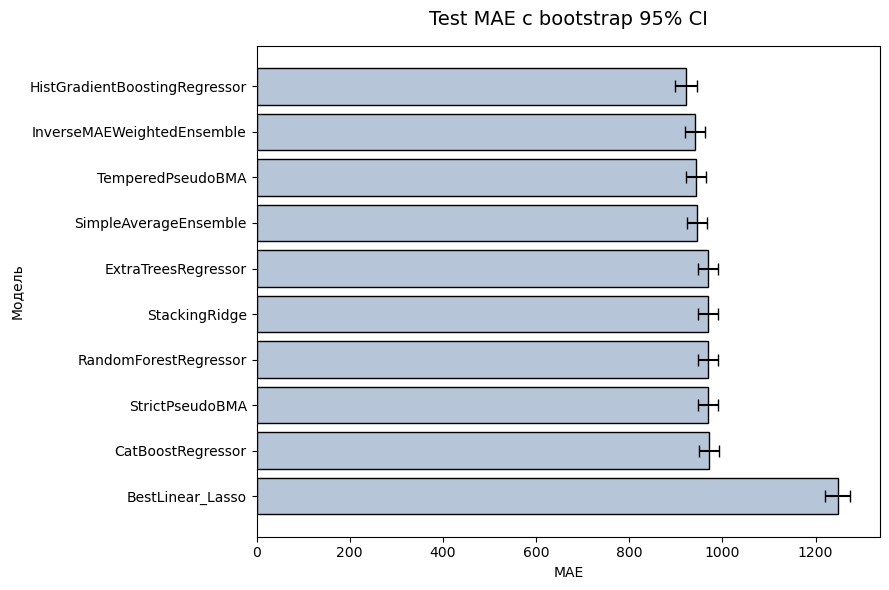

In [139]:
# Визуализация test MAE с bootstrap 95% CI

mae_ci = (
    test_metric_ci
    .query("metric == 'MAE'")
    .copy()
)

mae_ci['model'] = pd.Categorical(
    mae_ci['model'],
    categories=model_order,
    ordered=True
)

mae_ci = mae_ci.sort_values('model')

plt.figure(figsize=(9, 6))

ax = sns.barplot(
    data=mae_ci,
    x='mean',
    y='model',
    color='lightsteelblue',
    edgecolor='black'
)

xerr = np.vstack([
    mae_ci['mean'] - mae_ci['ci_lower'],
    mae_ci['ci_upper'] - mae_ci['mean']
])

ax.errorbar(
    x=mae_ci['mean'],
    y=np.arange(len(mae_ci)),
    xerr=xerr,
    fmt='none',
    color='black',
    capsize=4
)

ax.set_title('Test MAE с bootstrap 95% CI', fontsize=14, pad=15)
ax.set_xlabel('MAE')
ax.set_ylabel('Модель')

plt.tight_layout()
plt.show()

In [140]:
mae_test_results = test_metric_ci.query("metric == 'MAE'")

best_model = mae_test_results.loc[
    mae_test_results['mean'].idxmin(),
    'model'
]

best_model

'HistGradientBoostingRegressor'

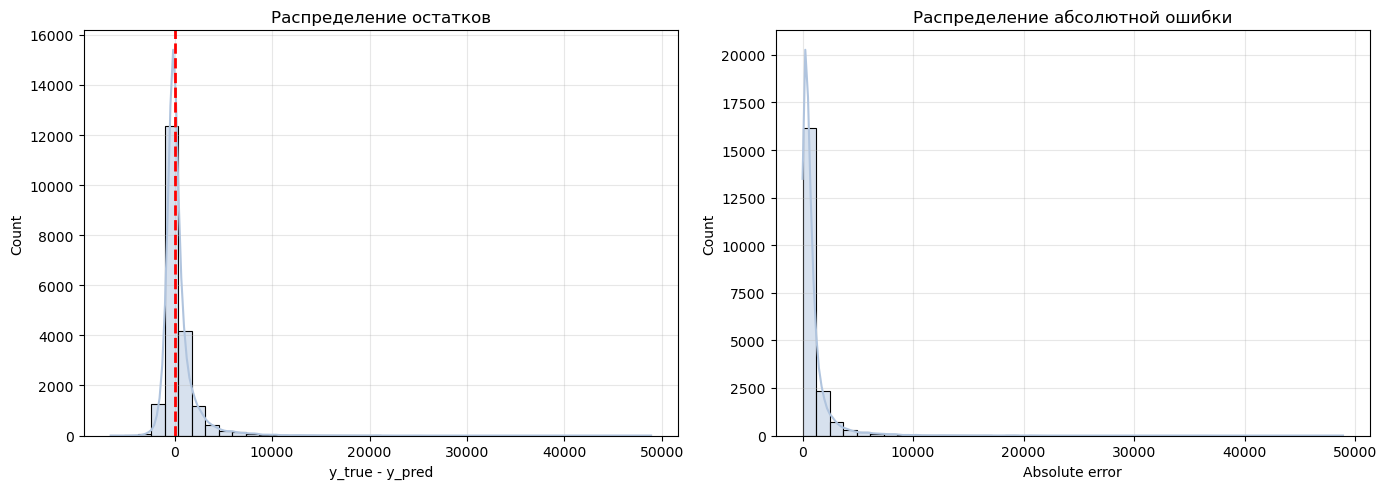

In [141]:
# Остатки для лучшей на тесте модели/ансамбля

residuals = y_test - final_test_predictions[best_model]
abs_errors = np.abs(residuals)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    residuals,
    bins=40,
    kde=True,
    color='lightsteelblue',
    edgecolor='black',
    ax=axes[0]
)
axes[0].axvline(0, color='red', linestyle='--', linewidth=2)
axes[0].set_title('Распределение остатков')
axes[0].set_xlabel('y_true - y_pred')
axes[0].grid(alpha=0.3)

sns.histplot(
    abs_errors,
    bins=40,
    kde=True,
    color='lightsteelblue',
    edgecolor='black',
    ax=axes[1]
)
axes[1].set_title('Распределение абсолютной ошибки')
axes[1].set_xlabel('Absolute error')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Итоговые выводы по финальному сравнению

- Лучшей одиночной моделью по OOF-качеству был выбран `HistGradientBoostingRegressor`, поэтому именно он использовался как референсная модель для финального статистического сравнения.

- На test set `HistGradientBoostingRegressor` также показал лучший результат по основной метрике `MAE`: около **922**. Это значит, что по средней абсолютной ошибке он оказался лучшей моделью среди всех одиночных моделей и ансамблей.

- Bootstrap-сравнение по MAE показывает, что все остальные модели и ансамбли имеют положительную разницу относительно `HistGradientBoostingRegressor`. Более того, 95% confidence intervals для разницы не включают 0. Следовательно, по MAE ухудшение относительно `HistGradientBoostingRegressor` статистически устойчиво.

- Wilcoxon test также показывает статистически значимые отличия всех моделей от `HistGradientBoostingRegressor`. В отличие от предыдущих экспериментов, линейная модель уже не близка к лучшей: `BestLinear_Lasso` заметно проигрывает по MAE.

- Ансамбли `SimpleAverageEnsemble`, `InverseMAEWeightedEnsemble` и `TemperedPseudoBMA` оказались близки к лучшей модели, но не улучшили MAE. Лучший из них — `InverseMAEWeightedEnsemble` — проигрывает примерно на **19 MAE-пунктов**.

- Но по `RMSE` и `R²` лучше выглядят некоторые другие модели:
  - `RandomForestRegressor`: RMSE около **1750**, R² около **0.676**;
  - `StackingRidge`: RMSE около **1750**, R² около **0.676**;
  - `ExtraTreesRegressor`: RMSE около **1754**, R² около **0.675**;
  - `CatBoostRegressor`: RMSE около **1772**, R² около **0.668**;
  - ансамбли `InverseMAEWeightedEnsemble`, `TemperedPseudoBMA`, `SimpleAverageEnsemble` тоже имеют RMSE/R² лучше, чем HGB.

- Это значит, что HGB лучше минимизирует среднюю абсолютную ошибку, но некоторые tree-based модели и ансамбли лучше справляются с крупными ошибками. `RMSE` сильнее штрафует большие промахи, поэтому модель с меньшим RMSE может быть полезнее, если особенно важно не ошибаться на дорогих пациентах.

- С практической точки зрения выбор зависит от бизнес-цели:
  - если главная цель — минимизировать среднюю ошибку прогноза в деньгах, то лучшая модель — `HistGradientBoostingRegressor`;
  - если важнее лучше контролировать крупные ошибки и дорогие случаи, то стоит дополнительно рассматривать `RandomForestRegressor`, `ExtraTreesRegressor` или `StackingRidge`.

- По соотношению сложность / качество особенно хорошо выглядит `RandomForestRegressor`: он заметно уступает HGB по MAE, но показывает один из лучших результатов по RMSE и R². При этом модель достаточно понятная, стабильная, не требует сложной настройки early stopping и хорошо подходит как сильный baseline.

- `ExtraTreesRegressor` также показывает хорошее качество по RMSE/R² и близок к Random Forest, но обычно менее интерпретируем в деталях и может быть чуть более “грубым” из-за большей случайности разбиений.

- `StackingRidge` даёт очень хороший RMSE/R², но усложняет pipeline: нужны OOF-предсказания, meta-model и дополнительный контроль за корректностью обучения. При этом по MAE он не выигрывает, поэтому его ценность скорее исследовательская, чем практическая.

- `CatBoostRegressor` в этом эксперименте не стал лучшим: он уступает HGB по MAE и RandomForest/ExtraTrees по RMSE/R². С учётом большей сложности настройки и обучения его не стоит выбирать как основную модель в этой версии.

- `BestLinear_Lasso` сильно уступает всем tree-based моделям, особенно по MAE и RMSE. Линейная модель остаётся полезной как простой интерпретируемый baseline, но не как финальное решение.

- `StrictPseudoBMA` фактически схлопнулся в `RandomForestRegressor`: их метрики совпадают. Это ожидаемо для strict pseudo-BMA, так как при расчёте pseudo-likelihood через MSE модель с лучшим RMSE/R² может получить почти весь вес.

- `StackingRidge` также не дал выигрыша относительно лучшей одиночной модели. Вероятно, базовые модели дают достаточно похожие прогнозы, а дополнительная мета-модель не смогла улучшить качество по MAE.

- В all-features версии качество заметно лучше, чем в более строгих постановках. Это ожидаемо, потому что в модель добавлены признаки, которые сильно связаны с `annual_medical_cost`.

- Итог: основной финальной моделью по выбранной метрике `MAE` остаётся `HistGradientBoostingRegressor`. Однако если в задаче важнее контроль крупных ошибок, то разумный альтернативный кандидат — `RandomForestRegressor`, потому что он показывает лучший баланс между качеством, устойчивостью и простотой реализации.